# Confidence Analysis

**Purpose:** Test three hypotheses about how training shapes introspective confidence:
- **H1 (Better readout):** Internal uncertainty signal exists in base; training improves the path from signal to output token.
- **H2 (Stronger representation):** Training enhances the internal uncertainty representation itself.
- **H3 (Reporting policy):** Internal representation unchanged; only late-stage mapping to output changes.

**Scope:** Confidence task only (delegate task excluded). Single token position (last prompt token before generation).

**Models:** base, instruct, finetuned (Llama-3.1-8B family).  
**Datasets:** SimpleMC, TriviaMC.

**Build order (do not skip ahead):** Section 1 → sanity check → Section 2 → ... Each section must have a short interpretation cell before moving on.

---
## Section 0: Setup and hypothesis framing

In [1]:
# --- Imports ---
from __future__ import annotations

import json
import pickle
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import RidgeCV, LogisticRegressionCV
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import spearmanr, pearsonr

# --- Globals ---
SEED = 42
np.random.seed(SEED)

N_SPLITS = 5
RIDGE_ALPHAS = np.logspace(-2, 4, 13)
LOGIT_C = np.logspace(-2, 2, 9)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# --- Paths ---
REPO_ROOT = Path('.').resolve()
OUTPUTS_DIR = REPO_ROOT / 'outputs'
CACHE_DIR = REPO_ROOT / 'outputs' / 'analysis_cache'
FIGURES_DIR = REPO_ROOT / 'outputs' / 'analysis_figures'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Repo root: {REPO_ROOT}')
print(f'Outputs:   {OUTPUTS_DIR}')
print(f'Cache:     {CACHE_DIR}')
print(f'Figures:   {FIGURES_DIR}')

Repo root: /Users/daylight/dev/code/entropy_probes_v3
Outputs:   /Users/daylight/dev/code/entropy_probes_v3/outputs
Cache:     /Users/daylight/dev/code/entropy_probes_v3/outputs/analysis_cache
Figures:   /Users/daylight/dev/code/entropy_probes_v3/outputs/analysis_figures


In [2]:
# --- Run configuration ---
# Map each model label to its output folder. Scale + bin style are
# auto-detected from each run's paired_data.json at load time, so you
# can switch between 1-10 and S-Z runs just by swapping the folder
# — no need to touch a 'scale' field.

MODELS = {
    # 1-10 numeric runs (anchors only):
    'base':      {'folder': '8b_base_26_04_1-10_scale_balanced_fewshot_examples',       'model_short': 'Llama-3.1-8B'},
    'instruct':  {'folder': '8b_instruct_26_04_scale_1-10_no_explicit_percentage_bins', 'model_short': 'Llama-3.1-8B-Instruct'},
    'finetuned': {'folder': '8b_finetuned_26_04_scale_1-10_no_explicit_percentage_bins','model_short': 'Llama-3.1-8B-Instruct_adapter-ect_20251222_215412_v0uei7y1_2000'},
    # S-Z letter runs (percentage bins):
    
    # 'base':      {'folder': '8b_base_26_04_1-10_scale_balanced_fewshot_examples',                    'model_short': 'Llama-3.1-8B'},
    # 'instruct':  {'folder': '8b_instruct_26_04',  'model_short': 'Llama-3.1-8B-Instruct'},
    # 'finetuned': {'folder': '8b_finetuned_26_04', 'model_short': 'Llama-3.1-8B-Instruct_adapter-ect_20251222_215412_v0uei7y1_2000'},
}

DATASETS = ['SimpleMC', 'TriviaMC']
META_TASK = 'confidence'  # delegate excluded from this notebook

# Column-name translation from Opus's brief to our data:
#   top2_margin_logit    -> 'logit_gap'     (z(top) - z(second))
#   entropy_over_options -> 'entropy'       (entropy of option distribution)
#   max_option_prob      -> 'top_prob'

# Probe targets (Sections 2+):
# Set SKIP_IS_CORRECT = True to drop the slow logistic classifier (~60% speedup).
# is_correct adds mechanistic info but isn't central to H1/H2/H3.
SKIP_IS_CORRECT = False

TARGETS = {
    'margin_logit':      {'col': 'logit_gap',                 'kind': 'regression'},   # primary
    'margin_prob':       {'col': 'margin',                    'kind': 'regression'},
    'entropy':           {'col': 'entropy',                   'kind': 'regression'},
    'stated_confidence': {'col': 'stated_confidence_numeric', 'kind': 'regression'},
}
if not SKIP_IS_CORRECT:
    TARGETS['is_correct'] = {'col': 'is_correct', 'kind': 'classification'}

# Prompt metadata is populated per-model by load_run() from paired_data's
# meta_options + meta_prompt (see loader cell). Used for plot footers.

def _scale_footer_text():
    parts = []
    for m in MODELS:
        scale = MODELS[m].get('prompt_scale', '?')
        bins  = MODELS[m].get('prompt_bin_style', '?')
        parts.append(f"{m}: {scale} scale, {bins}")
    return 'Prompts — ' + ' | '.join(parts)

def save_fig(path, fig=None):
    """plt.savefig + stamped scale/bin footer for every figure."""
    fig = fig if fig is not None else plt.gcf()
    fig.text(0.5, -0.08, _scale_footer_text(),
             ha='center', fontsize=6.5, style='italic', color='0.35')
    plt.savefig(path, bbox_inches='tight')


In [3]:
# --- Data loading utilities ---

@dataclass
class RunData:
    """Container for one (model, dataset) run."""
    model: str                       # e.g. 'base'
    dataset: str                     # e.g. 'SimpleMC'
    df: pd.DataFrame                 # per-example metadata (one row per question)
    direct_acts: np.ndarray          # (n_examples, n_layers, d_model), float16, last-prompt token
    meta_acts: np.ndarray            # same shape, confidence-prompt last token
    config: dict                     # run config

    @property
    def n_examples(self) -> int:
        return self.direct_acts.shape[0]

    @property
    def n_layers(self) -> int:
        return self.direct_acts.shape[1]

    @property
    def d_model(self) -> int:
        return self.direct_acts.shape[2]


def _resolve_paths(model: str, dataset: str, meta_task: str = META_TASK) -> Dict[str, Path]:
    """Locate the paired_data.json + activations for (model, dataset).

    Instead of constructing an exact filename from a configured scale,
    we glob the folder for `{model_short}_{dataset}_introspection{meta_suffix}*_paired_data.json`.
    This makes the loader agnostic to the scale suffix (letters vs
    `_scale-numeric`), so switching run folders doesn't need a config flip.
    """
    cfg = MODELS[model]
    folder = OUTPUTS_DIR / cfg['folder']
    ms = cfg['model_short']
    meta_suffix = '' if meta_task == 'confidence' else f'_{meta_task}'
    pattern = f'{ms}_{dataset}_introspection{meta_suffix}*_paired_data.json'
    matches = sorted(folder.glob(pattern)) if folder.exists() else []
    # Exclude matches for *other* meta_tasks that happen to also start with our prefix
    # (e.g. when meta_task='confidence', exclude '_delegate_' / '_other_' files).
    if meta_task == 'confidence':
        matches = [m for m in matches
                   if '_delegate_' not in m.name and '_other_' not in m.name]
    if not matches:
        return {'folder': folder, 'pattern': pattern,
                'paired_data': None, 'direct_acts': None, 'meta_acts': None, 'stem': None}
    # Prefer the shortest name (unsuffixed over variants)
    best = min(matches, key=lambda p: len(p.name))
    stem = best.name[:-len('_paired_data.json')]
    return {
        'folder': folder,
        'pattern': pattern,
        'paired_data': best,
        'direct_acts': folder / f'{stem}_direct_activations.npz',
        'meta_acts':   folder / f'{stem}_meta_activations.npz',
        'stem': stem,
    }


def _stack_layer_npz(npz_path: Path) -> np.ndarray:
    """Load an activations npz with layer_0..layer_N keys into (n, n_layers, d)."""
    with np.load(npz_path) as f:
        layer_keys = sorted(
            [k for k in f.keys() if k.startswith('layer_')],
            key=lambda k: int(k.split('_')[1]),
        )
        stacked = np.stack([f[k] for k in layer_keys], axis=1)  # (n, n_layers, d)
    return stacked.astype(np.float16)


def _infer_prompt_meta_from_paired(paired: dict) -> Tuple[str, str]:
    """Detect (scale_label, bin_style_label) from a loaded paired_data dict.

    scale_label: '1-10' or 'S-Z' or '<first>-<last>' based on meta_options.
    bin_style_label: 'percentage bins' if the meta_prompt contains '%', else 'anchors only'.
    """
    ex = paired.get('example_prompts') or []
    mo, mp = [], ''
    if ex and isinstance(ex[0], dict):
        mo = ex[0].get('meta_options') or []
        mp = ex[0].get('meta_prompt') or ''
    scale = 'unknown'
    if mo and all(isinstance(o, str) and o for o in mo):
        scale = f'{mo[0]}-{mo[-1]}'
    bin_style = 'percentage bins' if '%' in mp else 'anchors only'
    return scale, bin_style


def _build_dataframe(paired: dict, model: str, dataset: str) -> pd.DataFrame:
    """Flatten paired_data.json per-example fields into a DataFrame.

    One row per question. Columns include all direct_metrics, stated_confidence_numeric,
    is_correct, direct_responses, meta_responses, and question metadata.
    """
    n = len(paired['direct_probs'])
    row = {
        'example_id':  [q.get('id', f'q_{i}') for i, q in enumerate(paired['questions'])],
        'model':       model,
        'dataset':     dataset,
        'question':    [q.get('question', '') for q in paired['questions']],
        'correct_answer': [q.get('correct_answer', '') for q in paired['questions']],
        'direct_response': paired.get('direct_responses', [None] * n),
        'meta_response':   paired.get('meta_responses',   [None] * n),
        'is_correct':      paired.get('is_correct', [False] * n),
        'stated_confidence_numeric': paired.get('stated_confidence_numeric', [np.nan] * n),
        'meta_entropy':    paired.get('meta_entropies', [np.nan] * n),
    }
    for k, v in paired.get('direct_metrics', {}).items():
        row[k] = v
    if 'other_confidence' in paired:
        row['other_confidence_signal'] = paired['other_confidence'].get('signals', [np.nan] * n)
    return pd.DataFrame(row).reset_index(drop=True)


def load_run(model: str, dataset: str, meta_task: str = META_TASK) -> RunData:
    """Load one (model, dataset) run. Activations stacked to float16 array."""
    paths = _resolve_paths(model, dataset, meta_task)
    if paths.get('paired_data') is None or not paths['paired_data'].exists():
        folder = paths['folder']
        available = sorted(p.name for p in folder.glob('*_paired_data.json')) if folder.exists() else []
        raise FileNotFoundError(
            f"No paired_data matching pattern {paths['pattern']!r} in {folder}. "
            f"Available *_paired_data.json: {available or '(none)'}"
        )
    with open(paths['paired_data']) as f:
        paired = json.load(f)
    direct_acts = _stack_layer_npz(paths['direct_acts'])
    meta_acts   = _stack_layer_npz(paths['meta_acts'])
    df = _build_dataframe(paired, model, dataset)
    # Auto-populate MODELS[model] with prompt scale/bin style detected from the run.
    # (First loaded dataset wins; all datasets for a model should share the prompt.)
    scale, bin_style = _infer_prompt_meta_from_paired(paired)
    MODELS[model].setdefault('prompt_scale', scale)
    MODELS[model].setdefault('prompt_bin_style', bin_style)
    assert len(df) == direct_acts.shape[0] == meta_acts.shape[0], (
        f'Row count mismatch: df={len(df)} direct={direct_acts.shape[0]} meta={meta_acts.shape[0]}'
    )
    return RunData(
        model=model, dataset=dataset, df=df,
        direct_acts=direct_acts, meta_acts=meta_acts,
        config=paired.get('config', {}),
    )


def load_all_available(meta_task: str = META_TASK) -> Dict[Tuple[str, str], RunData]:
    """Load every (model, dataset) combination that exists on disk; skip missing.

    Clears prompt metadata up-front so re-running after swapping MODELS
    folders picks up the new scale/bins.
    """
    for m in MODELS:
        MODELS[m].pop('prompt_scale', None)
        MODELS[m].pop('prompt_bin_style', None)
    runs: Dict[Tuple[str, str], RunData] = {}
    for model in MODELS:
        for dataset in DATASETS:
            try:
                r = load_run(model, dataset, meta_task)
                runs[(model, dataset)] = r
                print(f'  loaded {model}/{dataset}: n={r.n_examples}, layers={r.n_layers}, d={r.d_model}')
            except FileNotFoundError as e:
                print(f'  skipped {model}/{dataset}: {e}')
    # Report the detected prompt metadata so the user sees what will appear in footers
    detected = {m: (MODELS[m].get('prompt_scale', '?'), MODELS[m].get('prompt_bin_style', '?')) for m in MODELS}
    print('  prompt metadata detected:', detected)
    return runs


In [4]:
# --- Load all available runs ---
RUNS = load_all_available()
print(f'\nTotal runs loaded: {len(RUNS)}')
print(f'Keys: {list(RUNS.keys())}')

  loaded base/SimpleMC: n=500, layers=32, d=4096
  loaded base/TriviaMC: n=800, layers=32, d=4096
  loaded instruct/SimpleMC: n=500, layers=32, d=4096
  loaded instruct/TriviaMC: n=800, layers=32, d=4096
  loaded finetuned/SimpleMC: n=500, layers=32, d=4096
  loaded finetuned/TriviaMC: n=800, layers=32, d=4096
  prompt metadata detected: {'base': ('1-10', 'anchors only'), 'instruct': ('1-10', 'anchors only'), 'finetuned': ('1-10', 'anchors only')}

Total runs loaded: 6
Keys: [('base', 'SimpleMC'), ('base', 'TriviaMC'), ('instruct', 'SimpleMC'), ('instruct', 'TriviaMC'), ('finetuned', 'SimpleMC'), ('finetuned', 'TriviaMC')]


In [5]:
# --- Unified per-example DataFrame across all runs ---

def build_unified_df(runs: Dict[Tuple[str, str], RunData]) -> pd.DataFrame:
    return pd.concat([r.df for r in runs.values()], ignore_index=True)

UNIFIED_DF = build_unified_df(RUNS) if RUNS else pd.DataFrame()
print(f'Unified df shape: {UNIFIED_DF.shape}')
if len(UNIFIED_DF):
    print(UNIFIED_DF[['model', 'dataset']].value_counts())

Unified df shape: (3900, 18)
model      dataset 
base       TriviaMC    800
finetuned  TriviaMC    800
instruct   TriviaMC    800
base       SimpleMC    500
finetuned  SimpleMC    500
instruct   SimpleMC    500
Name: count, dtype: int64


### Hypothesis scorecard

Predicted signatures for each hypothesis. Section 10 fills in observed values and scores matches.

| Signature | H1 (Better readout) | H2 (Stronger repr) | H3 (Reporting policy) |
|---|---|---|---|
| **within_R2_margin** (base → finetuned) | ≈ unchanged (high in base already) | **increases** at matched layers | ≈ unchanged |
| **cross_R2 margin→stated** (base → finetuned) | **increases sharply** | increases | increases (late layers) |
| **ablation effect on stated confidence** | **large** | large | **large (late-layer only)** |
| **ablation effect on margin/entropy** | **small** | medium | **small** |
| **layer_localization of gains** | mid-to-late | **all layers** | **last 2–4 layers** |


In [6]:
# --- Hypothesis scorecard DataFrame (filled in Section 10) ---
SCORECARD = pd.DataFrame(
    {
        'within_R2_margin':           ['unchanged (high in base)', 'increases',  'unchanged'],
        'cross_R2_margin_to_stated':  ['increases sharply',         'increases',  'increases (late)'],
        'ablation_effect_stated':     ['large',                     'large',      'large (late only)'],
        'ablation_effect_margin':     ['small',                     'medium',     'small'],
        'layer_localization':         ['mid-to-late',               'all layers', 'last 2–4 layers'],
    },
    index=['H1', 'H2', 'H3'],
)
print('\n=== Predicted signatures ===')
SCORECARD


=== Predicted signatures ===


,within_R2_margin,cross_R2_margin_to_stated,ablation_effect_stated,ablation_effect_margin,layer_localization
H1,unchanged (high in base),increases sharply,large,small,mid-to-late
H2,increases,increases,large,medium,all layers
H3,unchanged,increases (late),large (late only),small,last 2–4 layers


---
## Section 1: Dataset characterization and sanity checks

**Purpose:** Verify the data before any mechanistic analysis.
- Entropy distributions (expect right-skew)
- Correlation among `entropy`, `logit_gap`, `top_prob` (expect ≥ 0.9 within-model)
- Reliability diagram (stated confidence vs. actual accuracy, one line per model)
- Sample counts per (model, dataset, entropy quartile) — flag cells with n < 200
- Define `entropy_balanced_subset(df)` helper

**Hypothesis relevance:** Prerequisite only. No hypothesis claims tested here. Pathological correlations or reliability curves are red flags for everything downstream.

**Flags to watch for:**
- Base model reliability should be roughly flat (base can't self-report calibration well) — monotone curve means few-shot prompt is leaking signal.
- If `entropy`–`logit_gap`–`top_prob` correlations are much below 0.9, metrics are diverging meaningfully.

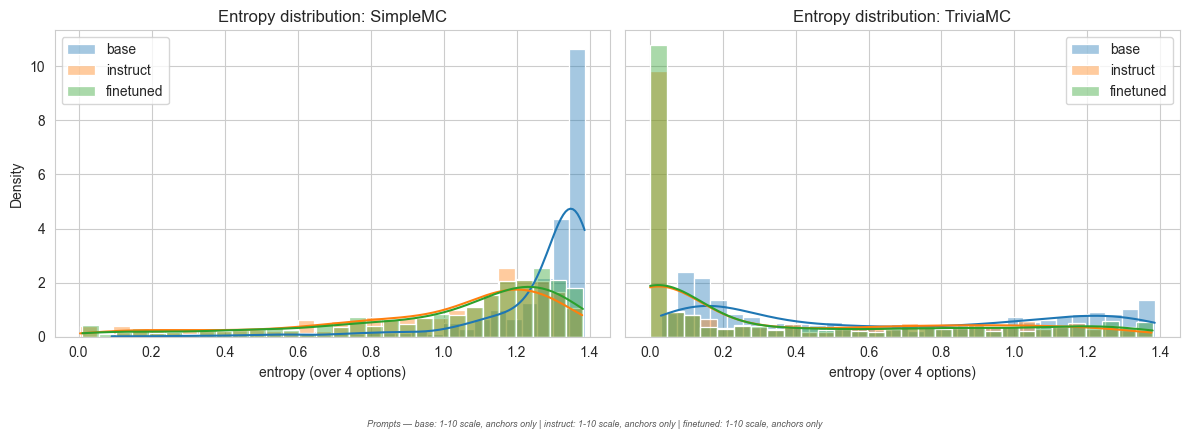


=== Entropy statistics ===
    model  dataset   n  mean  median   std   p10   p90  max_entropy_possible
     base SimpleMC 500 1.263   1.338 0.188 1.065 1.377                 1.386
     base TriviaMC 800 0.646   0.565 0.470 0.101 1.307                 1.386
 instruct SimpleMC 500 0.976   1.109 0.342 0.412 1.296                 1.386
 instruct TriviaMC 800 0.359   0.097 0.438 0.000 1.088                 1.386
finetuned SimpleMC 500 1.014   1.142 0.339 0.487 1.326                 1.386
finetuned TriviaMC 800 0.350   0.049 0.458 0.001 1.154                 1.386


In [7]:
# --- Section 1.1: Entropy distribution per (model, dataset) ---
fig, axes = plt.subplots(1, len(DATASETS), figsize=(6 * len(DATASETS), 4), sharey=True)
axes = np.atleast_1d(axes)
for ax, dataset in zip(axes, DATASETS):
    for model in MODELS:
        if (model, dataset) not in RUNS:
            continue
        sns.histplot(
            RUNS[(model, dataset)].df['entropy'], ax=ax,
            label=model, alpha=0.4, stat='density', bins=30, kde=True,
        )
    ax.set_title(f'Entropy distribution: {dataset}')
    ax.set_xlabel('entropy (over 4 options)')
    ax.legend()
plt.tight_layout()
save_fig(FIGURES_DIR / 's1_entropy_distributions.pdf')
plt.show()

# Text summary of entropy statistics per (model, dataset)
print('\n=== Entropy statistics ===')
stats_rows = []
for (model, dataset), run in RUNS.items():
    e = run.df['entropy'].values
    stats_rows.append({
        'model': model, 'dataset': dataset, 'n': len(e),
        'mean': e.mean(), 'median': np.median(e), 'std': e.std(),
        'p10': np.percentile(e, 10), 'p90': np.percentile(e, 90),
        'max_entropy_possible': np.log(4),
    })
stats_df = pd.DataFrame(stats_rows).round(3)
print(stats_df.to_string(index=False))


In [8]:
# --- Section 1.2: Correlation matrix of uncertainty proxies ---
UNCERTAINTY_COLS = ['entropy', 'logit_gap', 'top_prob', 'margin']
corr_flags = []
for (model, dataset), run in RUNS.items():
    corr = run.df[UNCERTAINTY_COLS].corr().round(3)
    offdiag = corr.values[~np.eye(len(UNCERTAINTY_COLS), dtype=bool)]
    min_abs = np.abs(offdiag).min()
    flag = ' ⚠️ (some |r| < 0.85)' if min_abs < 0.85 else ''
    print(f'\n=== {model}/{dataset}  (min |off-diag r| = {min_abs:.3f}){flag} ===')
    print(corr)
    corr_flags.append((model, dataset, min_abs, flag != ''))


=== base/SimpleMC  (min |off-diag r| = 0.921) ===
           entropy  logit_gap  top_prob  margin
entropy      1.000     -0.921    -0.954   -0.93
logit_gap   -0.921      1.000     0.944    0.98
top_prob    -0.954      0.944     1.000    0.98
margin      -0.930      0.980     0.980    1.00

=== base/TriviaMC  (min |off-diag r| = 0.928) ===
           entropy  logit_gap  top_prob  margin
entropy      1.000     -0.958    -0.979  -0.971
logit_gap   -0.958      1.000     0.928   0.945
top_prob    -0.979      0.928     1.000   0.992
margin      -0.971      0.945     0.992   1.000

=== instruct/SimpleMC  (min |off-diag r| = 0.904) ===
           entropy  logit_gap  top_prob  margin
entropy      1.000     -0.911    -0.959  -0.925
logit_gap   -0.911      1.000     0.904   0.930
top_prob    -0.959      0.904     1.000   0.983
margin      -0.925      0.930     0.983   1.000

=== instruct/TriviaMC  (min |off-diag r| = 0.780) ⚠️ (some |r| < 0.85) ===
           entropy  logit_gap  top_prob  margin

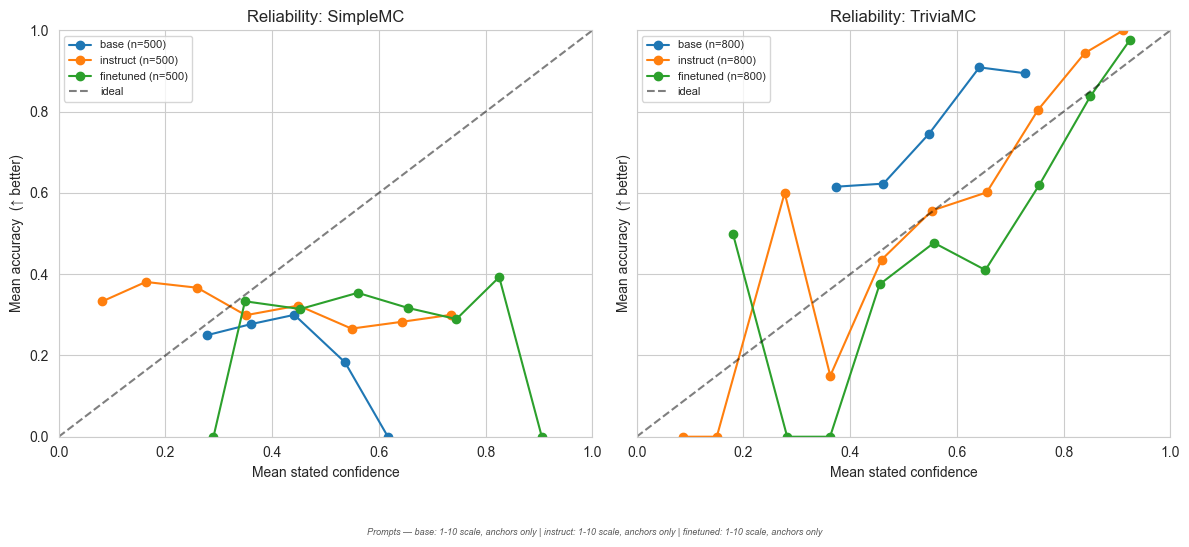


=== Mean accuracy per (model, dataset) ===
  base       / SimpleMC  : 26.8%
  base       / TriviaMC  : 74.6%
  instruct   / SimpleMC  : 30.8%
  instruct   / TriviaMC  : 72.5%
  finetuned  / SimpleMC  : 31.8%
  finetuned  / TriviaMC  : 74.9%


In [9]:
# --- Section 1.3: Reliability diagram ---
fig, axes = plt.subplots(1, len(DATASETS), figsize=(6 * len(DATASETS), 5), sharey=True)
axes = np.atleast_1d(axes)
for ax, dataset in zip(axes, DATASETS):
    for model in MODELS:
        if (model, dataset) not in RUNS:
            continue
        df = RUNS[(model, dataset)].df.copy().dropna(subset=['stated_confidence_numeric'])
        bins = np.linspace(0, 1, 11)
        df['bin'] = pd.cut(df['stated_confidence_numeric'], bins=bins, include_lowest=True)
        rel = df.groupby('bin', observed=True).agg(
            mean_conf=('stated_confidence_numeric', 'mean'),
            mean_acc=('is_correct', 'mean'),
            n=('is_correct', 'count'),
        ).reset_index()
        ax.plot(rel['mean_conf'], rel['mean_acc'], marker='o', label=f'{model} (n={len(df)})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='ideal')
    ax.set_title(f'Reliability: {dataset}')
    ax.set_xlabel('Mean stated confidence')
    ax.set_ylabel('Mean accuracy  (↑ better)')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
plt.tight_layout()
save_fig(FIGURES_DIR / 's1_reliability.pdf')
plt.show()

# Also print raw accuracy by model
print('\n=== Mean accuracy per (model, dataset) ===')
for (model, dataset), run in RUNS.items():
    print(f'  {model:10s} / {dataset:10s}: {run.df["is_correct"].mean():.1%}')

In [10]:
# --- Section 1.4: Entropy quartile counts + underpowered flags ---
qc = {}
for (model, dataset), run in RUNS.items():
    quarts = pd.qcut(run.df['entropy'], q=4, labels=['Q1_low', 'Q2', 'Q3', 'Q4_high'])
    qc[f'{model}/{dataset}'] = quarts.value_counts().sort_index()
quartile_df = pd.DataFrame(qc).T
print('=== Entropy quartile counts ===')
print(quartile_df)

flagged = quartile_df[quartile_df.min(axis=1) < 200]
if len(flagged):
    print('\n⚠️  Cells with n < 200 in some quartile (underpowered for balanced analyses):')
    print(flagged)
else:
    print('\nAll (model, dataset) cells have ≥ 200 examples per quartile.')

=== Entropy quartile counts ===
entropy             Q1_low   Q2   Q3  Q4_high
base/SimpleMC          125  127  129      119
base/TriviaMC          201  199  200      200
instruct/SimpleMC      125  125  125      125
instruct/TriviaMC      200  200  200      200
finetuned/SimpleMC     125  125  125      125
finetuned/TriviaMC     200  200  200      200

⚠️  Cells with n < 200 in some quartile (underpowered for balanced analyses):
entropy             Q1_low   Q2   Q3  Q4_high
base/SimpleMC          125  127  129      119
base/TriviaMC          201  199  200      200
instruct/SimpleMC      125  125  125      125
finetuned/SimpleMC     125  125  125      125


In [11]:
# --- Section 1.5: entropy_balanced_subset implementation ---
def entropy_balanced_subset(df: pd.DataFrame, entropy_col: str = 'entropy', seed: int = SEED) -> pd.DataFrame:
    """Return a subset with approximately equal counts across entropy quartiles.

    Quartiles are computed within the input df. The dominant bin is subsampled
    down to the smallest bin's size, preserving index order.
    """
    quarts = pd.qcut(df[entropy_col].values, q=4, labels=False)
    counts = pd.Series(quarts).value_counts()
    target_n = int(counts.min())
    rng = np.random.default_rng(seed)
    selected = []
    for q in range(4):
        idx = np.where(quarts == q)[0]
        if len(idx) > target_n:
            idx = rng.choice(idx, size=target_n, replace=False)
        selected.extend(idx)
    selected = np.sort(selected)
    return df.iloc[selected].reset_index(drop=True)

# Sanity check
print('=== entropy_balanced_subset sanity check ===')
for (model, dataset), run in RUNS.items():
    balanced = entropy_balanced_subset(run.df)
    print(f'  {model:10s} / {dataset:10s}: {len(run.df):4d} -> {len(balanced):4d} (balanced)')

=== entropy_balanced_subset sanity check ===
  base       / SimpleMC  :  500 ->  476 (balanced)
  base       / TriviaMC  :  800 ->  796 (balanced)
  instruct   / SimpleMC  :  500 ->  500 (balanced)
  instruct   / TriviaMC  :  800 ->  800 (balanced)
  finetuned  / SimpleMC  :  500 ->  500 (balanced)
  finetuned  / TriviaMC  :  800 ->  800 (balanced)


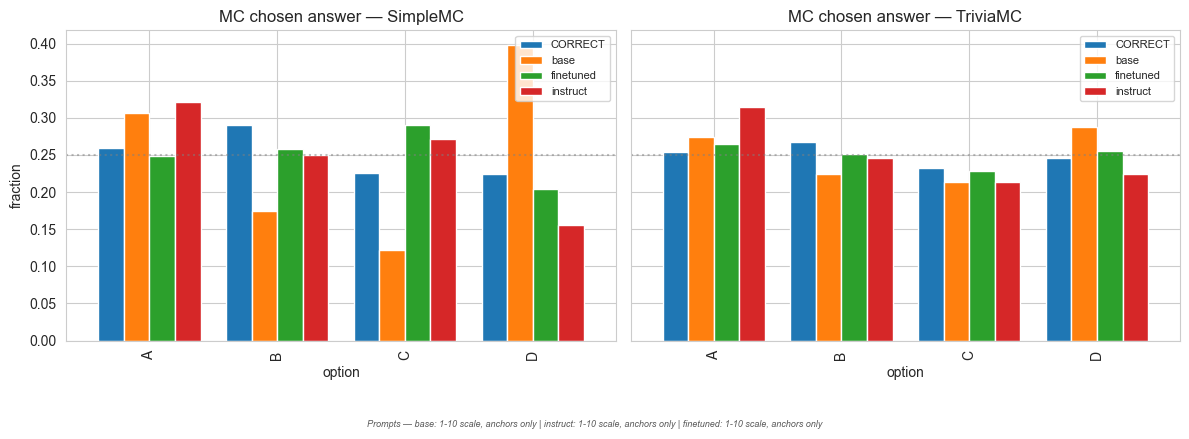


=== MC chosen answer distribution (direct_response) ===
choice-entropy max = 2.00 bits (uniform over 4 options)
  base       / SimpleMC  : A=0.31 B=0.17 C=0.12 D=0.40  dominant=D (39.8%)  choice-H=1.86  acc=26.8%
  base       / TriviaMC  : A=0.27 B=0.23 C=0.21 D=0.29  dominant=D (28.7%)  choice-H=1.99  acc=74.6%
  instruct   / SimpleMC  : A=0.32 B=0.25 C=0.27 D=0.16  dominant=A (32.2%)  choice-H=1.96  acc=30.8%
  instruct   / TriviaMC  : A=0.32 B=0.25 C=0.21 D=0.23  dominant=A (31.5%)  choice-H=1.98  acc=72.5%
  finetuned  / SimpleMC  : A=0.25 B=0.26 C=0.29 D=0.20  dominant=C (29.0%)  choice-H=1.99  acc=31.8%
  finetuned  / TriviaMC  : A=0.27 B=0.25 C=0.23 D=0.26  dominant=A (26.5%)  choice-H=2.00  acc=74.9%


In [12]:
# --- Section 1.6: Chosen MC answer distribution (A/B/C/D) ---
fig, axes = plt.subplots(1, len(DATASETS), figsize=(6 * len(DATASETS), 4), sharey=True)
axes = np.atleast_1d(axes)

for ax, dataset in zip(axes, DATASETS):
    rows = []
    first_run = next((RUNS[(m, dataset)] for m in MODELS if (m, dataset) in RUNS), None)
    if first_run is not None:
        cc = first_run.df['correct_answer'].value_counts(normalize=True).reindex(list('ABCD'), fill_value=0)
        for letter, f in cc.items():
            rows.append({'model': 'CORRECT', 'letter': letter, 'frac': f})
    for model in MODELS:
        if (model, dataset) not in RUNS: continue
        df = RUNS[(model, dataset)].df
        counts = df['direct_response'].value_counts(normalize=True).reindex(list('ABCD'), fill_value=0)
        for letter, f in counts.items():
            rows.append({'model': model, 'letter': letter, 'frac': f})
    bd = pd.DataFrame(rows).pivot(index='letter', columns='model', values='frac')
    ordered = ['CORRECT'] + [c for c in bd.columns if c != 'CORRECT']
    bd = bd[[c for c in ordered if c in bd.columns]]
    bd.plot(kind='bar', ax=ax, width=0.8)
    ax.set_title(f'MC chosen answer — {dataset}')
    ax.set_ylabel('fraction')
    ax.set_xlabel('option')
    ax.axhline(0.25, linestyle=':', color='gray', alpha=0.5)
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
save_fig(FIGURES_DIR / 's1_mc_answer_distribution.pdf')
plt.show()

# Text summary: per-letter fractions + dominant letter + entropy of choice distribution
print('\n=== MC chosen answer distribution (direct_response) ===')
print('choice-entropy max = 2.00 bits (uniform over 4 options)')
for (model, dataset), run in RUNS.items():
    counts = run.df['direct_response'].value_counts(normalize=True).reindex(list('ABCD'), fill_value=0)
    dominant = counts.idxmax()
    probs = counts.values + 1e-12
    h = float(-(probs * np.log2(probs)).sum())
    acc = run.df['is_correct'].mean()
    print(f'  {model:10s} / {dataset:10s}: '
          f'A={counts["A"]:.2f} B={counts["B"]:.2f} C={counts["C"]:.2f} D={counts["D"]:.2f}  '
          f'dominant={dominant} ({counts[dominant]:.1%})  choice-H={h:.2f}  acc={acc:.1%}')


Confidence scales in loaded runs: ['numeric']
  base/SimpleMC: numeric (10 bins)
  base/TriviaMC: numeric (10 bins)
  instruct/SimpleMC: numeric (10 bins)
  instruct/TriviaMC: numeric (10 bins)
  finetuned/SimpleMC: numeric (10 bins)
  finetuned/TriviaMC: numeric (10 bins)


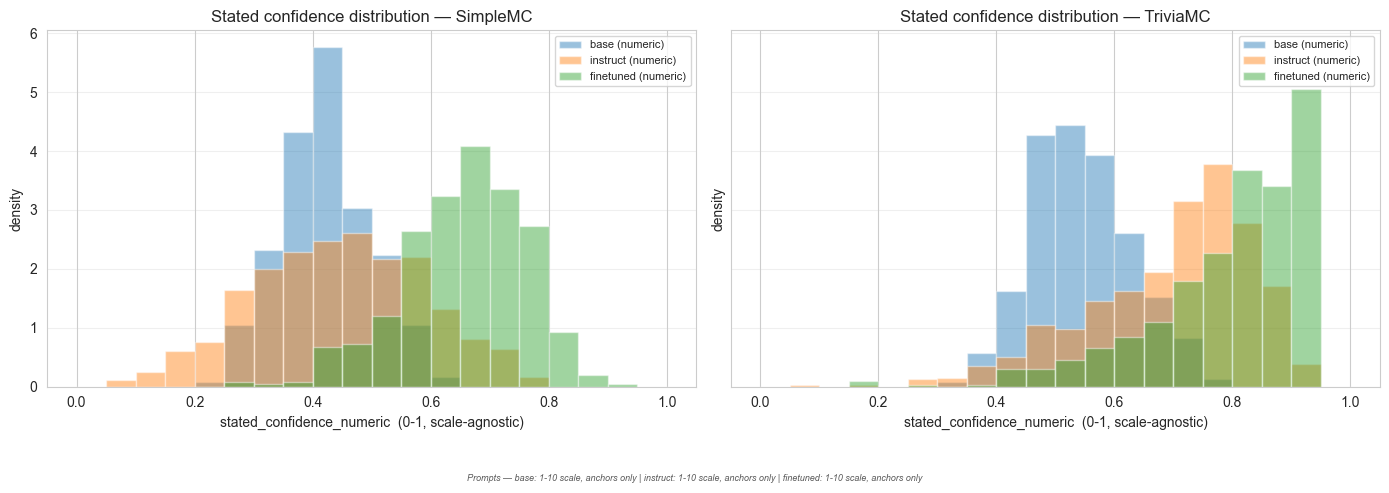


=== Stated confidence response distribution ===
  base       / SimpleMC   [numeric]: dominant=1 (61.4%), active bins (>5%)=3/10, mean stated_conf=0.422, std=0.076
  base       / TriviaMC   [numeric]: dominant=10 (78.6%), active bins (>5%)=3/10, mean stated_conf=0.545, std=0.085
  instruct   / SimpleMC   [numeric]: dominant=5 (48.4%), active bins (>5%)=4/10, mean stated_conf=0.445, std=0.145
  instruct   / TriviaMC   [numeric]: dominant=8 (69.5%), active bins (>5%)=4/10, mean stated_conf=0.697, std=0.139
  finetuned  / SimpleMC   [numeric]: dominant=8 (89.2%), active bins (>5%)=1/10, mean stated_conf=0.657, std=0.104
  finetuned  / TriviaMC   [numeric]: dominant=10 (46.0%), active bins (>5%)=3/10, mean stated_conf=0.797, std=0.131


In [13]:
# --- Section 1.7: Stated confidence distribution (per-run scale-aware) ---
# Each run may use its own confidence scale (S-Z letters or 1-10 numeric). We
# detect the scale per-run from meta_response and use each run's own bins in
# the text summary. For the plot we use stated_confidence_numeric (always in
# [0,1]) so runs on different scales overlay on a common axis.

_LETTER_ORDER = ['S','T','U','V','W','X','Y','Z']
_LETTER_LABELS = {'S':'<5%','T':'5-10%','U':'10-20%','V':'20-40%',
                  'W':'40-60%','X':'60-80%','Y':'80-90%','Z':'>90%'}
_NUMERIC_ORDER = [str(i) for i in range(1, 11)]
_NUMERIC_LABELS = {str(i): f'{(i-1)*10}-{i*10}%' for i in range(1, 11)}

def _scale_info_for(values):
    """Return (scale_label, order_list, label_dict) for this run's responses."""
    vset = {str(v) for v in values if v is not None and pd.notna(v)}
    if vset.issubset(set(_LETTER_ORDER)):
        return 'letters', _LETTER_ORDER, _LETTER_LABELS
    if vset.issubset(set(_NUMERIC_ORDER)):
        return 'numeric', _NUMERIC_ORDER, _NUMERIC_LABELS
    # Fallback: unknown/custom scale — sort values and use them as their own labels.
    order = sorted(vset)
    return 'unknown', order, {v: v for v in order}

RUN_SCALES = {key: _scale_info_for(run.df['meta_response']) for key, run in RUNS.items()}
scales_seen = sorted({si[0] for si in RUN_SCALES.values()})
print(f'Confidence scales in loaded runs: {scales_seen}')
for key, (scale, order, _) in RUN_SCALES.items():
    print(f'  {key[0]}/{key[1]}: {scale} ({len(order)} bins)')

# --- Plot: stated_confidence_numeric histograms per (model, dataset) ---
# Using the numeric [0,1] axis lets mixed-scale runs share a common plot.
fig, axes = plt.subplots(1, len(DATASETS), figsize=(7 * len(DATASETS), 4.5), sharey=True)
axes = np.atleast_1d(axes)

for ax, dataset in zip(axes, DATASETS):
    for model in MODELS:
        key = (model, dataset)
        if key not in RUNS:
            continue
        vals = RUNS[key].df['stated_confidence_numeric'].dropna().values
        if len(vals) == 0:
            continue
        ax.hist(vals, bins=np.linspace(0, 1, 21), alpha=0.45,
                label=f'{model} ({RUN_SCALES[key][0]})', density=True)
    ax.set_xlabel('stated_confidence_numeric  (0-1, scale-agnostic)')
    ax.set_ylabel('density')
    ax.set_title(f'Stated confidence distribution — {dataset}')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=8, loc='best')

plt.tight_layout()
save_fig(FIGURES_DIR / 's1_confidence_distribution.pdf')
plt.show()

# --- Text summary: per-run dominant bin + soft-signal stats in each run's own scale ---
print('\n=== Stated confidence response distribution ===')
for key, run in RUNS.items():
    model, dataset = key
    scale, order, labels = RUN_SCALES[key]
    df = run.df
    counts = df['meta_response'].value_counts(normalize=True).reindex(order, fill_value=0)
    if counts.sum() > 0:
        dominant = counts.idxmax()
        dom_frac = counts[dominant]
    else:
        dominant, dom_frac = '?', 0.0
    active_bins = int((counts > 0.05).sum())
    mean_num = df['stated_confidence_numeric'].mean()
    std_num = df['stated_confidence_numeric'].std()
    print(f'  {model:10s} / {dataset:10s} [{scale:7s}]: dominant={dominant} ({dom_frac:.1%}), '
          f'active bins (>5%)={active_bins}/{len(order)}, '
          f'mean stated_conf={mean_num:.3f}, std={std_num:.3f}')


### Section 1.8 — Accuracy & positional bias

For each `(model, dataset)` row the table reports:

| Column | Meaning | Diagnostic |
|---|---|---|
| `accuracy` | Standard MC accuracy | Primary performance metric |
| `bal_acc` | Mean of accuracy conditional on each correct letter | Positional-bias-corrected accuracy |
| `acc - bal` | Gap between the two | `> 0`: bias aligns with data (artifact helping); `< 0`: bias fights the data; `≈ 0`: unbiased |
| `when_A/B/C/D` | Per-correct-letter recall | If base/SimpleMC shows `when_D=0.6, when_A=0.1`, the model is leaning heavily on D |
| `bias_KL` | KL divergence of chosen distribution from correct distribution | `0`: matched; higher: ignoring content |

**Prediction for base/SimpleMC (based on Section 1.6):** since base picks D 40% but correct is D 22%, expect `when_D` much higher than `when_A`, and a notable `bias_KL`. That would quantify the pathology.

**Answering "are accuracy changes from positional bias or from real content-sensitivity?":** compare `acc - bal` and `bias_KL` across models. If finetuned's `accuracy` goes up but its `bias_KL` drops to near-zero while base's was high, the accuracy gain is **real content-sensitivity**. If both `accuracy` and `bias_KL` rise together, the gain is (partially) an **artifact** of positional bias coinciding with the correct-letter distribution.


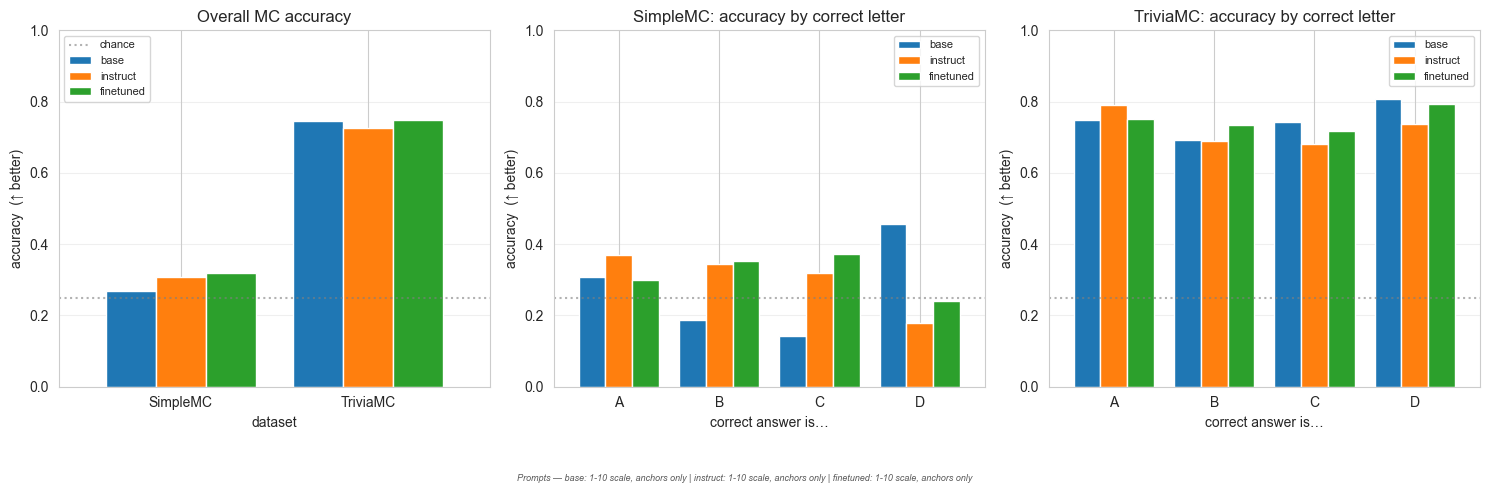


=== Accuracy + positional bias ===
  balanced_acc = mean of accuracy per correct-letter bucket (corrects for letter imbalance)
  bias_KL = KL(chosen_dist || correct_dist) — 0 = model matches true letter distribution, higher = biased toward some letters regardless of content

    model  dataset  accuracy  bal_acc  acc - bal  when_A  when_B  when_C  when_D  bias_KL
     base SimpleMC     0.268    0.273     -0.005    0.31    0.19    0.14    0.46    0.115
     base TriviaMC     0.746    0.747     -0.001    0.75    0.69    0.74    0.81    0.008
 instruct SimpleMC     0.308    0.303      0.005    0.37    0.34    0.32    0.18    0.026
 instruct TriviaMC     0.725    0.725      0.000    0.79    0.69    0.68    0.74    0.010
finetuned SimpleMC     0.318    0.316      0.002    0.30    0.35    0.37    0.24    0.011
finetuned TriviaMC     0.749    0.749      0.000    0.75    0.73    0.72    0.79    0.001

How to read the table:
  accuracy ≈ bal_acc         → no meaningful positional bias (good)
 

In [14]:
# --- Section 1.8: Accuracy + positional bias diagnostics ---
# Two plots:
#   (a) Overall accuracy per (model, dataset).
#   (b) Accuracy conditional on which letter is correct (A/B/C/D). If the model
#       has strong positional bias (e.g., always picks D), accuracy will be
#       high when correct=D and near-zero otherwise.
#
# Positional bias signature: model picking letter X regardless of question gives
#   - high accuracy when correct=X
#   - near-0 accuracy when correct is anything else
# Unbiased model: roughly equal accuracy across all correct-letter buckets.

fig, axes = plt.subplots(1, 1 + len(DATASETS), figsize=(5 * (1 + len(DATASETS)), 4.5))
axes = np.atleast_1d(axes)

# --- (a) Overall accuracy, grouped by dataset ---
overall_rows = []
for (model, dataset), run in RUNS.items():
    overall_rows.append({'model': model, 'dataset': dataset,
                         'accuracy': run.df['is_correct'].mean()})
ov_piv = pd.DataFrame(overall_rows).pivot(index='dataset', columns='model', values='accuracy')
ov_piv = ov_piv[[m for m in MODELS if m in ov_piv.columns]]
ov_piv.plot(kind='bar', ax=axes[0], width=0.8, rot=0)
axes[0].axhline(0.25, linestyle=':', color='gray', alpha=0.6, label='chance')
axes[0].set_ylabel('accuracy  (↑ better)')
axes[0].set_title('Overall MC accuracy')
axes[0].legend(fontsize=8, loc='upper left')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim(0, 1)

# --- (b) Accuracy conditional on correct letter ---
for di, dataset in enumerate(DATASETS):
    ax = axes[1 + di]
    rows = []
    for model in MODELS:
        if (model, dataset) not in RUNS: continue
        df = RUNS[(model, dataset)].df
        for letter in list('ABCD'):
            sub = df[df['correct_answer'] == letter]
            if len(sub) == 0: continue
            rows.append({'model': model, 'correct_is': letter,
                         'accuracy': sub['is_correct'].mean()})
    if not rows:
        ax.set_visible(False); continue
    pl = pd.DataFrame(rows).pivot(index='correct_is', columns='model', values='accuracy')
    pl = pl[[m for m in MODELS if m in pl.columns]]
    pl.plot(kind='bar', ax=ax, width=0.8, rot=0)
    ax.axhline(0.25, linestyle=':', color='gray', alpha=0.6)
    ax.set_title(f'{dataset}: accuracy by correct letter')
    ax.set_xlabel('correct answer is…')
    ax.set_ylabel('accuracy  (↑ better)')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=8, loc='best')

plt.tight_layout()
save_fig(FIGURES_DIR / 's1_accuracy_and_bias.pdf')
plt.show()

# --- Text summary ---
import math

def _kl(p, q):
    out = 0.0
    for pi, qi in zip(p, q):
        if pi > 1e-9:
            out += pi * math.log((pi + 1e-12) / (qi + 1e-12))
    return out

print('\n=== Accuracy + positional bias ===')
print('  balanced_acc = mean of accuracy per correct-letter bucket (corrects for letter imbalance)')
print('  bias_KL = KL(chosen_dist || correct_dist) — 0 = model matches true letter distribution, higher = biased toward some letters regardless of content')
print()
rows = []
for (model, dataset), run in RUNS.items():
    df = run.df
    acc = df['is_correct'].mean()
    per_letter = []
    for L in 'ABCD':
        sub = df[df['correct_answer'] == L]
        per_letter.append(sub['is_correct'].mean() if len(sub) else 0.0)
    bal = float(np.mean(per_letter))
    chosen_dist = df['direct_response'].value_counts(normalize=True).reindex(list('ABCD'), fill_value=0).values
    correct_dist = df['correct_answer'].value_counts(normalize=True).reindex(list('ABCD'), fill_value=0).values
    bias = _kl(chosen_dist.tolist(), correct_dist.tolist())
    # Gap between overall and balanced accuracy reveals whether bias was helping or hurting
    gap = acc - bal
    rows.append({
        'model': model, 'dataset': dataset,
        'accuracy': round(float(acc), 3),
        'bal_acc': round(bal, 3),
        'acc - bal': round(gap, 3),
        'when_A': round(float(per_letter[0]), 2),
        'when_B': round(float(per_letter[1]), 2),
        'when_C': round(float(per_letter[2]), 2),
        'when_D': round(float(per_letter[3]), 2),
        'bias_KL': round(bias, 3),
    })
print(pd.DataFrame(rows).to_string(index=False))

print('\nHow to read the table:')
print('  accuracy ≈ bal_acc         → no meaningful positional bias (good)')
print('  accuracy > bal_acc         → dataset has a biased correct-letter distribution AND the model is biased in the same direction (artifact)')
print('  per-letter row varies a lot → strong positional bias (watch the when_{A,B,C,D} columns)')
print('  high bias_KL               → model is ignoring content and leaning on position')


### Section 1.9 — Calibration and metacognition summary

One-stop view of how well each (model, dataset) combination **calibrates** its stated confidence and **metacognizes** — i.e. how well its verbal confidence tracks its own internal uncertainty signals (entropy, logit gap, top-prob) and actual correctness.

**Metrics computed per (model, dataset):**
- `accuracy`, `mean_stated_conf` — baseline descriptors.
- `ECE` — Expected Calibration Error across 10 equal-width confidence bins; 0 = perfectly calibrated, higher = worse.
- `Brier` — mean squared error between stated confidence and correctness; 0 = perfect, 0.25 = chance on a binary task.
- `overconfidence` = `mean_conf − mean_acc`; positive = overconfident, negative = underconfident.
- `ρ(stated ↔ correct)` — Spearman: does the model report *higher* confidence on items it gets right? This is **resolution / metacognitive sensitivity** and is the quantity most directly relevant to introspection. Orthogonal to calibration (a model can be resolved but miscalibrated).
- `ρ(stated ↔ −entropy)`, `ρ(stated ↔ logit_gap)`, `ρ(stated ↔ top_prob)` — how well verbal confidence tracks the model's own internal uncertainty proxies. Strong couplings are the behavioral signature of introspective readout.

**Plot:** one panel per metric; bars grouped by model with one bar per dataset. Adding a new dataset to `MODELS`/`RUNS` extends the bar groups automatically — no per-dataset editing needed.


=== Section 1.9 summary: calibration + metacognition ===
    model  dataset   n  accuracy  mean_stated_conf   ECE  Brier  overconfidence  AUROC(stated)  AUROC(-H)  ρ(stated↔correct)  ρ(stated↔-entropy)  ρ(stated↔logit_gap)  ρ(stated↔top_prob)
     base SimpleMC 500     0.268             0.422 0.154  0.230           0.154          0.465      0.477             -0.053               0.262                0.173               0.243
 instruct SimpleMC 500     0.308             0.445 0.184  0.260           0.137          0.465      0.510             -0.056               0.160                0.151               0.164
finetuned SimpleMC 500     0.318             0.657 0.339  0.343           0.339          0.488      0.520             -0.019               0.299                0.236               0.272
     base TriviaMC 800     0.746             0.545 0.201  0.217          -0.201          0.682      0.850              0.274               0.447                0.401               0.433
 instruct Tr

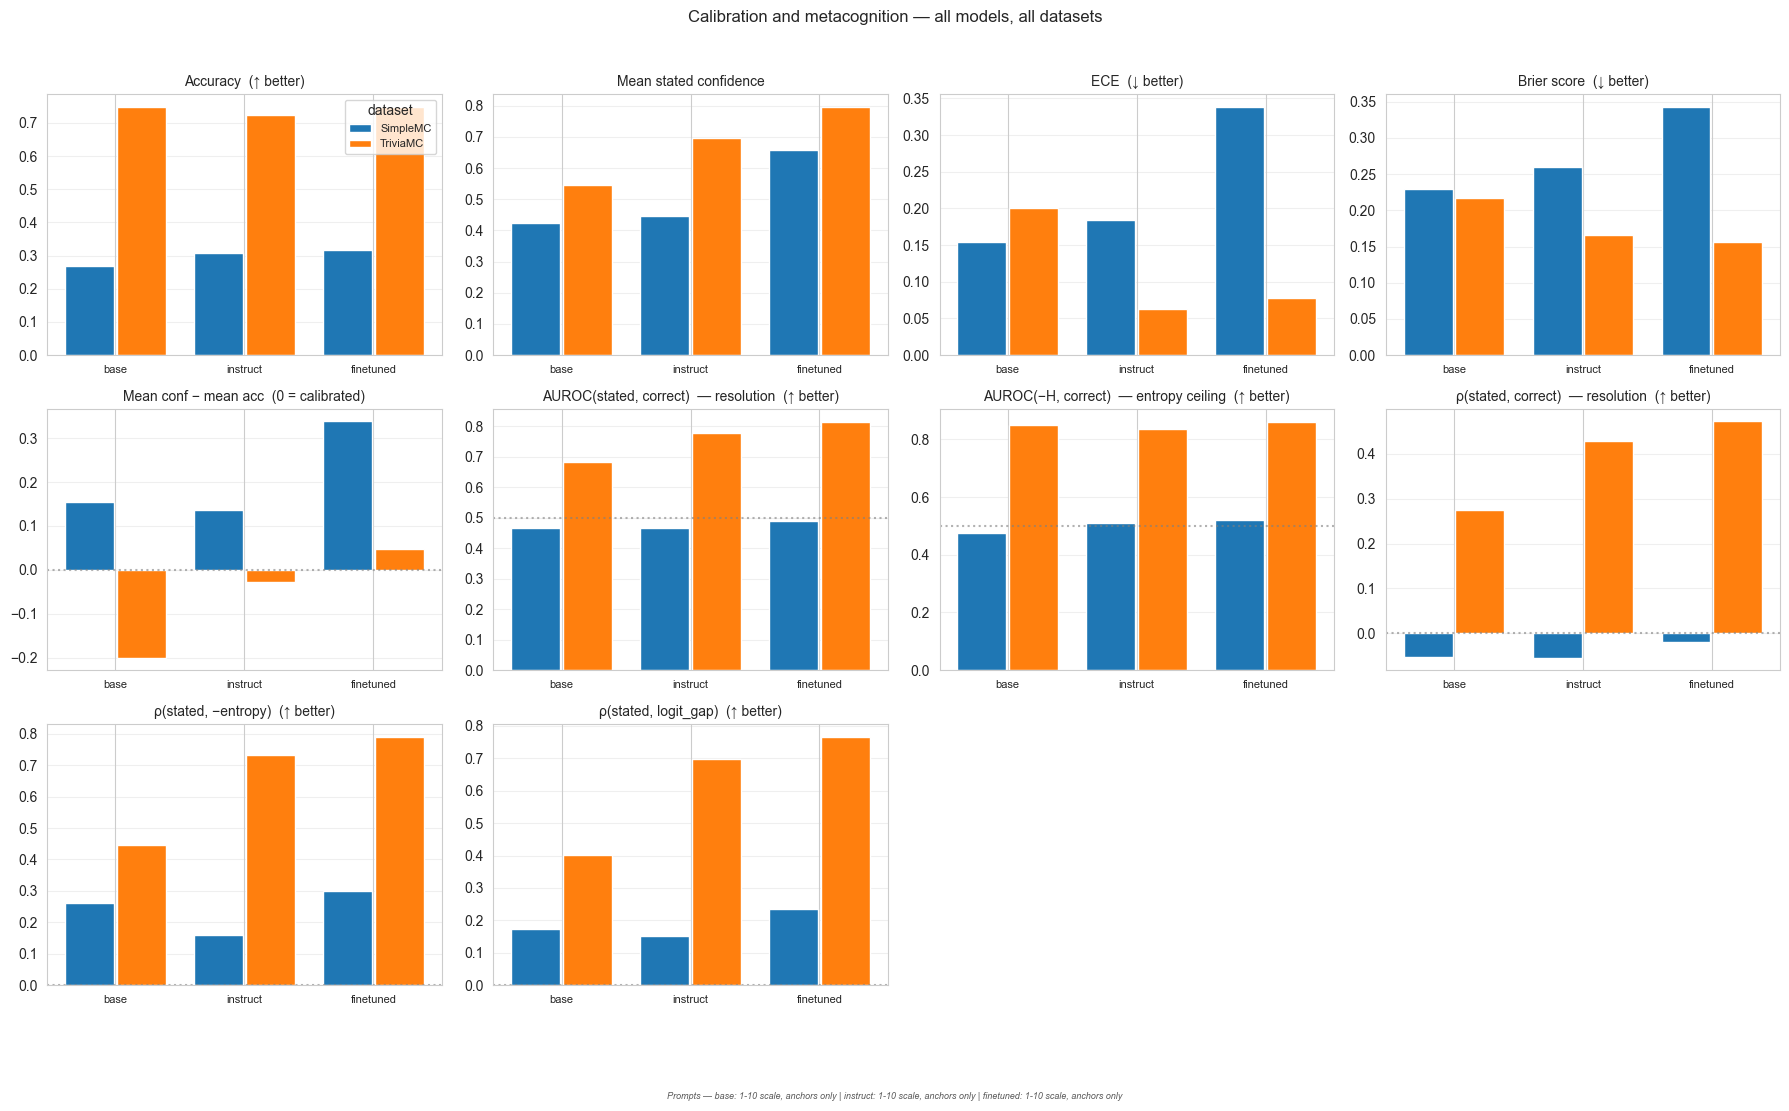

In [15]:
# --- Section 1.9: Calibration + metacognition summary (scale-agnostic) ---
# Assumes stated_confidence_numeric ∈ [0,1] (set upstream from scale midpoints).
# Calibration metrics treat stated confidence as a probability estimate for is_correct.
# Metacognition metrics are Spearman correlations so they're robust to the
# discretization of the scale (letters vs numeric).

from sklearn.metrics import roc_auc_score

def _ece(conf, correct, n_bins=10):
    """Expected Calibration Error over equal-width confidence bins."""
    conf = np.asarray(conf, dtype=float)
    correct = np.asarray(correct, dtype=float)
    mask = ~np.isnan(conf) & ~np.isnan(correct)
    conf, correct = conf[mask], correct[mask]
    if len(conf) == 0:
        return float('nan')
    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(conf, bins) - 1, 0, n_bins - 1)
    ece = 0.0
    n = len(conf)
    for b in range(n_bins):
        sel = idx == b
        if sel.sum() == 0: continue
        ece += (sel.sum() / n) * abs(conf[sel].mean() - correct[sel].mean())
    return float(ece)

def _brier(conf, correct):
    conf = np.asarray(conf, dtype=float); correct = np.asarray(correct, dtype=float)
    mask = ~np.isnan(conf) & ~np.isnan(correct)
    if mask.sum() == 0: return float('nan')
    return float(np.mean((conf[mask] - correct[mask]) ** 2))

def _auroc(score, correct):
    """AUROC of `score` as a discriminator of correct/incorrect.
    Invariant to monotonic transforms of `score` -- a clean resolution metric
    that cannot be inflated by mean shifts in confidence."""
    score = np.asarray(score, dtype=float); correct = np.asarray(correct, dtype=float)
    m = ~np.isnan(score) & ~np.isnan(correct)
    if m.sum() < 10: return float('nan')
    if len(np.unique(correct[m])) < 2: return float('nan')
    return float(roc_auc_score(correct[m].astype(int), score[m]))

def _spear(a, b):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    m = ~np.isnan(a) & ~np.isnan(b)
    if m.sum() < 10: return float('nan')
    res = spearmanr(a[m], b[m])
    return float(res.correlation if hasattr(res, 'correlation') else res.statistic)

META_METRICS = []
for (model, dataset), run in RUNS.items():
    df = run.df
    conf = df['stated_confidence_numeric'].values
    correct = df['is_correct'].values.astype(float)
    valid = ~np.isnan(conf) & ~np.isnan(correct)
    c, y = conf[valid], correct[valid]

    # AUROC ceiling: how well does -entropy itself rank correct vs incorrect?
    # AUROC(stated) cannot exceed this; the gap is what introspection has to close.
    neg_ent = -df['entropy'].values if 'entropy' in df.columns else None

    row = {
        'model': model,
        'dataset': dataset,
        'n': int(valid.sum()),
        'accuracy': float(y.mean()) if len(y) else float('nan'),
        'mean_stated_conf': float(c.mean()) if len(c) else float('nan'),
        'ECE': _ece(c, y),
        'Brier': _brier(c, y),
        'overconfidence': (float(c.mean() - y.mean()) if len(c) and len(y) else float('nan')),
        'AUROC(stated)':  _auroc(conf, correct),
        'AUROC(-H)':      _auroc(neg_ent, correct) if neg_ent is not None else float('nan'),
        'ρ(stated↔correct)': _spear(conf, correct),
        'ρ(stated↔-entropy)': _spear(conf, -df['entropy'].values) if 'entropy' in df.columns else float('nan'),
        'ρ(stated↔logit_gap)': _spear(conf, df['logit_gap'].values) if 'logit_gap' in df.columns else float('nan'),
        'ρ(stated↔top_prob)': _spear(conf, df['top_prob'].values) if 'top_prob' in df.columns else float('nan'),
    }
    META_METRICS.append(row)

META_DF = pd.DataFrame(META_METRICS)
# Enforce model order from MODELS dict (datasets kept in insertion order)
_present_models = [m for m in MODELS if m in META_DF['model'].values]
META_DF['model'] = pd.Categorical(META_DF['model'], categories=_present_models, ordered=True)
META_DF = META_DF.sort_values(['dataset', 'model']).reset_index(drop=True)

print('\n=== Section 1.9 summary: calibration + metacognition ===')
print(META_DF.round(3).to_string(index=False))

# --- Grouped-bar plot: panel per metric, x=model, one bar per dataset ---
metrics_to_plot = [
    ('accuracy',             'Accuracy  (↑ better)'),
    ('mean_stated_conf',     'Mean stated confidence'),
    ('ECE',                  'ECE  (↓ better)'),
    ('Brier',                'Brier score  (↓ better)'),
    ('overconfidence',       'Mean conf − mean acc  (0 = calibrated)'),
    ('AUROC(stated)',        'AUROC(stated, correct)  — resolution  (↑ better)'),
    ('AUROC(-H)',            'AUROC(−H, correct)  — entropy ceiling  (↑ better)'),
    ('ρ(stated↔correct)',   'ρ(stated, correct)  — resolution  (↑ better)'),
    ('ρ(stated↔-entropy)',  'ρ(stated, −entropy)  (↑ better)'),
    ('ρ(stated↔logit_gap)', 'ρ(stated, logit_gap)  (↑ better)'),
]

datasets_present = list(META_DF['dataset'].unique())
models_present = _present_models
n_ds = max(1, len(datasets_present))
width = 0.8 / n_ds
x = np.arange(len(models_present))

n_metrics = len(metrics_to_plot)
n_cols = 4
n_rows = (n_metrics + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.3 * n_rows))
axes = np.atleast_1d(axes).flatten()

for i, (key, title) in enumerate(metrics_to_plot):
    ax = axes[i]
    for j, ds in enumerate(datasets_present):
        vals = []
        for m in models_present:
            sub = META_DF[(META_DF['model'] == m) & (META_DF['dataset'] == ds)]
            vals.append(sub[key].iloc[0] if len(sub) else float('nan'))
        offset = (j - (n_ds - 1) / 2) * width
        ax.bar(x + offset, vals, width=width * 0.95, label=ds)
    ax.set_xticks(x)
    ax.set_xticklabels(models_present, fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    if key.startswith('ρ') or key == 'overconfidence':
        ax.axhline(0, color='gray', linestyle=':', alpha=0.6)
    if key.startswith('AUROC'):
        ax.axhline(0.5, color='gray', linestyle=':', alpha=0.6)
    if i == 0:
        ax.legend(fontsize=8, title='dataset', loc='best')

for k in range(n_metrics, len(axes)):
    axes[k].axis('off')

plt.suptitle('Calibration and metacognition — all models, all datasets', y=1.02, fontsize=12)
plt.tight_layout()
save_fig(FIGURES_DIR / 's1_metacognition_summary.pdf')
plt.show()


### Section 1.10 — Delegation game analysis

**Setup.** Under `META_TASK="delegate"` the model decides whether to answer the MC question itself or delegate to a teammate. Two prompt designs are supported:

- **`mc_integrated`** (current default): single-shot **A/B/C/D/T** prompt — A/B/C/D answer with that choice, T delegates to the teammate. No mapping alternation, one forward pass per question. `P(Answer) = 1 − P(T)` is the confidence signal; in-game correctness comes from `game_is_correct` (did the emitted letter match `correct_answer`?).
- **`two_step_digit`** (legacy): separate 1-vs-2 decision with per-trial alternating mapping. Controls for digit position by mapping, but produces a 50/50 artifact if the model has a fixed digit preference.

**Teammate accuracy.** Set via `TEAMMATE_ACCURACY` in `run_introspection_experiment.py`. The default is 0.7, which creates a meaningful decision boundary for models with ~70–80% MC accuracy. At 0.5 teammate accuracy, delegation is strictly worse than self-answer for any capable model — a trivial "always answer" policy wins.

**Metrics per (model, dataset):**
- `design` — which prompt design the run used (`mc_integrated` vs `two_step_digit`).
- `delegate_rate`, `mean_P_answer` — baseline descriptors.
- `acc_all` — direct-MC accuracy (always-answer baseline).
- `acc_answered` — in-game accuracy on self-answered items only. Under `mc_integrated` this can differ from `acc_all` because the policy pass's MC answer can differ from the direct pass's.
- `team_score` — `(self-correct-in-game + delegated×teammate_acc) / n`. Reads right off the game's payoff.
- `team_vs_always_answer`, `team_vs_always_delegate` — does the policy beat the trivial alternatives?
- `AURC` (↓), `EU(c=1)` — selective-prediction quality.
- `ρ(P_answer ↔ correct)` — resolution. `ρ(P_answer ↔ −entropy)` — does P(Answer) track internal uncertainty?
- `letter_skew` — fraction of trials where the model picked the most-common response letter. **Low = well-spread responses; ≥85% = response collapse.**

**Four figures:**
0. **Response distribution** — per (model, dataset), the fraction of each raw response letter. A/B/C/D/T under `mc_integrated`; 1/2 under the legacy design. This is the first place to look for response collapse.
1. **Metric panels** — 10 panels, grouped bars. On the team-score panel, dashed = always-answer baseline, dotted = always-delegate baseline (= teammate accuracy).
2. **Delegation rate by MC-entropy quartile** — low (Q1, model confident) vs high (Q4, model uncertain). Introspective behavior: red bars should be meaningfully taller than blue bars. Flat bars ⇒ delegation decisions ignore the model's own uncertainty.
3. **Risk–coverage curves** — per dataset, one line per model. Higher/more-concave curves mean `P(Answer)` ranks winners above losers.

**Response-collapse caveat.** If the model always picks one letter (e.g. always "2" under legacy, or always "A" under `mc_integrated`), the plots measure a prompt-format artifact, not metacognition. Watch `letter_skew`: the printed summary flags any (model, dataset) at ≥85%.


  loaded delegate (mc_integrated): base/SimpleMC  n=500  teammate_acc=70%
  loaded delegate (mc_integrated): base/TriviaMC  n=800  teammate_acc=70%
  loaded delegate (mc_integrated): instruct/SimpleMC  n=500  teammate_acc=70%
  loaded delegate (mc_integrated): instruct/TriviaMC  n=800  teammate_acc=70%
  loaded delegate (mc_integrated): finetuned/SimpleMC  n=500  teammate_acc=70%
  loaded delegate (mc_integrated): finetuned/TriviaMC  n=800  teammate_acc=70%

=== Section 1.10 summary: delegation game ===
    model  dataset   n        design  teammate_acc  delegate_rate  mean_P_answer  acc_all  acc_answered  team_score  team_vs_always_answer  team_vs_always_delegate  AURC  EU(c=1)  EU(c=1)_vs_always_answer  ρ(P_answer↔correct)  ρ(P_answer↔-entropy)  delegate_rate_low_entropy_q  delegate_rate_high_entropy_q  letter_skew
     base SimpleMC 500 mc_integrated           0.7          0.930          0.618    0.278         0.257       0.669                  0.391                   -0.031 0.947  

/var/folders/43/_0d5jq894wvgs7d31w0ccq980000gn/T/ipykernel_6845/1009859035.py:115: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risk, coverage))


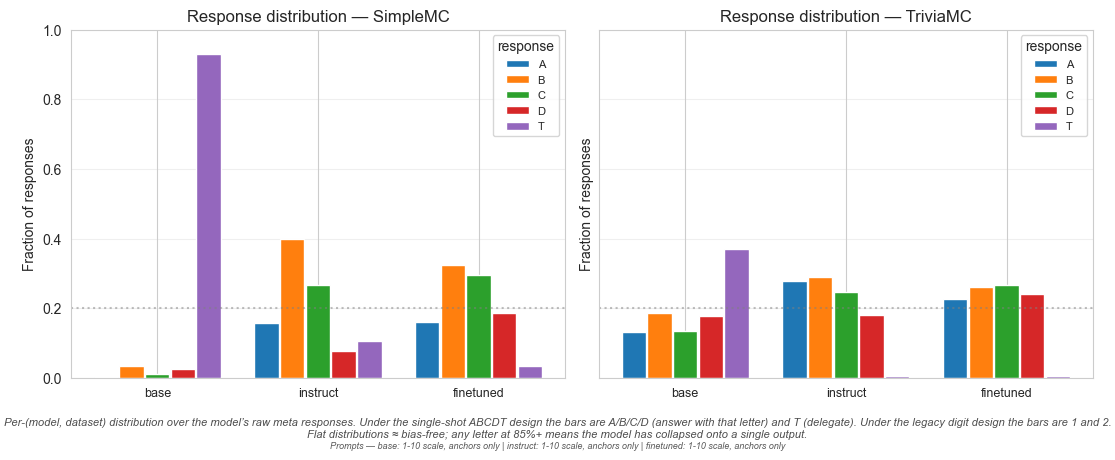

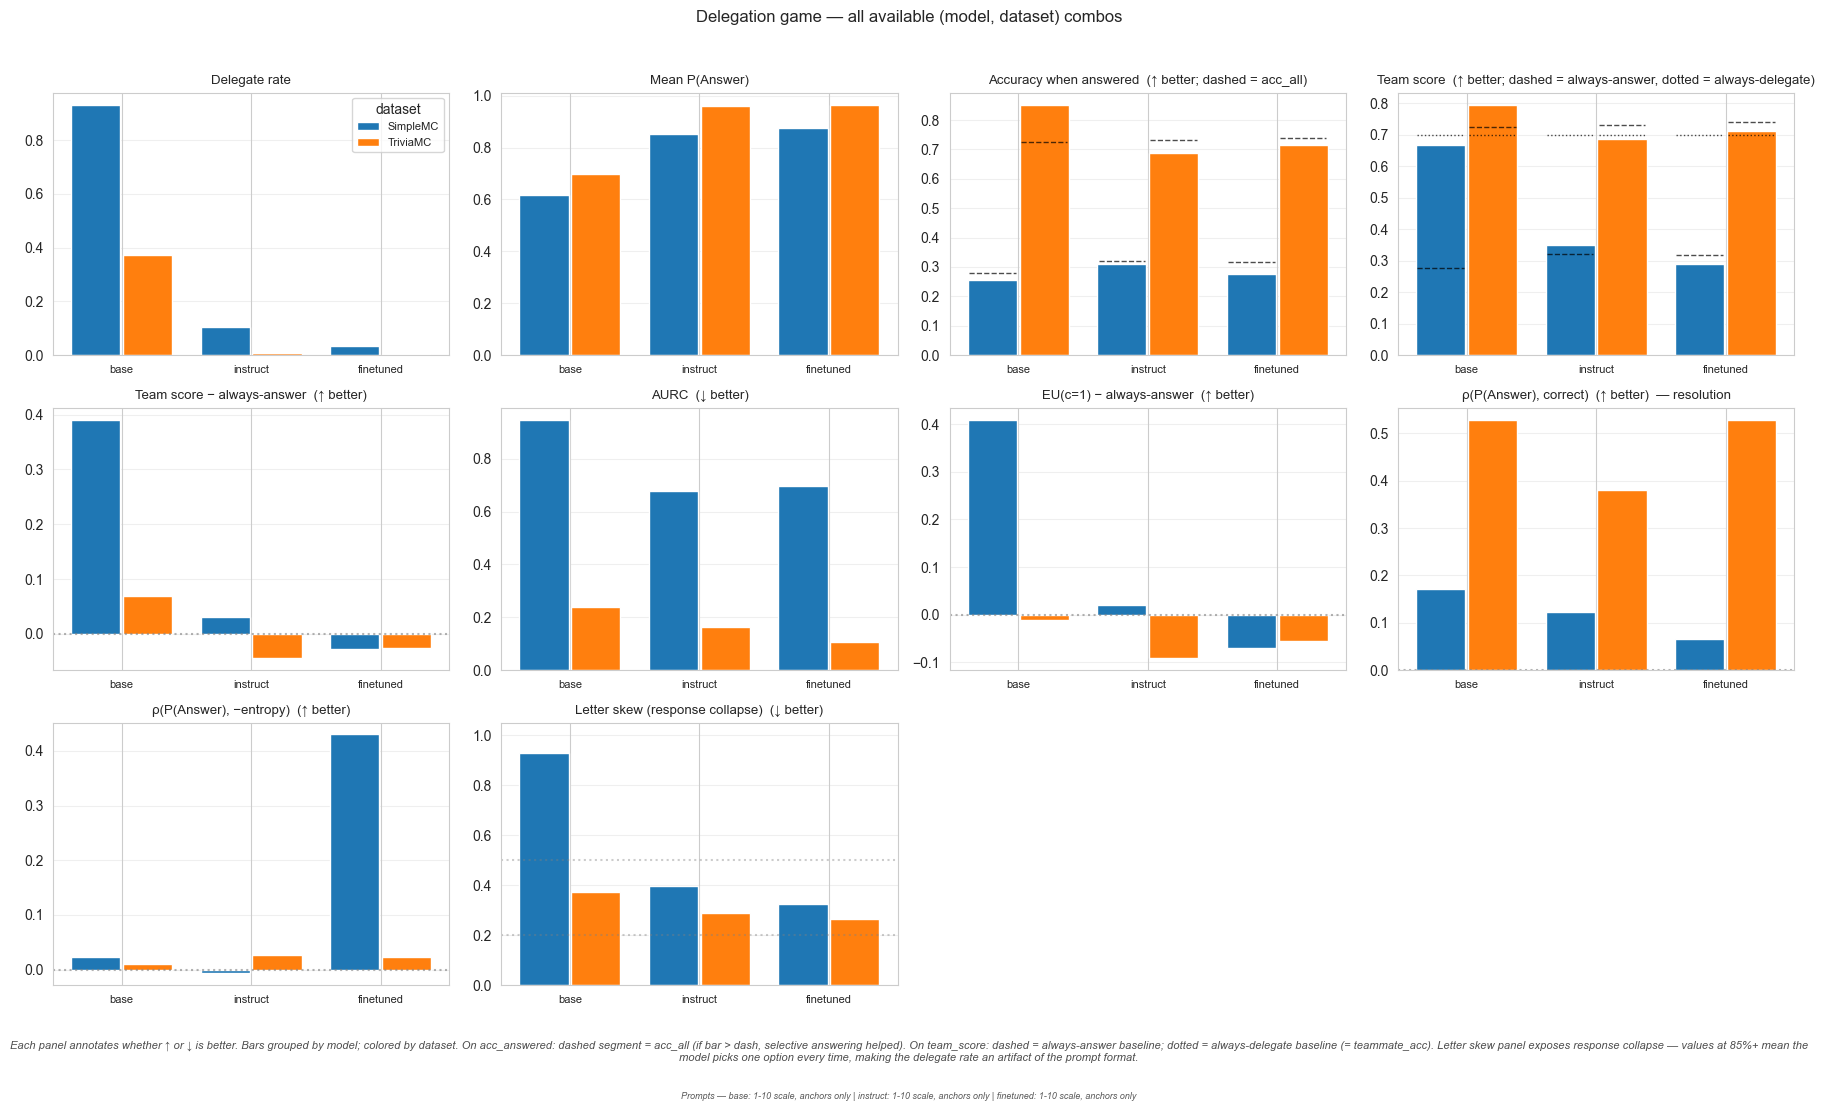

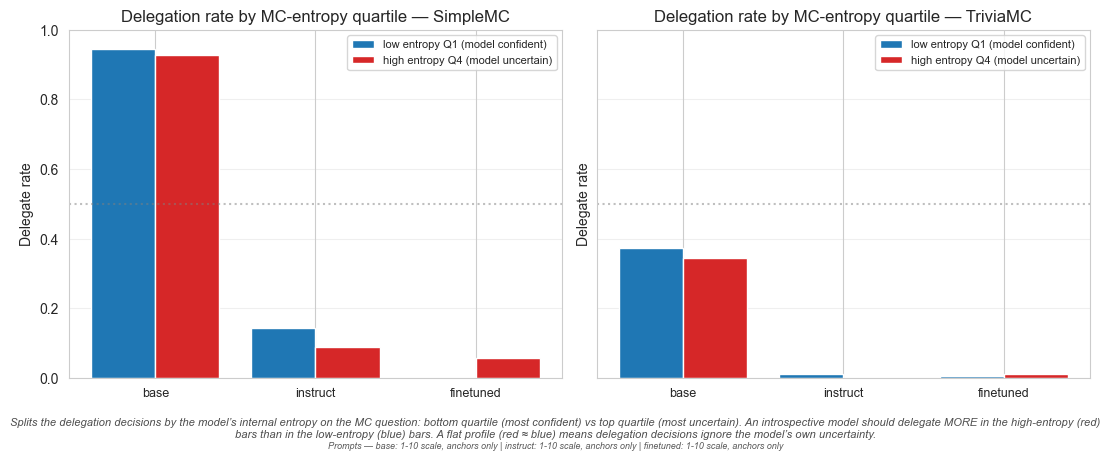

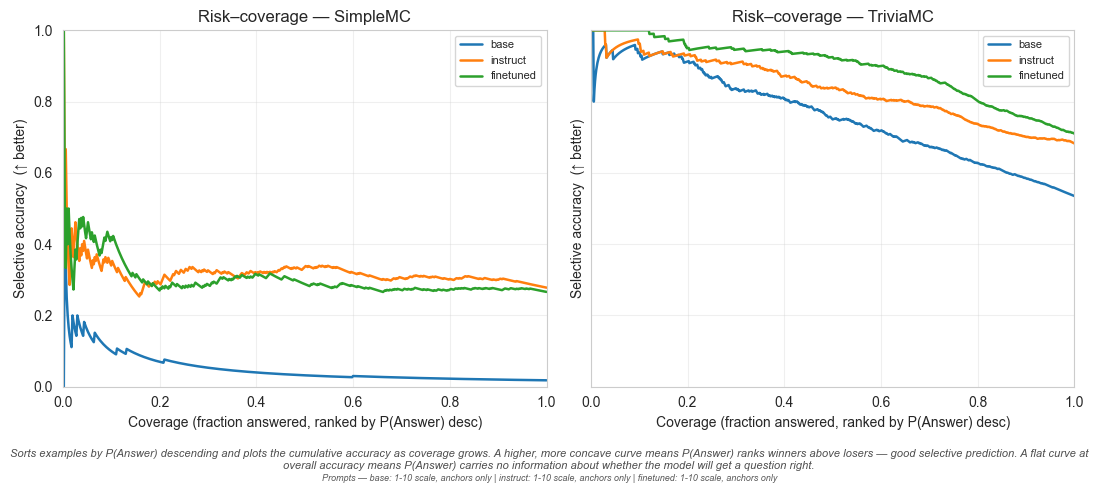

In [16]:
# --- Section 1.10: Delegation game analysis ---
# Loads delegate-mode paired_data.json for each (model, dataset) via _resolve_paths.
# Supports two prompt designs:
#   - "mc_integrated" (new): single-shot A/B/C/D/T; meta_probs shape (n, 5),
#     meta_responses in {A,B,C,D,T}, mapping is None. Game correctness comes
#     from a stored `game_is_correct` field.
#   - "two_step_digit" (legacy): 1-vs-2 decision with alternating mapping.

DELEGATE_DATA = {}  # (model, dataset) -> per-example arrays + config
for model in MODELS:
    for dataset in DATASETS:
        try:
            paths = _resolve_paths(model, dataset, meta_task='delegate')
        except Exception:
            continue
        if paths.get('paired_data') is None or not paths['paired_data'].exists():
            continue
        with open(paths['paired_data']) as f:
            paired = json.load(f)

        meta_probs = np.array(paired.get('meta_probs', []), dtype=float)
        meta_resp  = paired.get('meta_responses', [])
        mappings   = paired.get('meta_mappings', []) or []
        is_correct = np.array(paired.get('is_correct', []), dtype=float)
        n = len(is_correct)
        if n == 0:
            continue

        cfg = paired.get('config', {}) or {}
        delegate_cfg = cfg.get('delegate_params') or {}
        prompt_design = delegate_cfg.get('prompt_design', 'two_step_digit')
        meta_option_keys = delegate_cfg.get('meta_option_keys')
        teammate_accuracy = float(delegate_cfg.get('teammate_accuracy', 0.5))

        if prompt_design == 'mc_integrated':
            if meta_option_keys is None:
                meta_option_keys = ['A', 'B', 'C', 'D', 'T']
            if meta_probs.shape != (n, len(meta_option_keys)):
                print(f'  skip {model}/{dataset}: expected shape ({n}, {len(meta_option_keys)}), got {meta_probs.shape}')
                continue
            t_idx = meta_option_keys.index('T')
            p_answer = 1.0 - meta_probs[:, t_idx]
            chose_answer = np.array([str(r) != 'T' for r in meta_resp])
            # game_is_correct from the meta pass (MC letter == correct_answer)
            game_raw = paired.get('game_is_correct')
            if game_raw is not None and len(game_raw) == n:
                game_correct = np.array(game_raw, dtype=float)
            else:
                correct_letters = [q.get('correct_answer', '') for q in paired.get('questions', [])]
                if len(correct_letters) == n:
                    game_correct = np.array(
                        [(r != 'T') and (r == c) for r, c in zip(meta_resp, correct_letters)],
                        dtype=float,
                    )
                else:
                    game_correct = is_correct.astype(float)
        else:
            # legacy two_step_digit
            if meta_probs.shape != (n, 2):
                print(f'  skip {model}/{dataset}: legacy expected shape ({n}, 2), got {meta_probs.shape}')
                continue
            meta_option_keys = ['1', '2']
            p_answer = np.full(n, np.nan)
            chose_answer = np.zeros(n, dtype=bool)
            for i in range(n):
                m = mappings[i] if i < len(mappings) else {}
                if not m:
                    continue
                tokens = sorted(m.keys())
                ans_col = next((j for j, t in enumerate(tokens) if m.get(t) == 'Answer'), None)
                if ans_col is None:
                    continue
                p_answer[i] = float(meta_probs[i, ans_col])
                chose_answer[i] = str(meta_resp[i]) == tokens[ans_col]
            # Legacy: game_correct = is_correct for self-answered items (no separate meta MC pass)
            game_correct = is_correct.astype(float)

        # Attach entropy from the confidence-mode run (same MC questions, same order)
        ent = None
        if (model, dataset) in RUNS:
            ent = RUNS[(model, dataset)].df['entropy'].values
            if len(ent) != n:
                ent = None

        letter_dist = {k: float(np.mean([str(r) == k for r in meta_resp])) for k in meta_option_keys}

        DELEGATE_DATA[(model, dataset)] = {
            'p_answer': p_answer,
            'chose_answer': chose_answer,
            'is_correct': is_correct,         # direct-pass MC correctness
            'game_correct': game_correct,     # in-game MC correctness (== is_correct for legacy)
            'entropy': ent,
            'teammate_accuracy': teammate_accuracy,
            'meta_responses': [str(r) for r in meta_resp],
            'meta_option_keys': meta_option_keys,
            'letter_dist': letter_dist,
            'prompt_design': prompt_design,
        }
        print(f'  loaded delegate ({prompt_design}): {model}/{dataset}  n={n}  teammate_acc={teammate_accuracy:.0%}')

if not DELEGATE_DATA:
    print('\n⚠ No delegate-mode paired_data found. Run run_introspection_experiment.py with META_TASKS=["delegate"] to generate.')

# --- Compute metrics ---
def _aurc(p_answer, is_correct):
    """Area Under Risk-Coverage curve. Lower = better selective-prediction."""
    valid = ~np.isnan(p_answer) & ~np.isnan(is_correct)
    p, y = p_answer[valid], is_correct[valid]
    if len(p) < 10: return float('nan')
    order = np.argsort(-p)
    y_sorted = y[order]
    coverage = np.arange(1, len(y) + 1) / len(y)
    sel_acc = np.cumsum(y_sorted) / np.arange(1, len(y) + 1)
    risk = 1 - sel_acc
    return float(np.trapz(risk, coverage))

def _spear(a, b):
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    m = ~np.isnan(a) & ~np.isnan(b)
    if m.sum() < 10: return float('nan')
    res = spearmanr(a[m], b[m])
    return float(res.correlation if hasattr(res, 'correlation') else res.statistic)

def _entropy_quartile_delegation(ent, chose_answer):
    """Delegation rate in the low vs high entropy quartiles. Introspective agents
    should delegate MORE often in the high-entropy quartile."""
    if ent is None: return (float('nan'), float('nan'))
    valid = ~np.isnan(ent)
    e, ans = ent[valid], chose_answer[valid]
    if len(e) < 20: return (float('nan'), float('nan'))
    q25, q75 = np.quantile(e, 0.25), np.quantile(e, 0.75)
    low  = ~ans[e <= q25]; high = ~ans[e >= q75]
    return (float(low.mean()) if len(low) else float('nan'),
            float(high.mean()) if len(high) else float('nan'))

DELEGATE_METRICS = []
for (model, dataset), d in DELEGATE_DATA.items():
    pa, ans, yc_direct, yc_game, ent = (
        d['p_answer'], d['chose_answer'], d['is_correct'], d['game_correct'], d['entropy']
    )
    ta = d['teammate_accuracy']
    # acc_all is the direct-MC accuracy (always-answer baseline). Unchanged across designs.
    acc_all = float(np.nanmean(yc_direct)) if len(yc_direct) else float('nan')
    # acc_answered / team_score use the in-game correctness (what the model's policy actually earns).
    acc_ans = float(np.nanmean(yc_game[ans])) if ans.any() else float('nan')
    team = float(np.mean(np.where(ans, yc_game, ta)))
    always_answer = acc_all
    always_delegate = ta
    eu_c1 = float(np.mean(np.where(ans, np.where(yc_game.astype(bool), 1, -1), 0)))
    baseline_eu = 2 * acc_all - 1
    # Positional-bias diagnostic — max frac of any single option letter
    letter_dist = d['letter_dist']
    letter_skew = max(letter_dist.values()) if letter_dist else float('nan')
    del_low_q, del_high_q = _entropy_quartile_delegation(ent, ans)
    DELEGATE_METRICS.append({
        'model': model, 'dataset': dataset, 'n': int(len(yc_direct)),
        'design': d['prompt_design'],
        'teammate_acc': ta,
        'delegate_rate': float(1 - ans.mean()),
        'mean_P_answer': float(np.nanmean(pa)),
        'acc_all': acc_all,
        'acc_answered': acc_ans,
        'team_score': team,
        'team_vs_always_answer':  float(team - always_answer),
        'team_vs_always_delegate': float(team - always_delegate),
        'AURC': _aurc(pa, yc_game),
        'EU(c=1)': eu_c1,
        'EU(c=1)_vs_always_answer': float(eu_c1 - baseline_eu),
        'ρ(P_answer↔correct)': _spear(pa, yc_game),
        'ρ(P_answer↔-entropy)': _spear(pa, -ent) if ent is not None else float('nan'),
        'delegate_rate_low_entropy_q':  del_low_q,
        'delegate_rate_high_entropy_q': del_high_q,
        'letter_skew': letter_skew,
    })

DEL_DF = pd.DataFrame(DELEGATE_METRICS)
if len(DEL_DF):
    present_models = [m for m in MODELS if m in DEL_DF['model'].values]
    DEL_DF['model'] = pd.Categorical(DEL_DF['model'], categories=present_models, ordered=True)
    DEL_DF = DEL_DF.sort_values(['dataset', 'model']).reset_index(drop=True)
    print('\n=== Section 1.10 summary: delegation game ===')
    print(DEL_DF.round(3).to_string(index=False))
    # Positional-bias warning
    skewed = DEL_DF[DEL_DF['letter_skew'] > 0.85]
    if len(skewed):
        print('\n⚠  RESPONSE-COLLAPSE WARNING: in these runs the model almost always picks the same option.')
        print('   Under mc_integrated this means the model ignores the question; under two_step_digit')
        print('   this produces a 50/50 delegate rate as an alternating-mapping artifact.')
        for _, r in skewed.iterrows():
            print(f"    {r['model']}/{r['dataset']} ({r['design']}): max letter frac = {r['letter_skew']:.0%}")

# --- Figure 0: per-letter response distribution per (model, dataset) ---
if DELEGATE_DATA:
    # One panel per dataset; grouped bars by letter; x = models.
    datasets_with_data = sorted({ds for (_, ds) in DELEGATE_DATA})
    # Collect union of option keys so legacy (1/2) and mc_integrated (ABCDT) can share a figure.
    all_keys = []
    seen = set()
    for d in DELEGATE_DATA.values():
        for k in d['meta_option_keys']:
            if k not in seen:
                seen.add(k); all_keys.append(k)
    fig, axes = plt.subplots(1, len(datasets_with_data),
                             figsize=(5.5 * len(datasets_with_data), 4.2),
                             sharey=True)
    axes = np.atleast_1d(axes)
    for ax, dataset in zip(axes, datasets_with_data):
        models_here = [m for m in present_models if (m, dataset) in DELEGATE_DATA]
        x = np.arange(len(models_here))
        width = 0.8 / max(1, len(all_keys))
        for j, key in enumerate(all_keys):
            vals = []
            for m in models_here:
                d = DELEGATE_DATA[(m, dataset)]
                vals.append(d['letter_dist'].get(key, 0.0))
            offset = (j - (len(all_keys) - 1) / 2) * width
            ax.bar(x + offset, vals, width=width * 0.95, label=key)
        ax.set_xticks(x); ax.set_xticklabels(models_here, fontsize=9)
        ax.set_ylim(0, 1.0)
        ax.set_ylabel('Fraction of responses')
        ax.set_title(f'Response distribution — {dataset}')
        ax.grid(True, alpha=0.3, axis='y')
        ax.axhline(1.0 / max(1, len(all_keys)), color='gray', linestyle=':', alpha=0.5)
        ax.legend(fontsize=8, title='response', loc='best')
    caption0 = (
        'Per-(model, dataset) distribution over the model\u2019s raw meta responses. Under the '
        'single-shot ABCDT design the bars are A/B/C/D (answer with that letter) and T (delegate). '
        'Under the legacy digit design the bars are 1 and 2. Flat distributions ≈ bias-free; any '
        'letter at 85%+ means the model has collapsed onto a single output.'
    )
    fig.text(0.5, -0.05, caption0, ha='center', fontsize=8, style='italic', color='0.3', wrap=True)
    plt.tight_layout()
    save_fig(FIGURES_DIR / 's1_delegation_response_distribution.pdf')
    plt.show()

# --- Figure 1: grouped-bar metric panels with ↑/↓ better markers ---
if len(DEL_DF):
    metrics_to_plot = [
        ('delegate_rate',              'Delegate rate'),
        ('mean_P_answer',              'Mean P(Answer)'),
        ('acc_answered',               'Accuracy when answered  (↑ better; dashed = acc_all)'),
        ('team_score',                 'Team score  (↑ better; dashed = always-answer, dotted = always-delegate)'),
        ('team_vs_always_answer',      'Team score − always-answer  (↑ better)'),
        ('AURC',                       'AURC  (↓ better)'),
        ('EU(c=1)_vs_always_answer',  'EU(c=1) − always-answer  (↑ better)'),
        ('ρ(P_answer↔correct)',       'ρ(P(Answer), correct)  (↑ better)  — resolution'),
        ('ρ(P_answer↔-entropy)',      'ρ(P(Answer), −entropy)  (↑ better)'),
        ('letter_skew',                'Letter skew (response collapse)  (↓ better)'),
    ]
    datasets_present = list(DEL_DF['dataset'].unique())
    models_present = present_models
    n_ds = max(1, len(datasets_present))
    width = 0.8 / n_ds
    x = np.arange(len(models_present))
    n_metrics = len(metrics_to_plot)
    n_cols = 4
    n_rows = (n_metrics + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.3 * n_rows))
    axes = np.atleast_1d(axes).flatten()
    for i, (key, title) in enumerate(metrics_to_plot):
        ax = axes[i]
        for j, ds in enumerate(datasets_present):
            vals = []
            for m in models_present:
                sub = DEL_DF[(DEL_DF['model'] == m) & (DEL_DF['dataset'] == ds)]
                vals.append(sub[key].iloc[0] if len(sub) else float('nan'))
            offset = (j - (n_ds - 1) / 2) * width
            ax.bar(x + offset, vals, width=width * 0.95, label=ds)
        if key == 'acc_answered':
            for j, ds in enumerate(datasets_present):
                for k, m in enumerate(models_present):
                    sub = DEL_DF[(DEL_DF['model'] == m) & (DEL_DF['dataset'] == ds)]
                    if len(sub):
                        off = (j - (n_ds - 1) / 2) * width
                        ax.plot([k + off - width*0.45, k + off + width*0.45],
                                [float(sub['acc_all'].iloc[0])] * 2,
                                color='black', linestyle='--', linewidth=1, alpha=0.7)
        if key == 'team_score':
            for j, ds in enumerate(datasets_present):
                for k, m in enumerate(models_present):
                    sub = DEL_DF[(DEL_DF['model'] == m) & (DEL_DF['dataset'] == ds)]
                    if len(sub):
                        off = (j - (n_ds - 1) / 2) * width
                        ax.plot([k + off - width*0.45, k + off + width*0.45],
                                [float(sub['acc_all'].iloc[0])] * 2,
                                color='black', linestyle='--', linewidth=1, alpha=0.7)
                        ax.plot([k + off - width*0.45, k + off + width*0.45],
                                [float(sub['teammate_acc'].iloc[0])] * 2,
                                color='black', linestyle=':', linewidth=1, alpha=0.7)
        if key == 'letter_skew':
            # Chance floor depends on number of options used (2 for legacy, 5 for mc_integrated).
            # Show the worst-case chance (0.5, for two-option runs) as a reference line.
            ax.axhline(0.5, color='gray', linestyle=':', alpha=0.4)
            ax.axhline(0.2, color='gray', linestyle=':', alpha=0.4)
            ax.set_ylim(0, 1.05)
        ax.set_xticks(x); ax.set_xticklabels(models_present, fontsize=8)
        ax.set_title(title, fontsize=9.5)
        ax.grid(True, alpha=0.3, axis='y')
        if key.startswith('ρ') or key in ('EU(c=1)_vs_always_answer', 'team_vs_always_answer'):
            ax.axhline(0, color='gray', linestyle=':', alpha=0.6)
        if i == 0:
            ax.legend(fontsize=8, title='dataset', loc='best')
    for k in range(n_metrics, len(axes)):
        axes[k].axis('off')
    plt.suptitle('Delegation game — all available (model, dataset) combos', y=1.02, fontsize=12)
    caption = (
        'Each panel annotates whether ↑ or ↓ is better. Bars grouped by model; colored by dataset. '
        'On acc_answered: dashed segment = acc_all (if bar > dash, selective answering helped). '
        'On team_score: dashed = always-answer baseline; dotted = always-delegate baseline (= teammate_acc). '
        'Letter skew panel exposes response collapse — values at 85%+ mean the model picks one option '
        'every time, making the delegate rate an artifact of the prompt format.'
    )
    fig.text(0.5, -0.04, caption, ha='center', fontsize=8, style='italic', color='0.3', wrap=True)
    plt.tight_layout()
    save_fig(FIGURES_DIR / 's1_delegation_metrics.pdf')
    plt.show()

# --- Figure 2: delegation rate by entropy quartile (low vs high) ---
if len(DEL_DF):
    datasets_present = list(DEL_DF['dataset'].unique())
    fig, axes = plt.subplots(1, len(datasets_present), figsize=(5.5 * len(datasets_present), 4.2), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, dataset in zip(axes, datasets_present):
        models_here = [m for m in models_present if ((DEL_DF['model'] == m) & (DEL_DF['dataset'] == dataset)).any()]
        x = np.arange(len(models_here))
        low_vals, high_vals = [], []
        for m in models_here:
            sub = DEL_DF[(DEL_DF['model'] == m) & (DEL_DF['dataset'] == dataset)]
            low_vals.append(float(sub['delegate_rate_low_entropy_q'].iloc[0]))
            high_vals.append(float(sub['delegate_rate_high_entropy_q'].iloc[0]))
        ax.bar(x - 0.2, low_vals,  width=0.4, label='low entropy Q1 (model confident)', color='tab:blue')
        ax.bar(x + 0.2, high_vals, width=0.4, label='high entropy Q4 (model uncertain)', color='tab:red')
        ax.set_xticks(x); ax.set_xticklabels(models_here, fontsize=9)
        ax.set_ylim(0, 1.0)
        ax.set_ylabel('Delegate rate')
        ax.set_title(f'Delegation rate by MC-entropy quartile — {dataset}')
        ax.grid(True, alpha=0.3, axis='y')
        ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
        ax.legend(fontsize=8, loc='best')
    caption2 = (
        'Splits the delegation decisions by the model\u2019s internal entropy on the MC question: bottom '
        'quartile (most confident) vs top quartile (most uncertain). An introspective model should delegate '
        'MORE in the high-entropy (red) bars than in the low-entropy (blue) bars. A flat profile (red ≈ '
        'blue) means delegation decisions ignore the model\u2019s own uncertainty.'
    )
    fig.text(0.5, -0.05, caption2, ha='center', fontsize=8, style='italic', color='0.3', wrap=True)
    plt.tight_layout()
    save_fig(FIGURES_DIR / 's1_delegation_by_entropy.pdf')
    plt.show()

# --- Figure 3: risk–coverage curves (introspection-readout diagnostic) ---
if DELEGATE_DATA:
    datasets_with_data = sorted({ds for (_, ds) in DELEGATE_DATA})
    fig, axes = plt.subplots(1, len(datasets_with_data), figsize=(5.5 * len(datasets_with_data), 4.5), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, dataset in zip(axes, datasets_with_data):
        for model in MODELS:
            if (model, dataset) not in DELEGATE_DATA:
                continue
            d = DELEGATE_DATA[(model, dataset)]
            pa, yc = d['p_answer'], d['game_correct']
            valid = ~np.isnan(pa) & ~np.isnan(yc)
            p, y = pa[valid], yc[valid]
            order = np.argsort(-p)
            y_sorted = y[order]
            coverage = np.arange(1, len(y) + 1) / len(y)
            sel_acc = np.cumsum(y_sorted) / np.arange(1, len(y) + 1)
            color = MODEL_COLORS.get(model) if 'MODEL_COLORS' in globals() else None
            ax.plot(coverage, sel_acc, label=model, linewidth=1.8, color=color)
        ax.set_xlabel('Coverage (fraction answered, ranked by P(Answer) desc)')
        ax.set_ylabel('Selective accuracy  (↑ better)')
        ax.set_title(f'Risk–coverage — {dataset}')
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='best')
    caption3 = (
        'Sorts examples by P(Answer) descending and plots the cumulative accuracy as coverage grows. '
        'A higher, more concave curve means P(Answer) ranks winners above losers — good selective '
        'prediction. A flat curve at overall accuracy means P(Answer) carries no information about '
        'whether the model will get a question right.'
    )
    fig.text(0.5, -0.05, caption3, ha='center', fontsize=8, style='italic', color='0.3', wrap=True)
    plt.tight_layout()
    save_fig(FIGURES_DIR / 's1_delegation_risk_coverage.pdf')
    plt.show()


**Section 1 summary (fill in after running):**

- Entropy distributions: _TBD — are they right-skewed as expected?_
- Correlation matrix: _TBD — are entropy/logit_gap/top_prob/margin ≥ 0.9 correlated?_
- Reliability diagrams: _TBD — is instruct/finetuned monotone? Is base flat (expected)?_
- Quartile counts: _TBD — any underpowered cells flagged?_
- `entropy_balanced_subset` helper working: _TBD_

Any ⚠️ flags above should be investigated before moving to Section 2.

---
## Section 2: Within-model linear probes

**Purpose:** For each (model, dataset, layer), fit ridge-regression (or logistic-regression for `is_correct`) probes on direct-prompt activations to predict:
- `margin_logit` (primary, linear)
- `margin_prob` (prob-space)
- `entropy`
- `stated_confidence_numeric`
- `is_correct` (classification)

Also fit mean-difference contrastive directions for top-quartile vs bottom-quartile entropy (discard middle 50% for fitting). Save probe weights, held-out projections, and direction vectors to `CACHE_DIR`.

**Evaluation:** 5-fold CV, held-out R² (accuracy for classification). Report on both natural and entropy-balanced subsets.

**Hypothesis relevance:**
- Margin R² **increases base→finetuned** at matched layers → **H2**.
- Margin R² already **high in base, unchanged** → **H1**.
- R² gains **concentrate in final layers** → **H3**.

**Key figure:** Layer-wise R² curves per (dataset, target), one line per model.

In [17]:
# --- Section 2.1: Probe fitting helper (cached with data fingerprint) ---
from tqdm.auto import tqdm
from sklearn.metrics import r2_score
import hashlib


def _fingerprint(run: RunData) -> str:
    """Short hash summarizing activations + key targets. Auto-invalidates cache
    if examples, layers, or target values change between runs."""
    parts = [
        f'n={run.n_examples}', f'L={run.n_layers}', f'd={run.d_model}',
        f'l0_sum={float(run.direct_acts[:, 0, :].astype(np.float32).sum()):.6e}',
        f'lN_sum={float(run.direct_acts[:, -1, :].astype(np.float32).sum()):.6e}',
    ]
    for t in ['entropy', 'logit_gap', 'stated_confidence_numeric', 'is_correct']:
        if t in run.df.columns:
            vals = run.df[t].values
            parts.append(f'{t}_sum={np.nansum(vals.astype(float)):.6e}')
    return hashlib.md5('|'.join(parts).encode()).hexdigest()[:16]


def _targets_for_run(run: RunData):
    """Return dict of target_name -> (y_array, kind, valid_mask)."""
    out = {}
    for tname, tcfg in TARGETS.items():
        vals = np.asarray(run.df[tcfg['col']].values)
        if tcfg['kind'] == 'classification':
            valid = ~pd.isna(vals)
            y = np.array(vals, dtype=float)
            y = np.where(valid, y, 0).astype(int)
        else:
            valid = ~pd.isna(vals)
            y = vals.astype(float)
        out[tname] = (y, tcfg['kind'], valid)
    return out


def fit_probes_for_run(run: RunData, cache: bool = True, verbose: bool = True) -> dict:
    """Fit linear probes at every layer for every target in TARGETS.

    Caching: results pickled to outputs/analysis_cache/probes_{model}_{dataset}.pkl
    with a data fingerprint. On load, fingerprint is checked against current data;
    mismatch triggers a refit. Delete the pkl file to force refit regardless.
    """
    fp = _fingerprint(run)
    # Cache filename includes the fingerprint so probes trained on different
    # runs (e.g. 1-10 vs S-Z) coexist instead of overwriting each other.
    cache_file = CACHE_DIR / f'probes_{run.model}_{run.dataset}_{fp}.pkl'
    legacy_cache = CACHE_DIR / f'probes_{run.model}_{run.dataset}.pkl'

    if cache and cache_file.exists():
        with open(cache_file, 'rb') as f:
            saved = pickle.load(f)
        if saved.get('_fingerprint') == fp:
            if verbose:
                print(f'  ✓ {run.model}/{run.dataset}: loaded cache (fingerprint {fp} OK)')
            return saved
    # Legacy (pre-fingerprint-in-filename) cache fallback. Migrate if it matches.
    if cache and legacy_cache.exists():
        with open(legacy_cache, 'rb') as f:
            saved = pickle.load(f)
        if saved.get('_fingerprint') == fp:
            with open(cache_file, 'wb') as f:
                pickle.dump(saved, f)
            if verbose:
                print(f'  ✓ {run.model}/{run.dataset}: migrated legacy cache → {cache_file.name}')
            return saved
        else:
            print(f'  ⚠ {run.model}/{run.dataset}: legacy cache fingerprint '
                  f'mismatch (cached={saved.get("_fingerprint")}, current={fp}) — refitting')

    cv = KFold(N_SPLITS, shuffle=True, random_state=SEED)
    targets = _targets_for_run(run)
    balanced_df = entropy_balanced_subset(run.df)
    balanced_idx = balanced_df.index.to_numpy()

    n_layers = run.n_layers
    results = {
        'layers': list(range(n_layers)),
        '_fingerprint': fp,
        'within_r2_natural':   {t: np.full(n_layers, np.nan) for t in TARGETS},
        'within_r2_balanced':  {t: np.full(n_layers, np.nan) for t in TARGETS},
        'probe_weights':       {t: [None] * n_layers for t in TARGETS},
        'held_out_preds':      {t: [None] * n_layers for t in TARGETS},
        'mean_diff_direction': [None] * n_layers,
    }

    entropy = run.df['entropy'].values
    q_low = np.quantile(entropy, 0.25)
    q_high = np.quantile(entropy, 0.75)
    mask_low = entropy <= q_low
    mask_high = entropy >= q_high

    iterator = range(n_layers)
    if verbose:
        iterator = tqdm(iterator, desc=f'{run.model}/{run.dataset}')

    for layer in iterator:
        X = run.direct_acts[:, layer, :].astype(np.float32)

        for tname, (y, kind, valid) in targets.items():
            X_v, y_v = X[valid], y[valid]

            if kind == 'regression':
                probe = Pipeline([('sc', StandardScaler()), ('ridge', RidgeCV(alphas=RIDGE_ALPHAS))])
                y_pred = cross_val_predict(probe, X_v, y_v, cv=cv)
                results['within_r2_natural'][tname][layer] = r2_score(y_v, y_pred)
                probe.fit(X_v, y_v)
                w = probe.named_steps['ridge'].coef_
            else:
                probe = Pipeline([
                    ('sc', StandardScaler()),
                    ('lr', LogisticRegressionCV(Cs=LOGIT_C, cv=N_SPLITS, max_iter=1000, n_jobs=-1)),
                ])
                y_pred = cross_val_predict(probe, X_v, y_v, cv=cv)
                results['within_r2_natural'][tname][layer] = float((y_pred == y_v).mean())
                probe.fit(X_v, y_v)
                w = probe.named_steps['lr'].coef_.ravel()

            norm = np.linalg.norm(w) + 1e-9
            results['probe_weights'][tname][layer] = (w / norm).astype(np.float32)
            full_pred = np.full(run.n_examples, np.nan)
            full_pred[np.where(valid)[0]] = y_pred
            results['held_out_preds'][tname][layer] = full_pred

            bi_valid = balanced_idx[valid[balanced_idx]]
            X_b, y_b = X[bi_valid], y[bi_valid]
            if kind == 'regression':
                probe_b = Pipeline([('sc', StandardScaler()), ('ridge', RidgeCV(alphas=RIDGE_ALPHAS))])
                y_pred_b = cross_val_predict(probe_b, X_b, y_b, cv=cv)
                results['within_r2_balanced'][tname][layer] = r2_score(y_b, y_pred_b)
            else:
                probe_b = Pipeline([
                    ('sc', StandardScaler()),
                    ('lr', LogisticRegressionCV(Cs=LOGIT_C, cv=N_SPLITS, max_iter=1000, n_jobs=-1)),
                ])
                y_pred_b = cross_val_predict(probe_b, X_b, y_b, cv=cv)
                results['within_r2_balanced'][tname][layer] = float((y_pred_b == y_b).mean())

        md = X[mask_high].mean(axis=0) - X[mask_low].mean(axis=0)
        md = md / (np.linalg.norm(md) + 1e-9)
        results['mean_diff_direction'][layer] = md.astype(np.float32)

    if cache:
        with open(cache_file, 'wb') as f:
            pickle.dump(results, f)
        print(f'  Cached probes to {cache_file.name}')

    return results



def ensure_probe_results(keys=None):
    """Populate PROBE_RESULTS[(model, dataset)] for each key in keys (default:
    every loaded run). Hits the on-disk cache if available (near-instant) and
    only trains for runs that don't have a cached fingerprint match.

    Idempotent: if a key is already in PROBE_RESULTS, it's skipped. Call this
    at the top of any section that uses PROBE_RESULTS to make it runnable
    without first executing Section 2.
    """
    global PROBE_RESULTS
    if 'PROBE_RESULTS' not in globals():
        PROBE_RESULTS = {}
    needed = list(keys) if keys is not None else list(RUNS.keys())
    for k in needed:
        if k in PROBE_RESULTS:
            continue
        if k not in RUNS:
            raise KeyError(f'No loaded run for {k}; check MODELS/DATASETS and re-run load_all_available().')
        PROBE_RESULTS[k] = fit_probes_for_run(RUNS[k], cache=True, verbose=False)
    return PROBE_RESULTS


In [18]:
# --- Section 2.2: Fit probes for all runs ---
# This is the slow cell. Expect ~5-15 min per (model, dataset) on first run; cached thereafter.
# Delete outputs/analysis_cache/probes_*.pkl to force refit.

PROBE_RESULTS = {}
for key, run in RUNS.items():
    PROBE_RESULTS[key] = fit_probes_for_run(run, cache=True, verbose=True)
    print(f'\nDone {key[0]}/{key[1]}. Best held-out R² (or accuracy) by target:')
    for tname in TARGETS:
        arr = PROBE_RESULTS[key]['within_r2_natural'][tname]
        best_layer = int(np.nanargmax(arr))
        kind = TARGETS[tname]['kind']
        metric = 'acc' if kind == 'classification' else 'R²'
        print(f'  {tname:20s}: layer {best_layer:2d}, {metric}={arr[best_layer]:.3f}')

  ✓ base/SimpleMC: loaded cache (fingerprint 831887dac9626650 OK)

Done base/SimpleMC. Best held-out R² (or accuracy) by target:
  margin_logit        : layer 28, R²=0.743
  margin_prob         : layer 28, R²=0.793
  entropy             : layer 29, R²=0.949
  stated_confidence   : layer 12, R²=0.425
  is_correct          : layer 14, acc=0.698
  ✓ base/TriviaMC: loaded cache (fingerprint 4758a1b5e805b08c OK)

Done base/TriviaMC. Best held-out R² (or accuracy) by target:
  margin_logit        : layer 30, R²=0.940
  margin_prob         : layer 29, R²=0.897
  entropy             : layer 30, R²=0.976
  stated_confidence   : layer 12, R²=0.545
  is_correct          : layer 21, acc=0.769
  ✓ instruct/SimpleMC: loaded cache (fingerprint dc028d9004c4f28b OK)

Done instruct/SimpleMC. Best held-out R² (or accuracy) by target:
  margin_logit        : layer 25, R²=-0.022
  margin_prob         : layer 25, R²=-0.036
  entropy             : layer 28, R²=-0.056
  stated_confidence   : layer  9, R²=-0.0

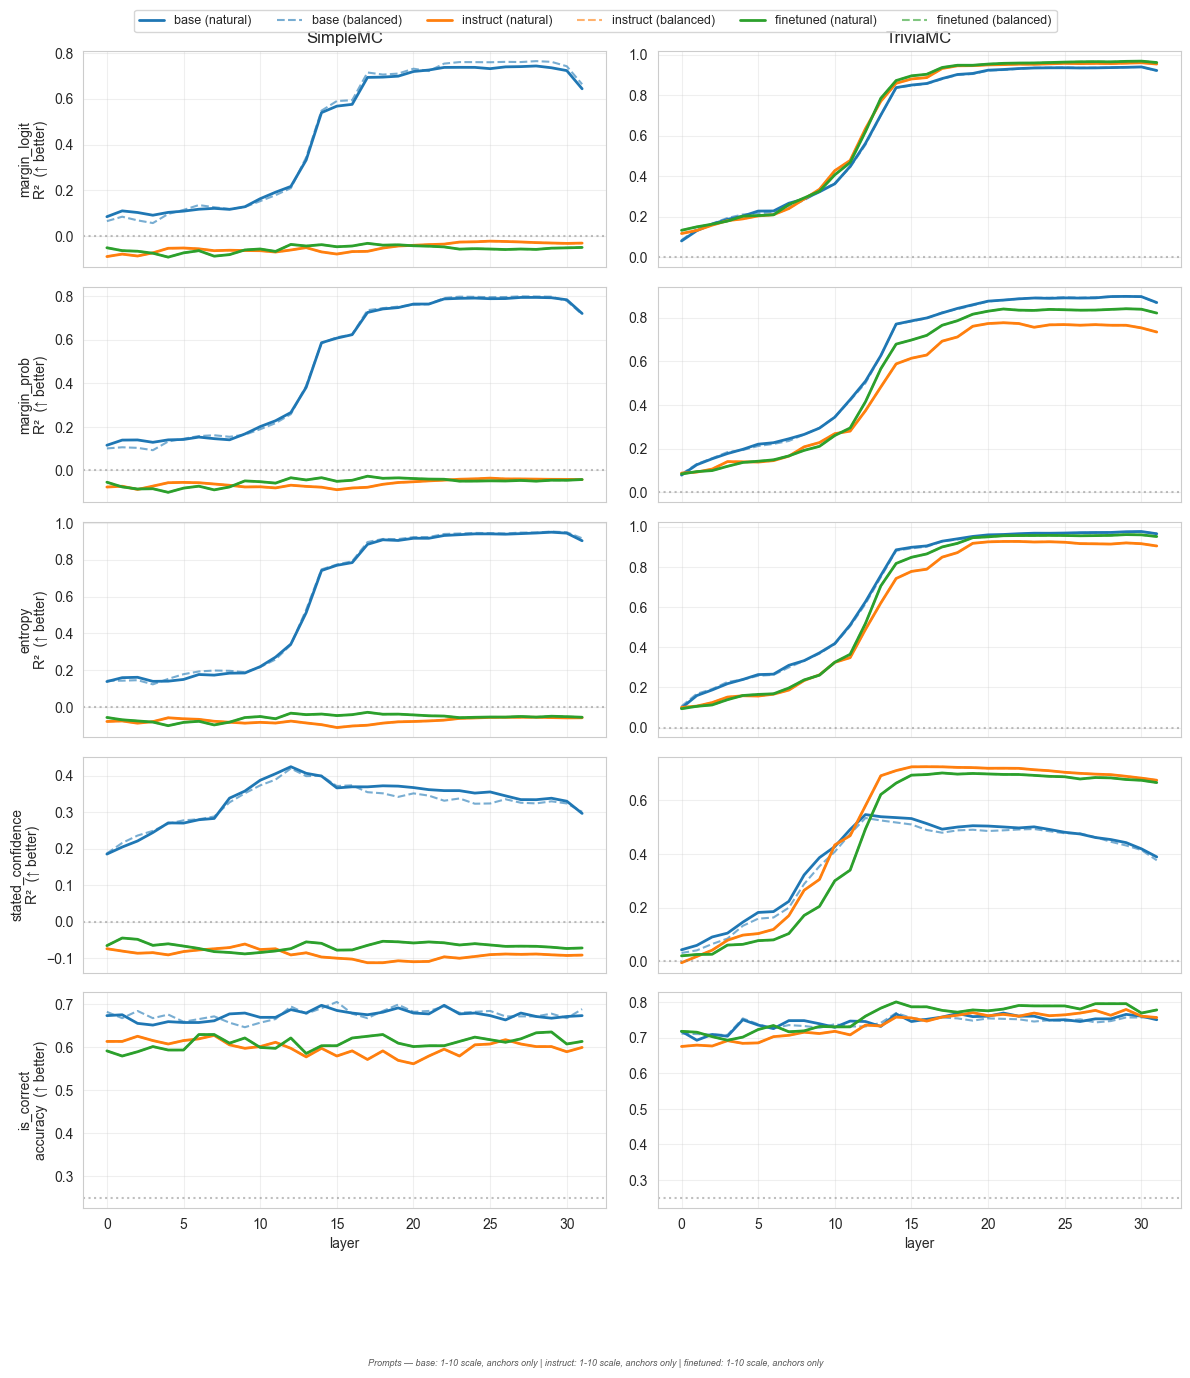


=== Section 2 summary: peak held-out R² (natural) per target ===

  target = margin_logit  (peak R² [peak layer])
    SimpleMC  : base=0.743 (L28)  finetuned=-0.031 (L17)  instruct=-0.022 (L25)  
    TriviaMC  : base=0.940 (L30)  finetuned=0.968 (L30)  instruct=0.960 (L30)  

  target = margin_prob  (peak R² [peak layer])
    SimpleMC  : base=0.793 (L28)  finetuned=-0.027 (L17)  instruct=-0.036 (L25)  
    TriviaMC  : base=0.897 (L29)  finetuned=0.841 (L29)  instruct=0.777 (L21)  

  target = entropy  (peak R² [peak layer])
    SimpleMC  : base=0.949 (L29)  finetuned=-0.029 (L17)  instruct=-0.056 (L28)  
    TriviaMC  : base=0.976 (L30)  finetuned=0.960 (L29)  instruct=0.926 (L22)  

  target = stated_confidence  (peak R² [peak layer])
    SimpleMC  : base=0.425 (L12)  finetuned=-0.045 (L1)  instruct=-0.061 (L9)  
    TriviaMC  : base=0.545 (L12)  finetuned=0.700 (L17)  instruct=0.723 (L16)  

  target = is_correct  (peak R² [peak layer])
    SimpleMC  : base=0.698 (L14)  finetuned=0.

In [19]:
# --- Section 2.3: Layer-wise R² curves + best-layer summary ---
ensure_probe_results()  # populate PROBE_RESULTS from cache if this cell is run standalone
MODEL_COLORS = {'base': 'tab:blue', 'instruct': 'tab:orange', 'finetuned': 'tab:green'}
TARGETS_TO_PLOT = ['margin_logit', 'margin_prob', 'entropy', 'stated_confidence', 'is_correct']

fig, axes = plt.subplots(
    len(TARGETS_TO_PLOT), len(DATASETS),
    figsize=(6 * len(DATASETS), 2.5 * len(TARGETS_TO_PLOT)),
    sharex=True,
)
if len(TARGETS_TO_PLOT) == 1: axes = np.atleast_2d(axes)
if len(DATASETS) == 1: axes = axes.reshape(-1, 1)

for ti, tname in enumerate(TARGETS_TO_PLOT):
    kind = TARGETS[tname]['kind']
    ylabel = 'accuracy  (↑ better)' if kind == 'classification' else 'R²  (↑ better)'
    for di, dataset in enumerate(DATASETS):
        ax = axes[ti, di]
        for model in MODELS:
            if (model, dataset) not in PROBE_RESULTS: continue
            res = PROBE_RESULTS[(model, dataset)]
            color = MODEL_COLORS.get(model, 'gray')
            ax.plot(res['layers'], res['within_r2_natural'][tname],
                    color=color, label=f'{model} (natural)', linewidth=2)
            ax.plot(res['layers'], res['within_r2_balanced'][tname],
                    color=color, linestyle='--', alpha=0.6, label=f'{model} (balanced)')
        if ti == 0: ax.set_title(f'{dataset}')
        if di == 0: ax.set_ylabel(f'{tname}\n{ylabel}')
        if ti == len(TARGETS_TO_PLOT) - 1: ax.set_xlabel('layer')
        if kind == 'classification':
            ax.axhline(0.25, linestyle=':', color='gray', alpha=0.5)
        else:
            ax.axhline(0.0, linestyle=':', color='gray', alpha=0.5)
        ax.grid(True, alpha=0.3)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.01),
           ncol=min(6, len(handles)), fontsize=9)
plt.tight_layout()
save_fig(FIGURES_DIR / 's2_layer_r2_curves.pdf')
plt.show()

# Text summary: best-layer R² per (target, model, dataset), natural subset
print('\n=== Section 2 summary: peak held-out R² (natural) per target ===')
rows = []
for (model, dataset), res in PROBE_RESULTS.items():
    for tname in TARGETS:
        arr = res['within_r2_natural'][tname]
        if np.all(np.isnan(arr)):
            continue
        best_layer = int(np.nanargmax(arr))
        rows.append({
            'model': model, 'dataset': dataset, 'target': tname,
            'peak_layer': best_layer,
            'peak_r2_natural': float(arr[best_layer]),
            'peak_r2_balanced': float(res['within_r2_balanced'][tname][best_layer]),
        })
summary_df = pd.DataFrame(rows).round(3)
# Pivot for easy cross-model comparison
for target in TARGETS:
    sub = summary_df[summary_df['target'] == target]
    if sub.empty: continue
    piv = sub.pivot_table(index='dataset', columns='model',
                          values='peak_r2_natural', aggfunc='first')
    piv_l = sub.pivot_table(index='dataset', columns='model',
                            values='peak_layer', aggfunc='first')
    print(f'\n  target = {target}  (peak R² [peak layer])')
    for dataset in piv.index:
        row = '    ' + f'{dataset:10s}: '
        for model in piv.columns:
            v = piv.loc[dataset, model]
            l = piv_l.loc[dataset, model]
            if pd.notna(v):
                row += f'{model}={v:.3f} (L{int(l)})  '
        print(row)


**Section 2 summary (fill in after running):**

Key comparisons (base vs instruct vs finetuned):
- `margin_logit` peak R²: _TBD_
- `stated_confidence` peak R²: _TBD_
- Does `margin_logit` R² **increase** base→finetuned at matched layers? (H2) _TBD_
- Is `margin_logit` R² already **high in base and unchanged**? (H1) _TBD_
- Do gains **concentrate in final 2-4 layers**? (H3) _TBD_

Flags:
- Base model `stated_confidence` should probably **not** be strongly decodable (it has no real introspective report to decode). If it is, the few-shot prompt may be leaking signal.
- Natural vs balanced R² should be close. Large gap → probe is exploiting class imbalance in entropy.

---
## Section 3: Cross-prediction analysis

**Purpose:** For each model × layer: fit probe on target X, predict target Y on held-out data. Pairs among `{margin_logit, entropy, stated_confidence, is_correct}`.

Report cross-R² and the ratio `cross_R2 / mean(within_R2_X, within_R2_Y)`.

**Key figure:** Layer-wise cross-R² for `margin_logit → stated_confidence`, alongside each within-R². Three subplots, one per model. **Distinguishes H1 from H2/H3.**

**Hypothesis relevance:**
- **H1:** cross margin→stated increases sharply base→finetuned; within-margin roughly unchanged.
- **H2:** both within and cross increase.
- **H3:** gain concentrated in late layers.

In [20]:
# --- Section 3.1: Cross-prediction computation (Spearman + 1D R²) ---
# For each (model, dataset, layer): use held_out_preds[X] from Section 2 as
# a per-example scalar, and measure how well it predicts target Y.
#
# We report THREE metrics (each has different interpretation):
#
#   1) Spearman ρ  — rank correlation between pred_X and true_Y.
#      Scale-free, robust to outliers, works for any Y (regression or binary).
#      Best for the money-figure question "does X's probe order items the
#      same way Y does?"
#
#   2) 1D-regression R²  — for regression Y only. Fit a 1D RidgeCV from
#      pred_X to true_Y on 5-fold CV, report held-out R². This answers
#      "if I let the model do a simple scale/shift adjustment, how much
#      of Y's variance does X's probe explain?" It upper-bounds Spearman
#      in terms of interpretability because it gives a real variance-
#      explained number on Y's native scale.
#
#   3) Threshold accuracy  — for classification Y only (is_correct).
#      Median-split pred_X, align with true_Y, report accuracy.
#
# Why the old R²(true_Y, pred_X) was broken: pred_X lives on X's scale
# (e.g., logit_gap in [0, 8]); plugging it into R² against true_Y in [0, 1]
# gives nonsense negative numbers. The 1D regression fixes this by fitting
# a scale/shift before scoring.

ensure_probe_results()  # populate PROBE_RESULTS from cache if this cell is run standalone
CROSS_TARGETS = ['margin_logit', 'entropy', 'stated_confidence', 'is_correct']


def compute_cross_prediction(run: RunData, probe_res: dict) -> dict:
    """Return dict with keys 'spearman', 'r2_1d', 'accuracy'.

    Each is nested: metric[target_X][target_Y] -> (n_layers,) array.
    """
    n_layers = run.n_layers
    out = {
        m: {x: {y: np.full(n_layers, np.nan) for y in CROSS_TARGETS} for x in CROSS_TARGETS}
        for m in ('spearman', 'r2_1d', 'accuracy')
    }
    cv = KFold(N_SPLITS, shuffle=True, random_state=SEED)

    for layer in range(n_layers):
        for tx in CROSS_TARGETS:
            pred_x = probe_res['held_out_preds'][tx][layer]  # already CV-held-out
            for ty in CROSS_TARGETS:
                col_y = TARGETS[ty]['col']
                true_y = np.asarray(run.df[col_y].values)
                mask = ~np.isnan(pred_x) & ~pd.isna(true_y)
                if mask.sum() < 20:
                    continue
                px = pred_x[mask]
                ty_vals = true_y[mask]

                # --- Spearman: works regardless of kind ---
                if np.std(px) > 1e-9 and np.std(ty_vals.astype(float)) > 1e-9:
                    rho = spearmanr(px, ty_vals).correlation
                    if rho is not None:
                        out['spearman'][tx][ty][layer] = float(rho)

                if TARGETS[ty]['kind'] == 'regression':
                    # --- 1D regression R² (scale/shift calibration of pred_X → true_Y) ---
                    yf = ty_vals.astype(float)
                    preds_1d = np.full(len(px), np.nan)
                    for tr, te in cv.split(px.reshape(-1, 1)):
                        reg = RidgeCV(alphas=RIDGE_ALPHAS).fit(px[tr].reshape(-1, 1), yf[tr])
                        preds_1d[te] = reg.predict(px[te].reshape(-1, 1))
                    valid = ~np.isnan(preds_1d)
                    if valid.sum() > 10:
                        out['r2_1d'][tx][ty][layer] = float(r2_score(yf[valid], preds_1d[valid]))
                else:
                    # --- Classification: median-threshold accuracy ---
                    ty_int = ty_vals.astype(int)
                    if len(np.unique(ty_int)) < 2:
                        continue
                    thresh = np.median(px)
                    high_pred = (px >= thresh).astype(int)
                    mean_high = ty_int[high_pred == 1].mean() if (high_pred == 1).any() else 0
                    mean_low = ty_int[high_pred == 0].mean() if (high_pred == 0).any() else 0
                    if mean_high < mean_low:
                        high_pred = 1 - high_pred
                    out['accuracy'][tx][ty][layer] = float((high_pred == ty_int).mean())
    return out


CROSS_RESULTS = {}
for key, run in RUNS.items():
    CROSS_RESULTS[key] = compute_cross_prediction(run, PROBE_RESULTS[key])
    print(f'Computed cross-prediction for {key}')


Computed cross-prediction for ('base', 'SimpleMC')
Computed cross-prediction for ('base', 'TriviaMC')
Computed cross-prediction for ('instruct', 'SimpleMC')
Computed cross-prediction for ('instruct', 'TriviaMC')
Computed cross-prediction for ('finetuned', 'SimpleMC')
Computed cross-prediction for ('finetuned', 'TriviaMC')


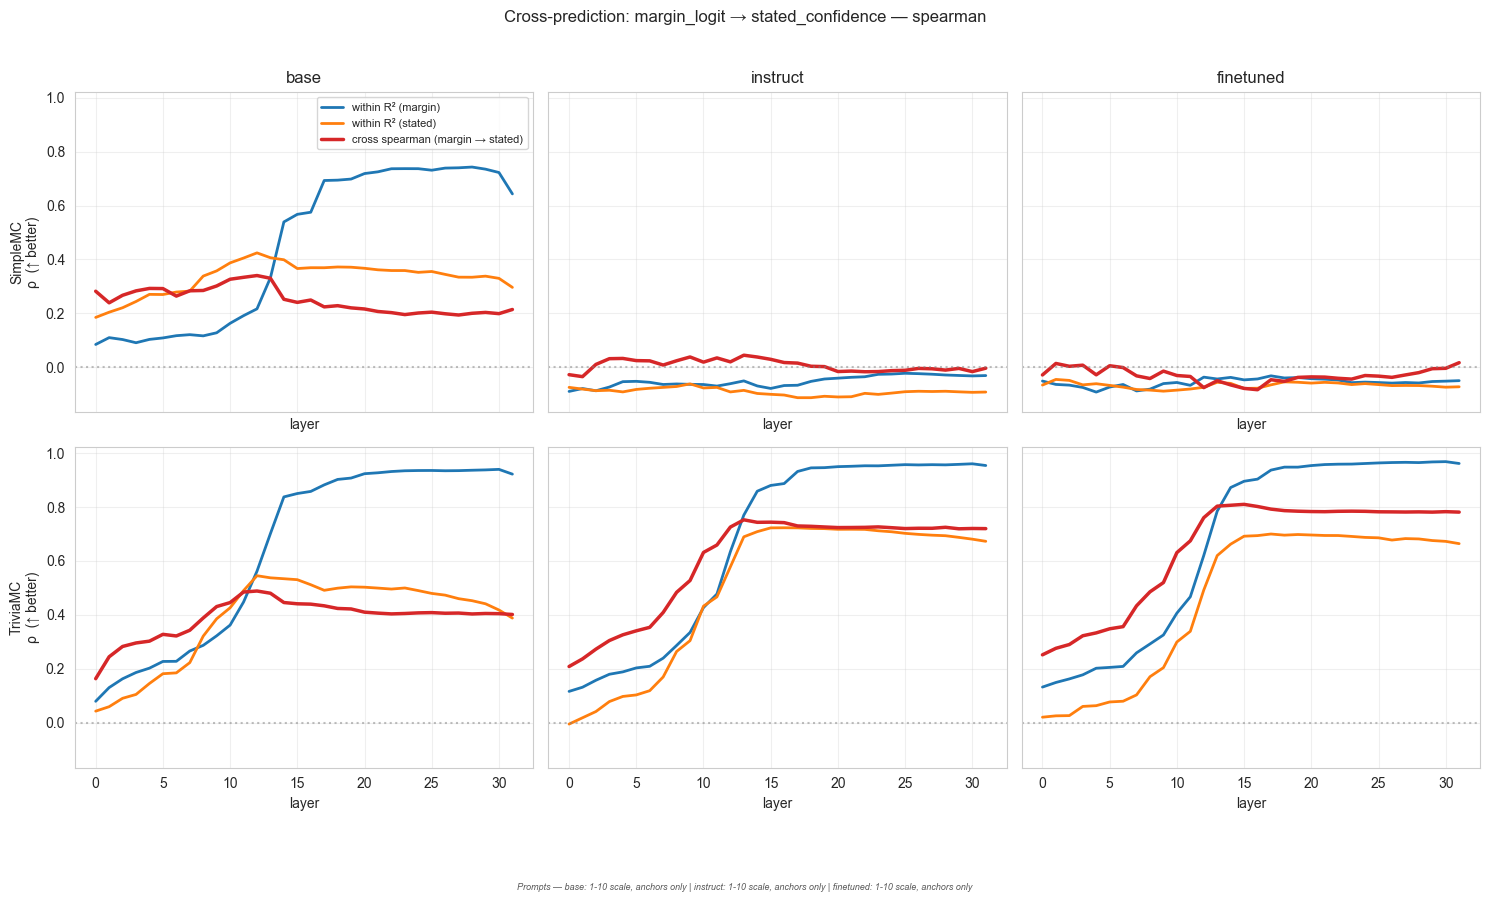

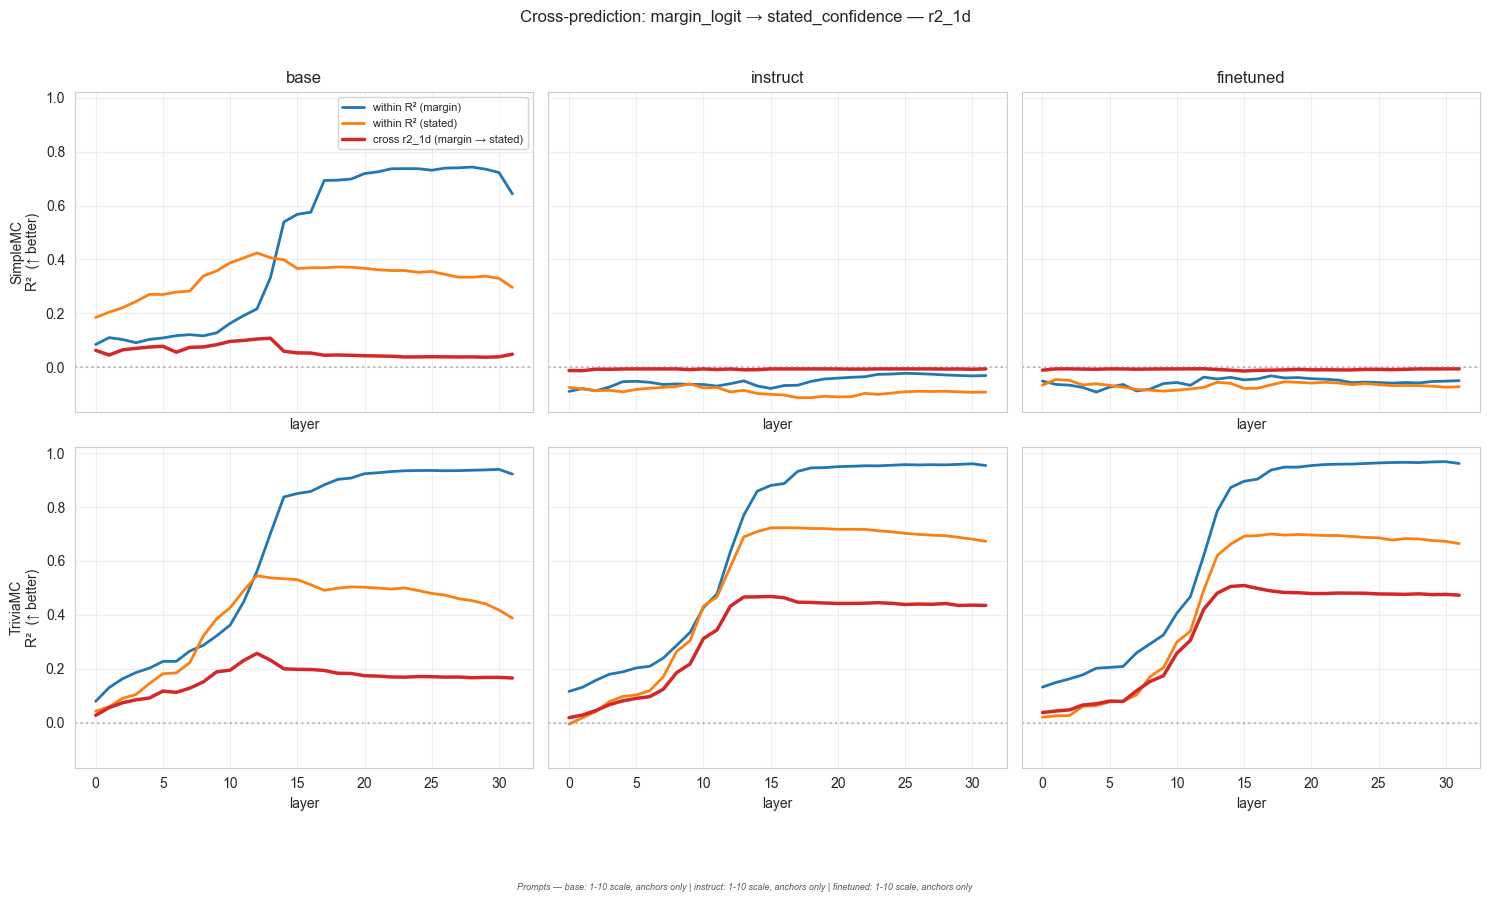


=== Section 3 summary: cross margin_logit → stated_confidence ===
    model  dataset  peak_L(ρ)  peak_spearman  peak_L(R²)  peak_r2_1d  within_margin_peak  within_stated_peak
     base SimpleMC         12          0.340          13       0.108               0.743               0.425
     base TriviaMC         12          0.489          12       0.257               0.940               0.545
 instruct SimpleMC         13          0.045          10      -0.006              -0.022              -0.061
 instruct TriviaMC         13          0.753          15       0.469               0.960               0.723
finetuned SimpleMC         16         -0.083          12      -0.005              -0.031              -0.045
finetuned TriviaMC         15          0.810          15       0.509               0.968               0.700

Interpretation cues:
  H1: cross peak grows base→finetuned while within_margin is roughly unchanged.
  H2: both within_margin and cross peak grow.
  H3: cross peak grows

In [21]:
# --- Section 3.2: Key figure — margin_logit → stated_confidence by layer ---
# Two rows per dataset: top = Spearman ρ; bottom = 1D-regression R².
# Within-R² shown in blue/orange (from Section 2) for reference.

ensure_probe_results()  # populate PROBE_RESULTS from cache if this cell is run standalone
present_models = [m for m in MODELS if any((m, d) in RUNS for d in DATASETS)]

for metric_name in ('spearman', 'r2_1d'):
    fig, axes = plt.subplots(
        len(DATASETS), len(present_models),
        figsize=(5 * len(present_models), 4 * len(DATASETS)),
        sharey=True, sharex=True,
    )
    axes = np.atleast_2d(axes)
    if len(DATASETS) == 1: axes = axes.reshape(1, -1)
    if len(present_models) == 1: axes = axes.reshape(-1, 1)

    for di, dataset in enumerate(DATASETS):
        for mi, model in enumerate(present_models):
            ax = axes[di, mi]
            key = (model, dataset)
            if key not in CROSS_RESULTS:
                ax.set_visible(False); continue
            pr = PROBE_RESULTS[key]
            cr = CROSS_RESULTS[key]
            layers = pr['layers']
            # Within-R² for reference (both are regression → R² is fine)
            ax.plot(layers, pr['within_r2_natural']['margin_logit'],
                    color='tab:blue', linewidth=2, label='within R² (margin)')
            ax.plot(layers, pr['within_r2_natural']['stated_confidence'],
                    color='tab:orange', linewidth=2, label='within R² (stated)')
            # Cross metric
            ax.plot(layers, cr[metric_name]['margin_logit']['stated_confidence'],
                    color='tab:red', linewidth=2.5,
                    label=f'cross {metric_name} (margin → stated)')
            ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
            if di == 0: ax.set_title(f'{model}')
            if mi == 0:
                label = 'R²  (↑ better)' if metric_name == 'r2_1d' else 'ρ  (↑ better)'
                ax.set_ylabel(f'{dataset}\n{label}')
            ax.set_xlabel('layer')
            ax.grid(True, alpha=0.3)
            if di == 0 and mi == 0: ax.legend(fontsize=8, loc='best')
    plt.suptitle(f'Cross-prediction: margin_logit → stated_confidence — {metric_name}', y=1.02)
    plt.tight_layout()
    save_fig(FIGURES_DIR / f's3_cross_margin_to_stated_{metric_name}.pdf')
    plt.show()

# Text summary: peak for each metric, plus decisive ratios
print('\n=== Section 3 summary: cross margin_logit → stated_confidence ===')
rows = []
for key in CROSS_RESULTS:
    model, dataset = key
    cr = CROSS_RESULTS[key]
    pr = PROBE_RESULTS[key]
    sp = cr['spearman']['margin_logit']['stated_confidence']
    r2 = cr['r2_1d']['margin_logit']['stated_confidence']
    if np.all(np.isnan(sp)):
        continue
    peak_layer_sp = int(np.nanargmax(np.abs(sp)))
    peak_layer_r2 = int(np.nanargmax(r2)) if not np.all(np.isnan(r2)) else np.nan
    rows.append({
        'model': model, 'dataset': dataset,
        'peak_L(ρ)': peak_layer_sp,
        'peak_spearman': float(sp[peak_layer_sp]),
        'peak_L(R²)': peak_layer_r2,
        'peak_r2_1d': float(r2[peak_layer_r2]) if not np.isnan(peak_layer_r2) else np.nan,
        'within_margin_peak': float(np.nanmax(pr['within_r2_natural']['margin_logit'])),
        'within_stated_peak': float(np.nanmax(pr['within_r2_natural']['stated_confidence'])),
    })
cs_df = pd.DataFrame(rows).round(3)
print(cs_df.to_string(index=False))
print('\nInterpretation cues:')
print('  H1: cross peak grows base→finetuned while within_margin is roughly unchanged.')
print('  H2: both within_margin and cross peak grow.')
print('  H3: cross peak grows only in late layers (compare peak_L across models).')


In [22]:
# --- Section 3.3: Full cross-prediction matrix at each model's best layer ---
# Uses Spearman ρ (scale-free). Diagonal equals within-probe Spearman of pred vs true.

ensure_probe_results()  # populate PROBE_RESULTS from cache if this cell is run standalone
print('=== Cross-prediction matrices (Spearman ρ) at each model\'s best margin_logit layer ===')
for key in CROSS_RESULTS:
    model, dataset = key
    cr = CROSS_RESULTS[key]['spearman']
    pr = PROBE_RESULTS[key]
    best_layer = int(np.nanargmax(pr['within_r2_natural']['margin_logit']))
    print(f'\n--- {model}/{dataset} @ layer {best_layer} ---')
    mat = pd.DataFrame(index=CROSS_TARGETS, columns=CROSS_TARGETS, dtype=float)
    for tx in CROSS_TARGETS:
        for ty in CROSS_TARGETS:
            mat.loc[tx, ty] = cr[tx][ty][best_layer]
    print(mat.round(3).to_string())


=== Cross-prediction matrices (Spearman ρ) at each model's best margin_logit layer ===

--- base/SimpleMC @ layer 28 ---
                   margin_logit  entropy  stated_confidence  is_correct
margin_logit              0.653   -0.853              0.201      -0.037
entropy                  -0.671    0.899             -0.233       0.030
stated_confidence         0.297   -0.449              0.572      -0.057
is_correct                0.027   -0.029             -0.012       0.004

--- base/TriviaMC @ layer 30 ---
                   margin_logit  entropy  stated_confidence  is_correct
margin_logit              0.948   -0.972              0.405       0.527
entropy                  -0.947    0.985             -0.443      -0.524
stated_confidence         0.615   -0.686              0.645       0.377
is_correct                0.533   -0.563              0.281       0.348

--- instruct/SimpleMC @ layer 25 ---
                   margin_logit  entropy  stated_confidence  is_correct
margin_logit   

**Section 3 summary (fill in after running):**

Money question: does cross R²(margin_logit → stated_confidence) **increase sharply** from base to finetuned, while the within-R² on margin stays roughly constant?
- Base cross R²: _TBD_
- Instruct cross R²: _TBD_
- Finetuned cross R²: _TBD_

Interpretation (fill in):
- Cross-R² increases sharply, within-margin constant → **supports H1** (readout improves, signal was already there)
- Both cross and within increase → **supports H2** (representation gets stronger)
- Gain concentrated in last few layers → **supports H3** (late-stage remap)

---
## Section 4: Cosine similarity and projection correlation 

**Purpose:** Diagnostic comparison between pairs of direction vectors within each model, per layer. Currently we compare three pairs:
- `margin_logit ↔ stated_confidence` (main pair for H1 signature)
- `entropy ↔ stated_confidence` (new: does stated-conf probe track entropy-like info?)
- `margin_logit ↔ entropy` (sanity: these should be very similar)

### Two metrics, two different questions

**1. Cosine similarity — geometric similarity of direction vectors**

\[
\text{cos}(\mathbf{w}_A, \mathbf{w}_B) = \frac{\mathbf{w}_A \cdot \mathbf{w}_B}{\|\mathbf{w}_A\| \cdot \|\mathbf{w}_B\|}
\]

Just the angle between two vectors in activation space. `cos = 1` → same direction; `cos = 0` → orthogonal; `cos = -1` → opposite. **Purely geometric, doesn\'t depend on data.**

**2. Projection correlation — population-level agreement of the two directions**

For each example `i` with activation vector `x_i`, compute the scalar projection onto each direction:

\[
p^A_i = x_i \cdot \mathbf{w}_A, \quad p^B_i = x_i \cdot \mathbf{w}_B
\]

Now you have two scalars per example. Pearson-correlate them across examples:

\[
\text{projcorr} = \text{corr}(p^A, p^B) \quad \text{over all examples}
\]

This asks: *when direction A says an example is "high," does direction B also say it is "high"?* **Depends on data — measures functional agreement, not geometry.**

### Why they can disagree

| cos | projcorr | Interpretation |
|---|---|---|
| High | High | Directions aligned, tracking the same signal. Expected for margin↔entropy. |
| **Low** | **High** | **⚠ Functionally equivalent but geometrically different.** The two directions live in different parts of activation space but happen to sort examples the same way. Means the two probes are decoding the same underlying factor through different routes. Important to flag in writeups. |
| High | Low | Directions aligned geometrically but the variance along one is orthogonal to the signal of interest in the data. Rare. |
| Low | Low | Directions genuinely independent. |

**Hypothesis relevance:** If `margin_logit` and `stated_confidence` probes have **low cos but high projcorr**, that supports **H1** — the stated-confidence probe is reading the existing margin/uncertainty signal through a different direction, not learning a separate representation.

**Added (per your request):** `entropy ↔ stated_confidence` comparison. Because we showed stated_confidence numerically correlates with entropy (via weighted-mean midpoint over soft probs), we expect the entropy direction to have **high projcorr** with the stated-confidence direction, even if their cosine is moderate.


In [23]:
# --- Section 4.1: Cosine + projection-correlation between direction pairs ---
#
# Directions compared below:
#   * marginProbe       — ridge probe fit to predict margin_logit
#   * entropyProbe      — ridge probe fit to predict entropy
#   * statedProbe       — ridge probe fit to predict stated_confidence_numeric
#   * entropyMeanDiff   — top-quartile vs bottom-quartile entropy mean-diff
#                         (precomputed in Section 2, stored per layer)
#   * statedMeanDiff    — top-quartile vs bottom-quartile stated_confidence_numeric
#                         mean-diff; computed here on the fly (no probe refit).
# All directions are unit-normalized.

ensure_probe_results()  # populate PROBE_RESULTS from cache if this cell is run standalone
def _cosine(a, b):
    """Cosine similarity — purely geometric angle between two direction vectors."""
    a = a.astype(np.float32); b = b.astype(np.float32)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9))


def _projcorr(X, w_A, w_B):
    """Pearson correlation of scalar projections onto two directions across examples."""
    p_A = X @ w_A.astype(np.float32)
    p_B = X @ w_B.astype(np.float32)
    if np.std(p_A) < 1e-9 or np.std(p_B) < 1e-9:
        return np.nan
    return float(np.corrcoef(p_A, p_B)[0, 1])


def _mean_diff_direction(X: np.ndarray, target: np.ndarray) -> np.ndarray:
    """Unit-normalized mean-diff direction: mean(top quartile) - mean(bottom quartile)
    of target values. X: (n, d); target: (n,). Returns (d,)."""
    vals = np.asarray(target, dtype=float)
    valid = ~np.isnan(vals)
    X_v, vals_v = X[valid], vals[valid]
    if len(vals_v) < 20:
        return np.zeros(X.shape[1], dtype=np.float32)
    q_low = np.quantile(vals_v, 0.25)
    q_high = np.quantile(vals_v, 0.75)
    high = X_v[vals_v >= q_high].mean(axis=0)
    low  = X_v[vals_v <= q_low].mean(axis=0)
    d = (high - low).astype(np.float32)
    return d / (np.linalg.norm(d) + 1e-9)


DIAGNOSTIC_PAIRS = [
    ('marginProbe ↔ statedProbe',              'margin_logit',       'stated_confidence'),
    ('entropyProbe ↔ statedProbe',             'entropy',            'stated_confidence'),
    ('entropyMeanDiff ↔ statedProbe',          'entropy_mean_diff',  'stated_confidence'),
    ('entropyMeanDiff ↔ statedMeanDiff',       'entropy_mean_diff',  'stated_mean_diff'),  # NEW
    ('entropyProbe ↔ statedMeanDiff',          'entropy',            'stated_mean_diff'),  # NEW
    ('marginProbe ↔ entropyProbe',             'margin_logit',       'entropy'),
    ('entropyProbe ↔ entropyMeanDiff',         'entropy',            'entropy_mean_diff'),
]


def _get_direction(probe_res, run, layer, key):
    """Resolve a direction key to a weight vector for this (layer, run)."""
    if key == 'entropy_mean_diff':
        return probe_res['mean_diff_direction'][layer]
    if key == 'stated_mean_diff':
        X = run.direct_acts[:, layer, :].astype(np.float32)
        y = run.df['stated_confidence_numeric'].values
        return _mean_diff_direction(X, y)
    w = probe_res['probe_weights'].get(key)
    return w[layer] if w is not None else None


def compute_direction_diagnostics(run: RunData, probe_res: dict) -> dict:
    """Per-layer cosine + projection correlation for each diagnostic pair.
    stated_mean_diff is computed on the fly (no cache invalidation)."""
    n_layers = run.n_layers
    out = {name: {'cos': np.full(n_layers, np.nan),
                  'projcorr': np.full(n_layers, np.nan)}
           for name, _, _ in DIAGNOSTIC_PAIRS}
    for layer in range(n_layers):
        X = run.direct_acts[:, layer, :].astype(np.float32)
        # Resolve all directions used at this layer once
        dirs = {}
        needed = set()
        for _, a, b in DIAGNOSTIC_PAIRS:
            needed.add(a); needed.add(b)
        for key in needed:
            dirs[key] = _get_direction(probe_res, run, layer, key)

        for name, key_A, key_B in DIAGNOSTIC_PAIRS:
            w_A, w_B = dirs.get(key_A), dirs.get(key_B)
            if w_A is None or w_B is None: continue
            out[name]['cos'][layer] = _cosine(w_A, w_B)
            out[name]['projcorr'][layer] = _projcorr(X, w_A, w_B)
    return out


DIRECTION_DIAGNOSTICS = {}
for key, run in RUNS.items():
    DIRECTION_DIAGNOSTICS[key] = compute_direction_diagnostics(run, PROBE_RESULTS[key])
    print(f'Computed direction diagnostics for {key}')


Computed direction diagnostics for ('base', 'SimpleMC')
Computed direction diagnostics for ('base', 'TriviaMC')
Computed direction diagnostics for ('instruct', 'SimpleMC')
Computed direction diagnostics for ('instruct', 'TriviaMC')
Computed direction diagnostics for ('finetuned', 'SimpleMC')
Computed direction diagnostics for ('finetuned', 'TriviaMC')


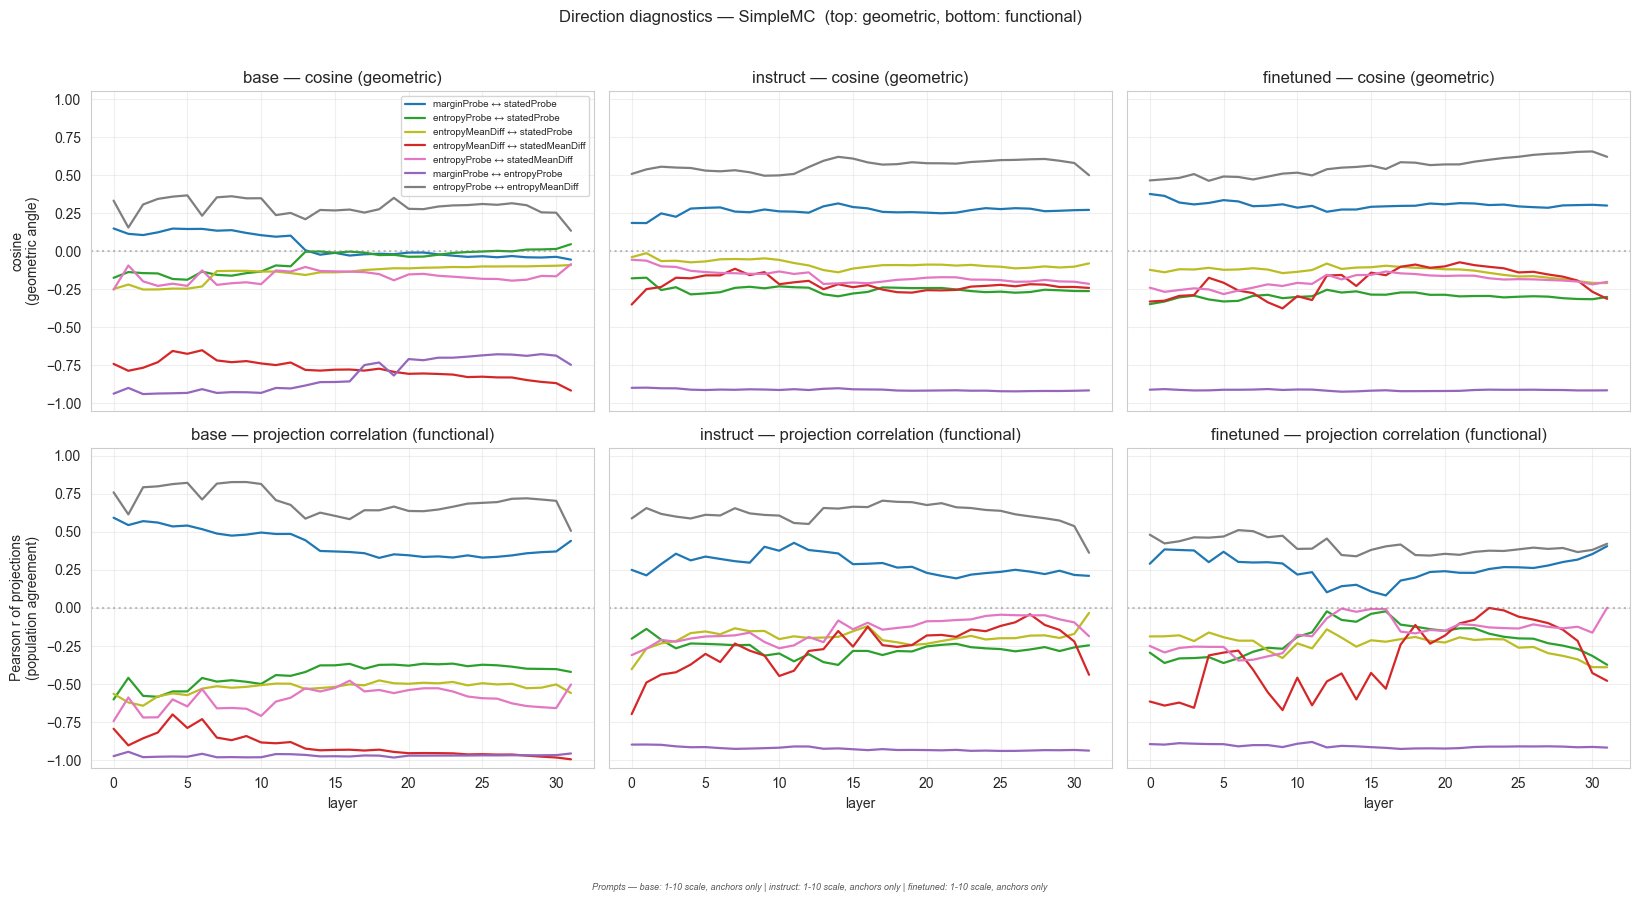

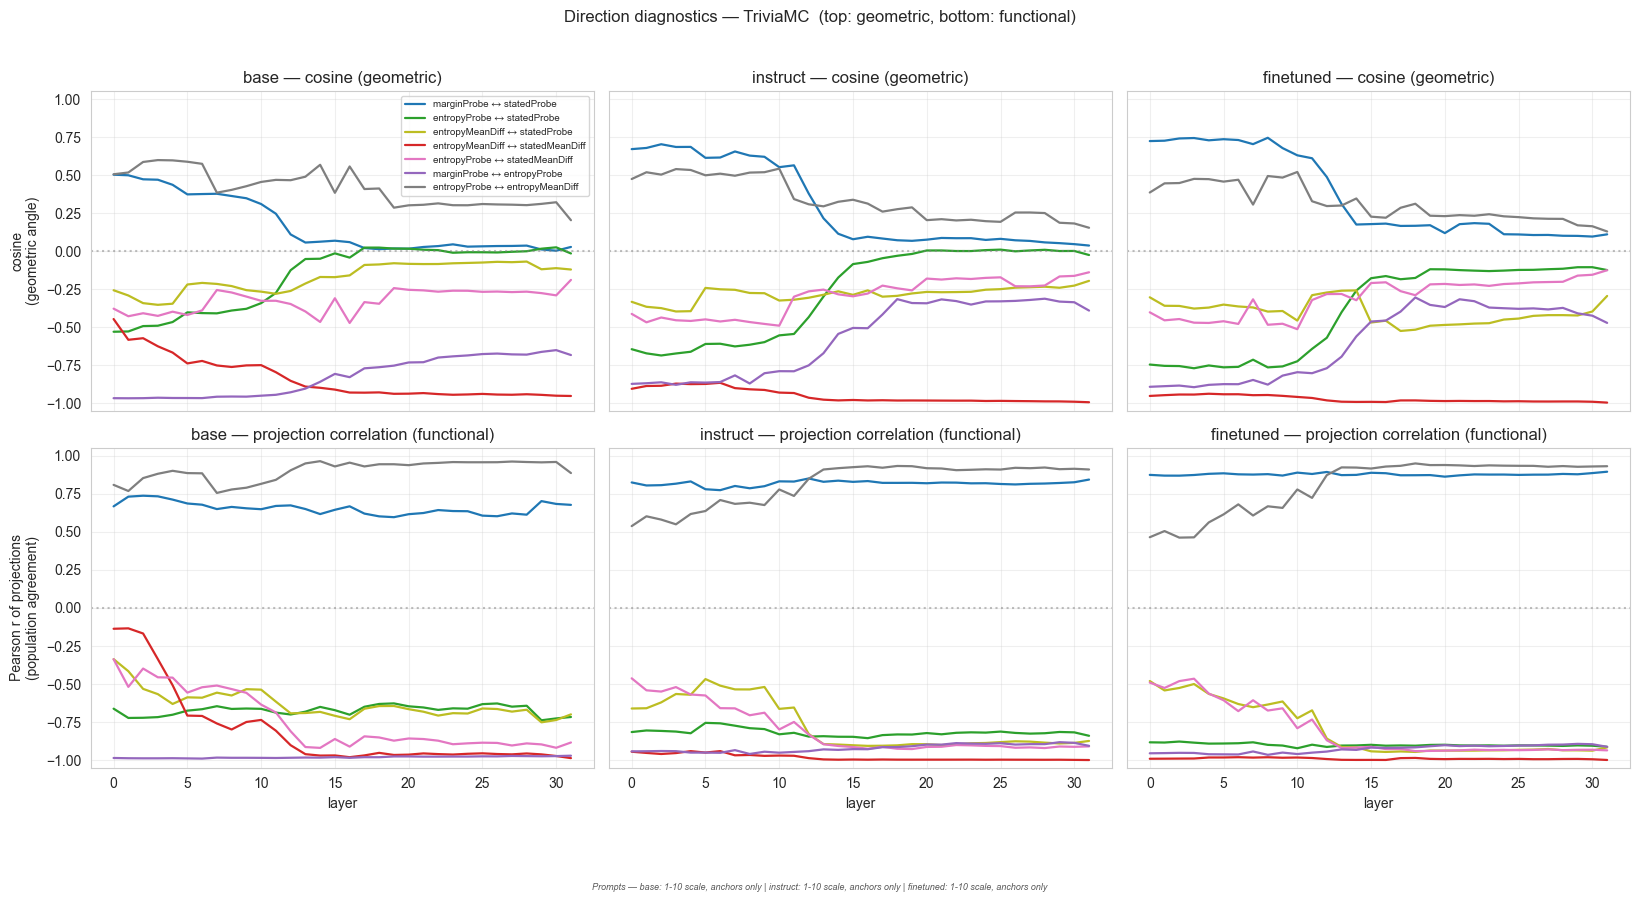


=== Section 4 summary — SimpleMC (values at each model's margin-peak layer) ===

COSINE (geometric):
    model  peak_layer  marginProbe ↔ statedProbe  entropyProbe ↔ statedProbe  entropyMeanDiff ↔ statedProbe  entropyMeanDiff ↔ statedMeanDiff  entropyProbe ↔ statedMeanDiff  marginProbe ↔ entropyProbe  entropyProbe ↔ entropyMeanDiff
     base          28                     -0.040                       0.011                         -0.100                            -0.847                         -0.187                      -0.687                           0.302
 instruct          25                      0.277                      -0.266                         -0.102                            -0.221                         -0.190                      -0.920                           0.599
finetuned          17                      0.298                      -0.271                         -0.103                            -0.102                         -0.145                      -0.92

In [24]:
# --- Section 4.2: Plot cosine + projection correlation for ALL datasets ---
# One figure per dataset; rows = cosine (top) / projcorr (bottom); columns = models.

ensure_probe_results()  # populate PROBE_RESULTS from cache if this cell is run standalone
PAIR_COLORS = {
    'marginProbe ↔ statedProbe':        'tab:blue',
    'entropyProbe ↔ statedProbe':       'tab:green',
    'entropyMeanDiff ↔ statedProbe':    'tab:olive',
    'entropyMeanDiff ↔ statedMeanDiff': 'tab:red',
    'entropyProbe ↔ statedMeanDiff':    'tab:pink',
    'marginProbe ↔ entropyProbe':       'tab:purple',
    'entropyProbe ↔ entropyMeanDiff':   'tab:gray',
}

for dataset in DATASETS:
    present_for_ds = [m for m in MODELS if (m, dataset) in DIRECTION_DIAGNOSTICS]
    if not present_for_ds: continue

    fig, axes = plt.subplots(
        2, len(present_for_ds),
        figsize=(5.5 * len(present_for_ds), 8),
        sharex=True, sharey='row',
    )
    axes = np.atleast_2d(axes)
    if len(present_for_ds) == 1: axes = axes.reshape(-1, 1)

    for mi, model in enumerate(present_for_ds):
        key = (model, dataset)
        d = DIRECTION_DIAGNOSTICS[key]
        layers = PROBE_RESULTS[key]['layers']

        ax = axes[0, mi]
        for name, _, _ in DIAGNOSTIC_PAIRS:
            ax.plot(layers, d[name]['cos'], color=PAIR_COLORS[name], label=name, linewidth=1.6)
        ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
        ax.set_title(f'{model} — cosine (geometric)')
        if mi == 0:
            ax.set_ylabel('cosine\n(geometric angle)')
            ax.legend(fontsize=7, loc='best')
        ax.set_ylim(-1.05, 1.05)
        ax.grid(True, alpha=0.3)

        ax = axes[1, mi]
        for name, _, _ in DIAGNOSTIC_PAIRS:
            ax.plot(layers, d[name]['projcorr'], color=PAIR_COLORS[name], label=name, linewidth=1.6)
        ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
        ax.set_title(f'{model} — projection correlation (functional)')
        if mi == 0:
            ax.set_ylabel('Pearson r of projections\n(population agreement)')
        ax.set_xlabel('layer')
        ax.set_ylim(-1.05, 1.05)
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'Direction diagnostics — {dataset}  (top: geometric, bottom: functional)', y=1.02)
    plt.tight_layout()
    save_fig(FIGURES_DIR / f's4_direction_diagnostics_{dataset}.pdf')
    plt.show()

# ---- Text summary at each model's margin-peak layer, for each dataset ----
for dataset in DATASETS:
    present_for_ds = [m for m in MODELS if (m, dataset) in DIRECTION_DIAGNOSTICS]
    if not present_for_ds: continue
    print(f'\n=== Section 4 summary — {dataset} (values at each model\'s margin-peak layer) ===')
    rows_cos, rows_pc, flags = [], [], []
    for model in present_for_ds:
        key = (model, dataset)
        d = DIRECTION_DIAGNOSTICS[key]
        pr = PROBE_RESULTS[key]
        peak_l = int(np.nanargmax(pr['within_r2_natural']['margin_logit']))
        cos_row = {'model': model, 'peak_layer': peak_l}
        pc_row  = {'model': model, 'peak_layer': peak_l}
        for name, _, _ in DIAGNOSTIC_PAIRS:
            c = float(d[name]['cos'][peak_l])
            p = float(d[name]['projcorr'][peak_l])
            cos_row[name] = round(c, 3)
            pc_row[name]  = round(p, 3)
            if abs(c) < 0.3 and abs(p) > 0.6:
                flags.append(f'{dataset} / {model}: {name} (|cos|={abs(c):.2f} vs |projcorr|={abs(p):.2f})')
        rows_cos.append(cos_row)
        rows_pc.append(pc_row)
    print('\nCOSINE (geometric):')
    print(pd.DataFrame(rows_cos).to_string(index=False))
    print('\nPROJECTION CORRELATION (functional):')
    print(pd.DataFrame(rows_pc).to_string(index=False))
    if flags:
        print('\n⚠ Geometric≠Functional mismatches (low cos, high projcorr):')
        for f in flags: print(f'  {f}')


## Section 4.3: Cross-prompt direction alignment (introspection proxy)

**Question:** is the confidence-prompt residual stream a readout of the MC-prompt's internal uncertainty, and does finetuning strengthen that alignment?

Section 4.2's `entropyMeanDiff ↔ statedMeanDiff` is an **intra-prompt** measure — both directions are built from `run.direct_acts` (the MC-question forward pass). The large negative cosine there reflects internal consistency within one forward pass (same samples: high entropy ⇔ will-state-low-confidence).

Here we compute a **cross-prompt** measure: entropy direction from `run.direct_acts` (MC prompt) vs stated-confidence direction from `run.meta_acts` (confidence prompt). The two directions live in different forward passes but share the same residual-stream basis. Sign-consistent introspection predicts a negative cosine; stronger `|cos|` in finetuned supports the hypothesis that finetuning aligns the reporting channel with internal uncertainty.

This matches the analysis in `confidence_contrast.py` but runs it for all three models instead of finetuned only.

**Caveats.** Geometric alignment is sufficient but not necessary for introspection — a nonlinear readout need not align directions. Stronger tests: (1) cross-prompt probe transfer (fit on `direct_acts → entropy`, apply to `meta_acts`, measure R² against `stated_confidence_numeric`); (2) principal-angle subspace alignment; (3) causal intervention along the entropy direction during the MC pass, measuring shift in stated confidence.

Pole counts per direction (high | low) — quartile cutoff via value percentile:
run                           n  entropy high|low  confidence high|low
base/SimpleMC         500      126 | 125           125 | 125     
base/TriviaMC         800      200 | 201           200 | 200     
finetuned/SimpleMC         500      125 | 125           125 | 125     
finetuned/TriviaMC         800      200 | 200           200 | 200     
instruct/SimpleMC         500      125 | 125           125 | 125     
instruct/TriviaMC         800      200 | 200           200 | 200     


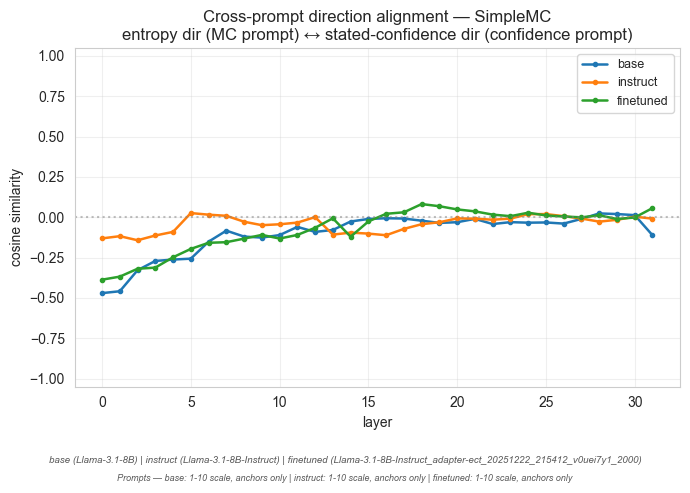

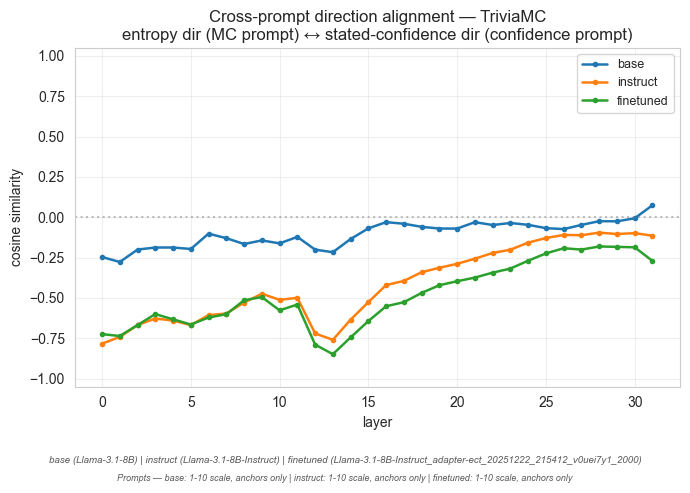


=== Section 4.3 summary — SimpleMC (at peak layer per model) ===

    model  peak_layer          peak_from  intra-prompt cos  cross-prompt cos
     base          28 margin_logit probe            -0.847             0.024
 instruct          25 margin_logit probe            -0.221             0.020
finetuned          17 margin_logit probe            -0.102             0.031

=== Section 4.3 summary — TriviaMC (at peak layer per model) ===

    model  peak_layer          peak_from  intra-prompt cos  cross-prompt cos
     base          30 margin_logit probe            -0.950            -0.006
 instruct          30 margin_logit probe            -0.989            -0.098
finetuned          30 margin_logit probe            -0.989            -0.186


In [25]:
# --- Section 4.3: Cross-prompt direction alignment (introspection proxy) ---
# entropy direction from run.direct_acts (MC-question prompt) vs
# stated-confidence direction from run.meta_acts (confidence prompt).
# SELF-CONTAINED: runnable after load_all_available() without running any
# earlier section. Uses raw activations + mean-diff; no sklearn probes.

def _mean_diff_direction(X: np.ndarray, target: np.ndarray, return_counts: bool = False):
    """Unit-normalized mean-diff direction: mean(top quartile) - mean(bottom quartile)
    of target values. X: (n, d); target: (n,). Returns (d,), or (d, n_high, n_low)
    if return_counts=True."""
    vals = np.asarray(target, dtype=float)
    valid = ~np.isnan(vals)
    X_v, vals_v = X[valid], vals[valid]
    if len(vals_v) < 20:
        zero = np.zeros(X.shape[1], dtype=np.float32)
        return (zero, 0, 0) if return_counts else zero
    q_low = np.quantile(vals_v, 0.25)
    q_high = np.quantile(vals_v, 0.75)
    high_mask = vals_v >= q_high
    low_mask  = vals_v <= q_low
    high = X_v[high_mask].mean(axis=0)
    low  = X_v[low_mask].mean(axis=0)
    d = (high - low).astype(np.float32)
    d = d / (np.linalg.norm(d) + 1e-9)
    if return_counts:
        return d, int(high_mask.sum()), int(low_mask.sum())
    return d


MODEL_COLORS = globals().get('MODEL_COLORS',
    {'base': 'tab:blue', 'instruct': 'tab:orange', 'finetuned': 'tab:green'})

CROSS_PROMPT_COSINE = {}
MODEL_DISPLAY_LABELS = {m: f"{m} ({MODELS[m]['model_short']})" for m in MODELS}

POLE_COUNTS = {}  # (model, dataset) -> {'entropy': (n_high, n_low), 'confidence': (n_high, n_low)}
for key, run in RUNS.items():
    n_layers = run.n_layers
    cosines = np.full(n_layers, np.nan, dtype=np.float32)
    y_ent  = run.df['entropy'].values
    y_conf = run.df['stated_confidence_numeric'].values
    # Pole counts depend only on targets, not on layer — compute once.
    _, ent_hi, ent_lo  = _mean_diff_direction(run.direct_acts[:, 0, :].astype(np.float32), y_ent, return_counts=True)
    _, conf_hi, conf_lo = _mean_diff_direction(run.meta_acts[:, 0, :].astype(np.float32),   y_conf, return_counts=True)
    POLE_COUNTS[key] = {'entropy': (ent_hi, ent_lo), 'confidence': (conf_hi, conf_lo)}
    for layer in range(n_layers):
        d_ent  = _mean_diff_direction(run.direct_acts[:, layer, :].astype(np.float32), y_ent)
        d_conf = _mean_diff_direction(run.meta_acts[:,   layer, :].astype(np.float32), y_conf)
        if np.any(d_ent) and np.any(d_conf):
            cosines[layer] = float(d_ent @ d_conf)
    CROSS_PROMPT_COSINE[key] = cosines

# Print pole counts per (model, dataset) for diagnostic transparency.
print('Pole counts per direction (high | low) — quartile cutoff via value percentile:')
print(f"{'run':25s}  {'n':>4s}  {'entropy high|low':>16s}  {'confidence high|low':>19s}")
for (model, dataset) in sorted(POLE_COUNTS):
    n = RUNS[(model, dataset)].n_examples
    eh, el = POLE_COUNTS[(model, dataset)]['entropy']
    ch, cl = POLE_COUNTS[(model, dataset)]['confidence']
    print(f'{model}/{dataset:14s}  {n:>4d}  {eh:>7d} | {el:<6d}  {ch:>9d} | {cl:<8d}')

for dataset in DATASETS:
    present = [m for m in MODELS if (m, dataset) in CROSS_PROMPT_COSINE]
    if not present:
        continue
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for model in present:
        cos = CROSS_PROMPT_COSINE[(model, dataset)]
        layers = list(range(RUNS[(model, dataset)].n_layers))
        ax.plot(layers, cos, color=MODEL_COLORS.get(model, 'gray'), label=model,
                linewidth=1.8, marker='o', markersize=3)
    ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('layer')
    ax.set_ylabel('cosine similarity')
    ax.set_ylim(-1.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='best')
    ax.set_title(f'Cross-prompt direction alignment — {dataset}\n'
                 f'entropy dir (MC prompt) ↔ stated-confidence dir (confidence prompt)')
    footer = ' | '.join(MODEL_DISPLAY_LABELS[m] for m in present)
    fig.text(0.5, -0.04, footer, ha='center', fontsize=7, style='italic', color='0.35')
    plt.tight_layout()
    save_fig(FIGURES_DIR / f's4_cross_prompt_alignment_{dataset}.pdf')
    plt.show()

# --- Summary table (uses probes if already cached in memory; otherwise peak |cos|) ---
_has_probes = 'PROBE_RESULTS' in globals() and all(k in PROBE_RESULTS for k in RUNS)
_has_diags  = 'DIRECTION_DIAGNOSTICS' in globals() and all(k in DIRECTION_DIAGNOSTICS for k in RUNS)

for dataset in DATASETS:
    present = [m for m in MODELS if (m, dataset) in CROSS_PROMPT_COSINE]
    if not present:
        continue
    rows = []
    for model in present:
        key = (model, dataset)
        cos_arr = CROSS_PROMPT_COSINE[key]
        if _has_probes:
            peak_l = int(np.nanargmax(PROBE_RESULTS[key]['within_r2_natural']['margin_logit']))
            peak_src = 'margin_logit probe'
        else:
            peak_l = int(np.nanargmax(np.abs(cos_arr)))
            peak_src = 'peak |cross-cos|'
        intra = (float(DIRECTION_DIAGNOSTICS[key]['entropyMeanDiff ↔ statedMeanDiff']['cos'][peak_l])
                 if _has_diags else float('nan'))
        rows.append({
            'model': model,
            'peak_layer': peak_l,
            'peak_from': peak_src,
            'intra-prompt cos': round(intra, 3) if not np.isnan(intra) else '—',
            'cross-prompt cos': round(float(cos_arr[peak_l]), 3),
        })
    print(f"\n=== Section 4.3 summary — {dataset} (at peak layer per model) ===\n")
    print(pd.DataFrame(rows).to_string(index=False))


### Section 4.3b: Cross-model direction cosine heatmaps (layers 11–17)

For each direction type — `marginProbe`, `entropyProbe`, `statedProbe`, `entropyMeanDiff`, `statedMeanDiff` — compute the pairwise cosine similarity between base / instruct / finetuned at each layer in 11–17. These are the layers where the probes start being well-fit (see `s2_layer_r2_curves.pdf`), so the directions should be informative and the cosine comparisons meaningful.

Llama-3.1-8B / Instruct / finetuned share a residual-stream basis (finetuning re-uses the pretrained d_model axes), so cosine across models is meaningful.

**Layout per dataset:** rows = direction type, columns = layer. Each cell is an (n_models × n_models) heatmap, cells annotated with cosine value. +1 = identical direction, 0 = orthogonal, −1 = flipped sign but same axis.

**What to look for:**
- Moving across columns within a row tells you whether the direction stabilizes or rotates as depth increases.
- Within a heatmap, the base↔instruct cell tells you how much pretraining → instruction-tuning rotated the axis; instruct↔finetuned tells you how much the adapter rotated it further.
- If `statedProbe` cosine is low in the base row/column but high between instruct and finetuned, that’s evidence the stated-confidence reporting axis was installed during instruction tuning and preserved through finetuning.

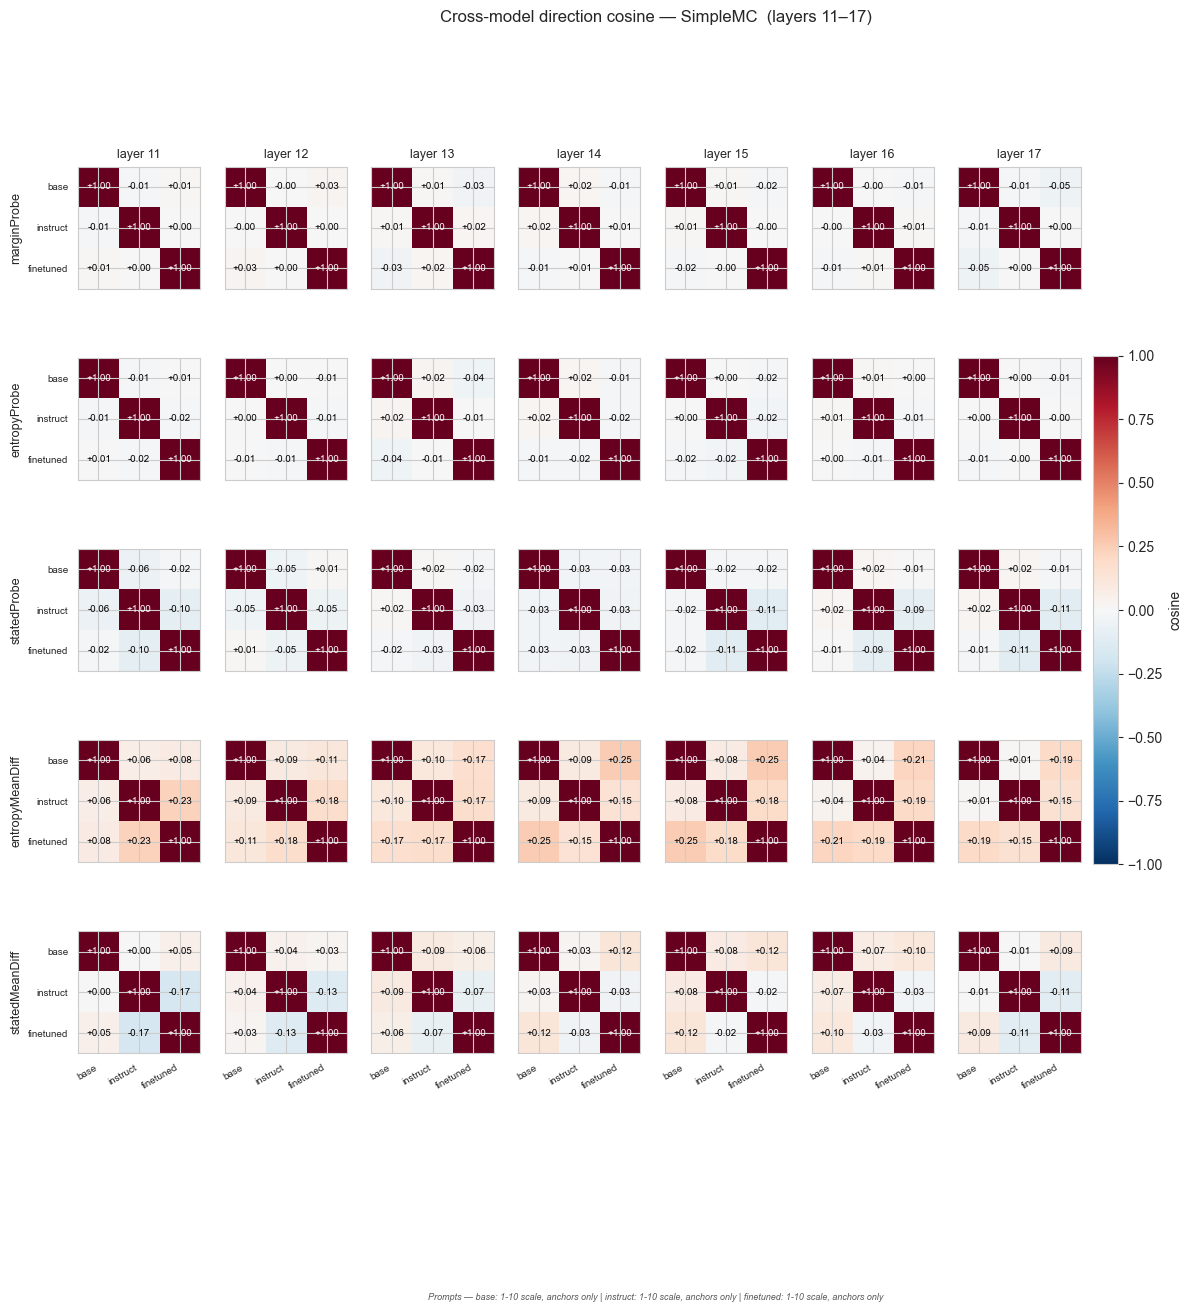

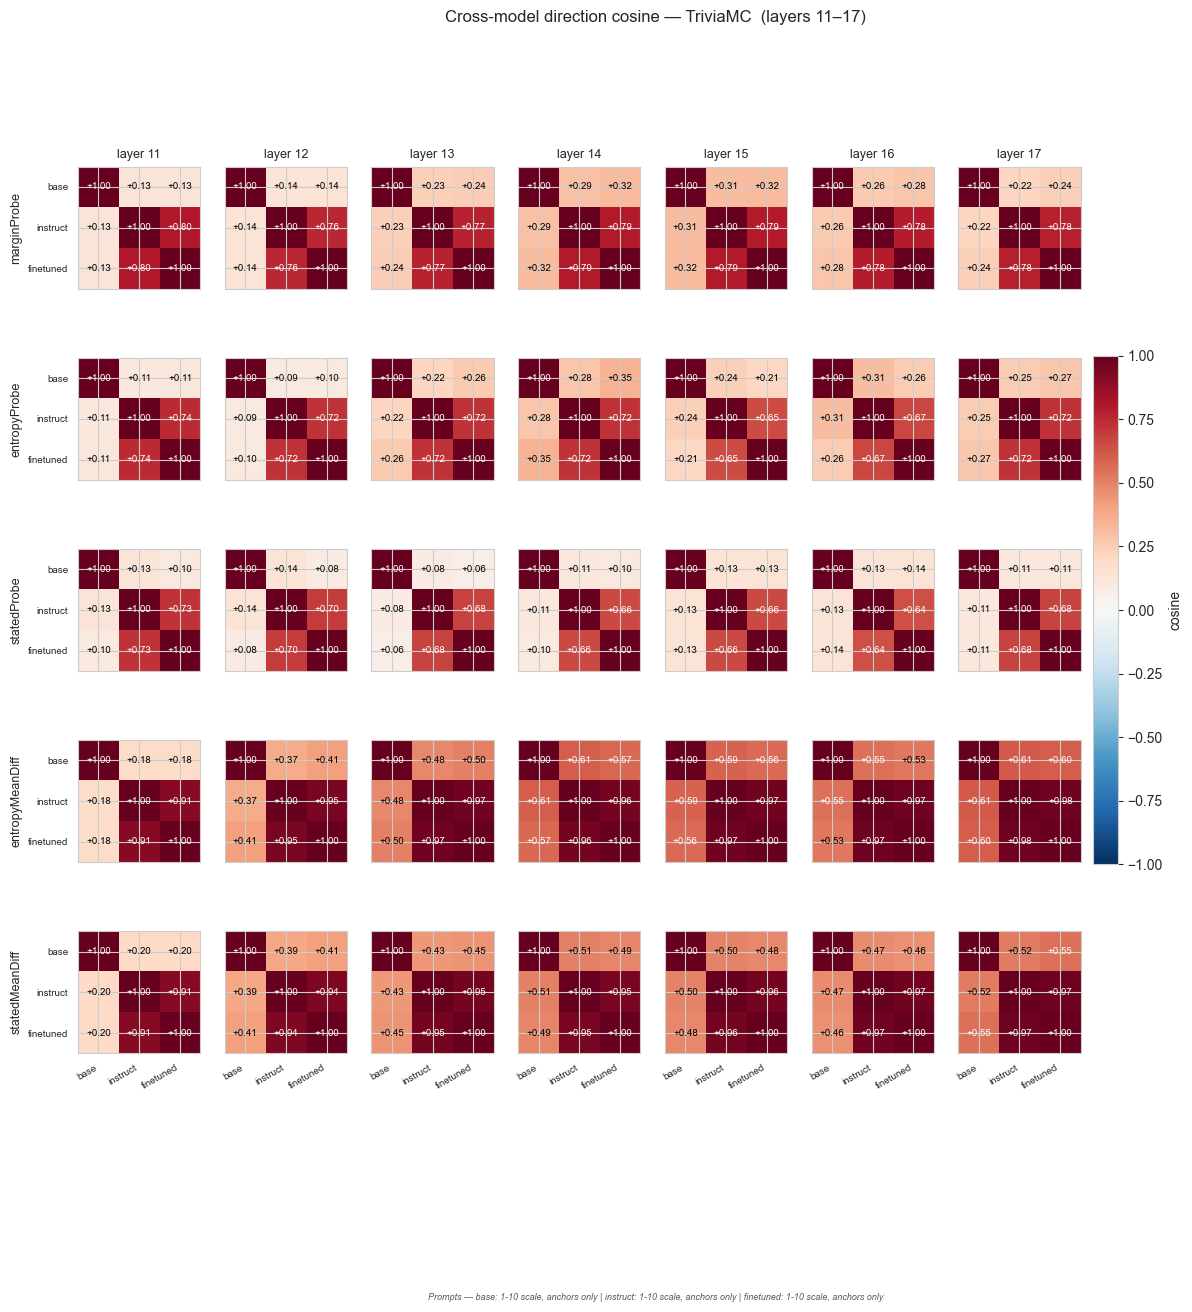

In [26]:
# --- Section 4.3b: Cross-model direction cosine heatmaps across layers 11-17 ---
# One figure per dataset. Rows = direction type; columns = layer.
# Each cell is an (n_models x n_models) cosine-similarity heatmap.
# Reuses _mean_diff_direction() from Section 4.1 and PROBE_RESULTS.

ensure_probe_results()

CROSS_MODEL_LAYERS = [11, 12, 13, 14, 15, 16, 17]

MODELS_ORDER = [m for m in MODELS if any((m, d) in PROBE_RESULTS for d in DATASETS)]

DIRECTION_SOURCES = [
    ('marginProbe',     'probe',     'margin_logit'),
    ('entropyProbe',    'probe',     'entropy'),
    ('statedProbe',     'probe',     'stated_confidence'),
    ('entropyMeanDiff', 'mean_diff', 'entropy'),
    ('statedMeanDiff',  'mean_diff', 'stated_confidence'),
]


def _unit(v):
    v = v.astype(np.float32)
    n = np.linalg.norm(v)
    return v / n if n > 1e-9 else v


def _get_direction(model, dataset, method, target, layer):
    key = (model, dataset)
    if key not in PROBE_RESULTS:
        return None
    pr = PROBE_RESULTS[key]
    run = RUNS[key]
    if method == 'probe':
        w = pr['probe_weights'].get(target)
        if w is None or layer >= len(w):
            return None
        return _unit(w[layer])
    if method == 'mean_diff':
        if target == 'entropy':
            md = pr['mean_diff_direction']
            if layer >= len(md):
                return None
            return _unit(md[layer])
        if target == 'stated_confidence':
            X = run.direct_acts[:, layer, :].astype(np.float32)
            y = run.df['stated_confidence_numeric'].values
            return _unit(_mean_diff_direction(X, y))
    return None


for dataset in DATASETS:
    n_rows = len(DIRECTION_SOURCES)
    n_cols = len(CROSS_MODEL_LAYERS)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.2 * n_cols, 2.4 * n_rows))
    axes = np.atleast_2d(axes)
    last_im = None
    for i, (dir_name, method, target) in enumerate(DIRECTION_SOURCES):
        for j, layer in enumerate(CROSS_MODEL_LAYERS):
            ax = axes[i, j]
            dirs = {m: _get_direction(m, dataset, method, target, layer) for m in MODELS_ORDER}
            present = [m for m in MODELS_ORDER if dirs.get(m) is not None]
            n = len(present)
            if n < 2:
                ax.axis('off')
                continue
            M = np.ones((n, n), dtype=np.float32)
            for a, ma in enumerate(present):
                for b, mb in enumerate(present):
                    M[a, b] = float(dirs[ma] @ dirs[mb])
            last_im = ax.imshow(M, vmin=-1, vmax=1, cmap='RdBu_r')
            ax.set_xticks(range(n))
            ax.set_yticks(range(n))
            if i == n_rows - 1:
                ax.set_xticklabels(present, rotation=30, ha='right', fontsize=7)
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_yticklabels(present, fontsize=7)
                ax.set_ylabel(dir_name, fontsize=9)
            else:
                ax.set_yticklabels([])
            if i == 0:
                ax.set_title(f'layer {layer}', fontsize=9)
            for a in range(n):
                for b in range(n):
                    val = M[a, b]
                    ax.text(b, a, f'{val:+.2f}', ha='center', va='center', fontsize=7,
                            color='white' if abs(val) > 0.55 else 'black')
    if last_im is not None:
        fig.colorbar(last_im, ax=list(axes.ravel()), shrink=0.55, label='cosine', pad=0.01)
    fig.suptitle(f'Cross-model direction cosine \u2014 {dataset}  (layers {CROSS_MODEL_LAYERS[0]}\u2013{CROSS_MODEL_LAYERS[-1]})', y=0.995)
    save_fig(FIGURES_DIR / f's4_3b_cross_model_cosine_{dataset}.pdf')
    plt.show()


### Section 4.3c: Rotation vs. magnitude decomposition of cross-model direction change

Section 4.3b shows cross-model **cosine** — how much the direction rotated. Cosine is insensitive to scale, so a direction that's barely rotated but twice as "strong" looks identical to one that's barely rotated and unchanged. Here we split the cross-model change along two axes:

**1. Rotation.** `cos(d_A, d_B)` between the *unit*-normalized mean-diff directions from models A and B. Same quantity as 4.3b, repeated here so rotation and magnitude sit side-by-side.

**2. Magnitude.** `||mean(high-quartile activations) − mean(low-quartile activations)||` in the raw residual-stream basis, per (model, layer, direction). This is how far apart the two target extremes actually sit along the axis — a direct readout of how sharply the model separates confident from unconfident examples along this direction. Larger ≈ more distinguishable classes ≈ a stronger readout.

### The "sharpening" panels, and why *vs. base*

Raw magnitude is hard to compare across models on its own, because residual-stream activations themselves inflate or contract during training (LayerNorm γ shifts, changes to attention-output gating, etc.). A magnitude that doubled while *every* activation vector also doubled in length is not evidence of sharpening — everything moved by the same factor.

To isolate "this direction got stronger" from "the whole residual stream got stronger," we normalize:

\[\text{sep}(M, L) = \frac{\|\text{mean}_M(\text{high}) - \text{mean}_M(\text{low})\|}{\mathbb{E}[\|x_M\|]}\]

where the denominator is the average ℓ₂ norm of residual-stream activations at that (model, layer). A ratio `sep(M) / sep(base)` above 1 means the class-separation grew *faster* than overall activation scale between base and M — genuine sharpening along the axis rather than an across-the-board amplification.

**Why base as the reference?** It's an arbitrary denominator choice — base is just the anchor that most cleanly answers "what happened *over training*?" If the question is instead "what did *confidence-finetuning specifically* add on top of instruction tuning?" the right denominator is instruct, not base. We therefore plot **two** sharpening panels per row: `model / base` (total-pipeline effect) and `model / instruct` (finetuning-only effect). Reading the two together:

- `finetuned/base ≈ 1` and `finetuned/instruct ≈ 1`: no sharpening happened.
- `finetuned/base > 1` but `finetuned/instruct ≈ 1`: instruction tuning did the sharpening; confidence-finetuning added little on top.
- `finetuned/base > 1` and `finetuned/instruct > 1`: confidence-finetuning specifically sharpened the axis further.
- `finetuned/base > 1` but `finetuned/instruct < 1`: finetuning actually *blunted* a signal instruction-tuning had built up.

### Pole-symmetry check

`||mean(high) − mean(low)||` collapses both class means into one scalar. But training can move the two poles **asymmetrically** — e.g. push confident examples further out along the axis while leaving unconfident ones near the population mean. That would be mechanistically distinct from "both clusters spread apart symmetrically." We check this by plotting `||mean(high) − mean(all)||` and `||mean(low) − mean(all)||` separately per layer: each pole's displacement from the overall class centroid. Equal curves = symmetric separation; divergent curves = one-sided sharpening.

### Mapping back to H1 / H2

- Near-unit cosine + substantial magnitude scale-up (normalized) → **sharpening of an existing readout**. Supports H1 far more strongly than the cosine-only view suggests.
- Rotation only, no magnitude gain → axis genuinely changed, but no sharpening occurred. Weaker signal either way.
- Large cosine change *and* large magnitude change → training both moved and amplified the direction. Consistent with H2.

Magnitudes are comparable across models because base / instruct / finetuned share the residual-stream basis (no re-initialization during finetuning).

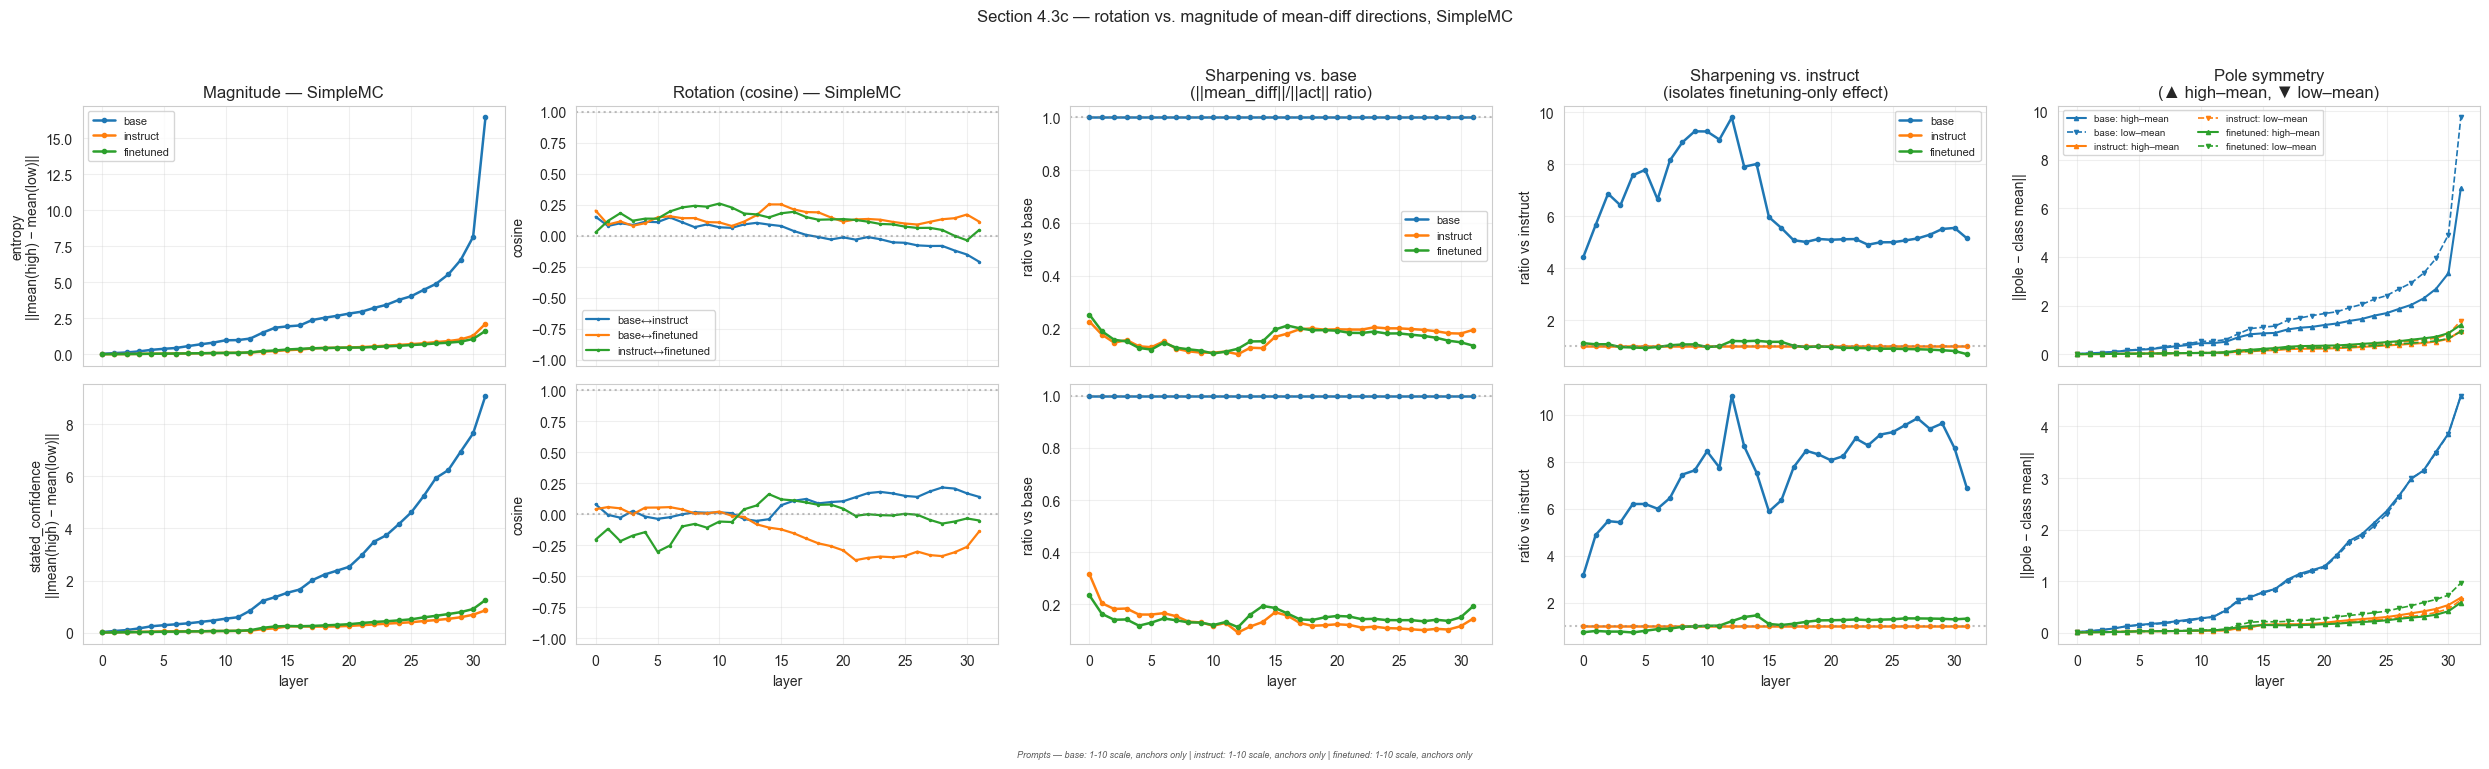

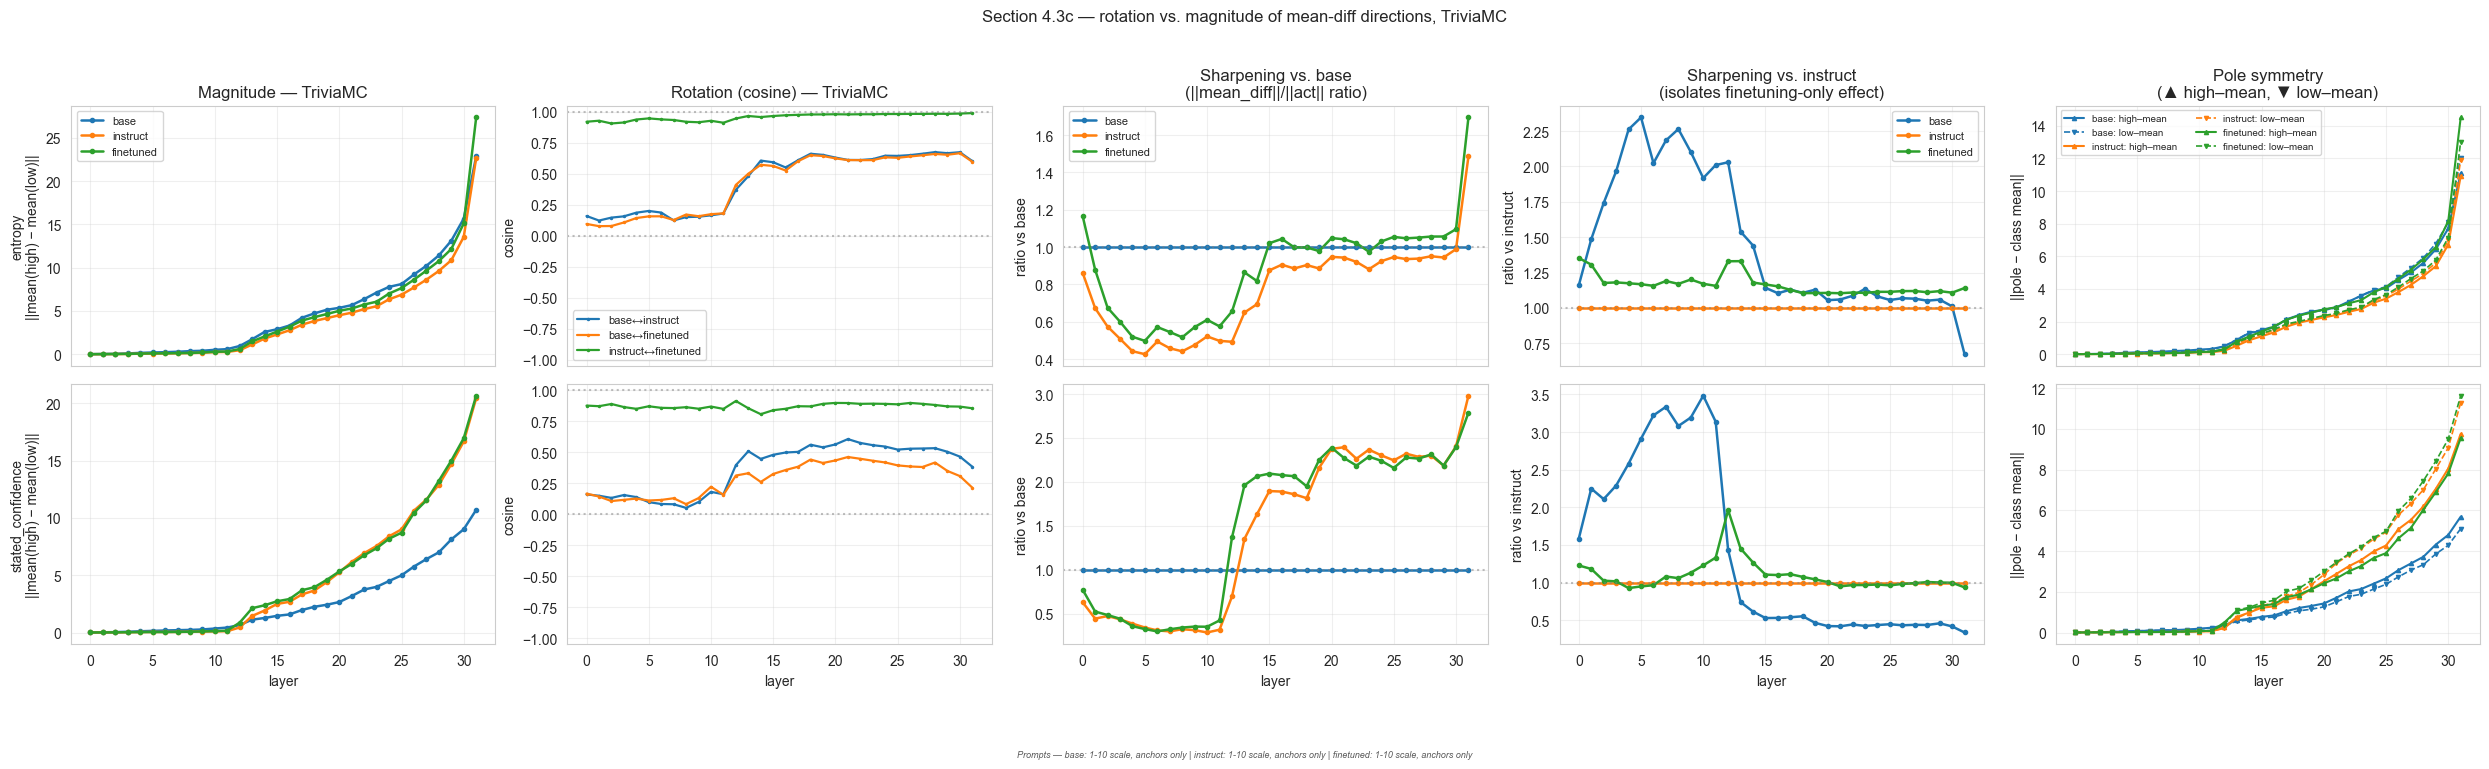


=== Section 4.3c summary: rotation, magnitude, and pole symmetry at base's peak layer ===
 dataset         direction  peak_layer  cos(base,instruct)  instruct/base  instruct/instruct  instruct hi/lo pole  cos(base,finetuned)  finetuned/base  finetuned/instruct  finetuned hi/lo pole
SimpleMC           entropy          31              -0.210          0.194                1.0                0.696                  NaN             NaN                 NaN                   NaN
SimpleMC           entropy          31                 NaN            NaN                NaN                  NaN                0.114           0.135               0.692                 1.299
SimpleMC stated_confidence          31               0.139          0.146                1.0                1.078                  NaN             NaN                 NaN                   NaN
SimpleMC stated_confidence          31                 NaN            NaN                NaN                  NaN               -0.138   

In [27]:
# --- Section 4.3c: Per-layer rotation and magnitude of the entropy / stated-confidence directions ---
# Uses the same unit-mean-diff idea as 4.3, but ALSO returns the pre-normalization norm
# (class-separation in raw residual-stream space) and the per-pole displacement from the
# overall class centroid, so we can check whether training moves both poles symmetrically.

DIRECTION_SPECS = [
    # (label, acts_attr, target_col)
    ('entropy',           'direct_acts', 'entropy'),
    ('stated_confidence', 'meta_acts',   'stated_confidence_numeric'),
]


def _mean_diff_decomposition(X: np.ndarray, target: np.ndarray):
    """Return dict with:
      unit        : unit-normalized (high - low) direction  (d,)
      magnitude   : ||mean(high) - mean(low)||              float
      high_disp   : ||mean(high) - mean(all_valid)||         float
      low_disp    : ||mean(low)  - mean(all_valid)||         float
    """
    vals = np.asarray(target, dtype=float)
    valid = ~np.isnan(vals)
    X_v, vals_v = X[valid], vals[valid]
    zeros = {'unit': np.zeros(X.shape[1], dtype=np.float32),
             'magnitude': 0.0, 'high_disp': 0.0, 'low_disp': 0.0}
    if len(vals_v) < 20:
        return zeros
    q_low  = np.quantile(vals_v, 0.25)
    q_high = np.quantile(vals_v, 0.75)
    mu_all  = X_v.mean(axis=0)
    mu_high = X_v[vals_v >= q_high].mean(axis=0)
    mu_low  = X_v[vals_v <= q_low ].mean(axis=0)
    d_raw = (mu_high - mu_low).astype(np.float32)
    raw_norm = float(np.linalg.norm(d_raw))
    if raw_norm < 1e-9:
        return zeros
    return {
        'unit':      (d_raw / raw_norm).astype(np.float32),
        'magnitude': raw_norm,
        'high_disp': float(np.linalg.norm(mu_high - mu_all)),
        'low_disp':  float(np.linalg.norm(mu_low  - mu_all)),
    }


# DECOMP[(model, dataset, direction)] = {
#     'unit' (L,d), 'magnitude' (L,), 'act_norm' (L,), 'high_disp' (L,), 'low_disp' (L,)
# }
DECOMP = {}
for (model, dataset), run in RUNS.items():
    n_layers = run.n_layers
    d_model = run.direct_acts.shape[-1]
    for label, acts_attr, col in DIRECTION_SPECS:
        if col not in run.df.columns:
            continue
        acts = getattr(run, acts_attr)
        y = np.asarray(run.df[col].values, dtype=float)
        unit     = np.zeros((n_layers, d_model), dtype=np.float32)
        mag      = np.full(n_layers, np.nan, dtype=np.float32)
        anorm    = np.full(n_layers, np.nan, dtype=np.float32)
        hi_disp  = np.full(n_layers, np.nan, dtype=np.float32)
        lo_disp  = np.full(n_layers, np.nan, dtype=np.float32)
        for layer in range(n_layers):
            X = acts[:, layer, :].astype(np.float32)
            dec = _mean_diff_decomposition(X, y)
            unit[layer]    = dec['unit']
            mag[layer]     = dec['magnitude']
            hi_disp[layer] = dec['high_disp']
            lo_disp[layer] = dec['low_disp']
            anorm[layer]   = float(np.linalg.norm(X, axis=1).mean())
        DECOMP[(model, dataset, label)] = {
            'unit': unit, 'magnitude': mag, 'act_norm': anorm,
            'high_disp': hi_disp, 'low_disp': lo_disp,
        }


present_models_local = [m for m in MODELS if any((m, ds) in RUNS for ds in DATASETS)]
PAIRS = [(a, b) for i, a in enumerate(present_models_local) for b in present_models_local[i+1:]]


def _normed_sep(key):
    """(||mean_diff|| / ||act||) per layer, or None if key missing."""
    if key not in DECOMP: return None
    d = DECOMP[key]
    return d['magnitude'] / (d['act_norm'] + 1e-9)


for dataset in DATASETS:
    have = [m for m in present_models_local if (m, dataset) in RUNS]
    if len(have) < 2:
        continue
    n_rows = len(DIRECTION_SPECS)
    # Columns: 1) magnitude, 2) rotation, 3) sharpening vs base, 4) sharpening vs instruct, 5) pole symmetry
    n_cols = 5
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.4 * n_rows), sharex=True)
    axes = np.atleast_2d(axes)
    for ri, (label, _, _) in enumerate(DIRECTION_SPECS):
        ax_mag, ax_rot, ax_sharp_base, ax_sharp_inst, ax_pole = axes[ri]
        layers_axis = None

        # col 1: raw magnitude per model
        for m in have:
            key = (m, dataset, label)
            if key not in DECOMP: continue
            mag = DECOMP[key]['magnitude']
            layers_axis = np.arange(len(mag))
            ax_mag.plot(layers_axis, mag, color=MODEL_COLORS.get(m, 'gray'),
                        label=m, linewidth=1.8, marker='o', markersize=3)
        ax_mag.set_ylabel(f'{label}\n||mean(high) − mean(low)||')
        if ri == 0: ax_mag.set_title(f'Magnitude — {dataset}')
        ax_mag.grid(True, alpha=0.3)
        if ri == n_rows - 1: ax_mag.set_xlabel('layer')
        if ri == 0: ax_mag.legend(fontsize=8, loc='best')

        # col 2: pairwise rotation (cosine) between models' unit directions
        for (a, b) in PAIRS:
            kA = (a, dataset, label); kB = (b, dataset, label)
            if kA not in DECOMP or kB not in DECOMP: continue
            uA = DECOMP[kA]['unit']; uB = DECOMP[kB]['unit']
            cos = np.einsum('ld,ld->l', uA, uB)
            ax_rot.plot(np.arange(len(cos)), cos, label=f'{a}↔{b}',
                        linewidth=1.6, marker='.', markersize=3)
        ax_rot.set_ylim(-1.05, 1.05)
        ax_rot.axhline(1.0, color='gray', linestyle=':', alpha=0.5)
        ax_rot.axhline(0.0, color='gray', linestyle=':', alpha=0.5)
        if ri == 0: ax_rot.set_title(f'Rotation (cosine) — {dataset}')
        ax_rot.set_ylabel('cosine')
        ax_rot.grid(True, alpha=0.3)
        if ri == n_rows - 1: ax_rot.set_xlabel('layer')
        if ri == 0: ax_rot.legend(fontsize=8, loc='best')

        # col 3: sharpening vs. base  =  sep(model) / sep(base)
        base_sep = _normed_sep(('base', dataset, label))
        if base_sep is not None:
            for m in have:
                m_sep = _normed_sep((m, dataset, label))
                if m_sep is None: continue
                ratio = m_sep / (base_sep + 1e-9)
                ax_sharp_base.plot(np.arange(len(ratio)), ratio,
                                   color=MODEL_COLORS.get(m, 'gray'),
                                   label=m, linewidth=1.8, marker='o', markersize=3)
            ax_sharp_base.axhline(1.0, color='gray', linestyle=':', alpha=0.5)
        if ri == 0: ax_sharp_base.set_title('Sharpening vs. base\n(||mean_diff||/||act|| ratio)')
        ax_sharp_base.set_ylabel('ratio vs base')
        ax_sharp_base.grid(True, alpha=0.3)
        if ri == n_rows - 1: ax_sharp_base.set_xlabel('layer')
        if ri == 0: ax_sharp_base.legend(fontsize=8, loc='best')

        # col 4: sharpening vs. instruct  =  sep(model) / sep(instruct)
        inst_sep = _normed_sep(('instruct', dataset, label))
        if inst_sep is not None:
            for m in have:
                m_sep = _normed_sep((m, dataset, label))
                if m_sep is None: continue
                ratio = m_sep / (inst_sep + 1e-9)
                ax_sharp_inst.plot(np.arange(len(ratio)), ratio,
                                   color=MODEL_COLORS.get(m, 'gray'),
                                   label=m, linewidth=1.8, marker='o', markersize=3)
            ax_sharp_inst.axhline(1.0, color='gray', linestyle=':', alpha=0.5)
        if ri == 0: ax_sharp_inst.set_title('Sharpening vs. instruct\n(isolates finetuning-only effect)')
        ax_sharp_inst.set_ylabel('ratio vs instruct')
        ax_sharp_inst.grid(True, alpha=0.3)
        if ri == n_rows - 1: ax_sharp_inst.set_xlabel('layer')
        if ri == 0: ax_sharp_inst.legend(fontsize=8, loc='best')

        # col 5: pole-symmetry check -- displacement of each pole from the class centroid
        for m in have:
            key = (m, dataset, label)
            if key not in DECOMP: continue
            hi = DECOMP[key]['high_disp']
            lo = DECOMP[key]['low_disp']
            layers = np.arange(len(hi))
            color = MODEL_COLORS.get(m, 'gray')
            ax_pole.plot(layers, hi, color=color, linestyle='-', linewidth=1.5,
                         marker='^', markersize=3, label=f'{m}: high–mean')
            ax_pole.plot(layers, lo, color=color, linestyle='--', linewidth=1.2,
                         marker='v', markersize=3, label=f'{m}: low–mean')
        if ri == 0: ax_pole.set_title('Pole symmetry\n(▲ high–mean, ▼ low–mean)')
        ax_pole.set_ylabel('||pole − class mean||')
        ax_pole.grid(True, alpha=0.3)
        if ri == n_rows - 1: ax_pole.set_xlabel('layer')
        if ri == 0: ax_pole.legend(fontsize=7, loc='best', ncol=2)

    plt.suptitle(f'Section 4.3c — rotation vs. magnitude of mean-diff directions, {dataset}', y=1.02)
    plt.tight_layout()
    save_fig(FIGURES_DIR / f's4_3c_rotation_vs_magnitude_{dataset}.pdf')
    plt.show()

# Compact summary at base's peak-magnitude layer: cos(base, model) and both sharpening ratios,
# plus the high/low pole-displacement ratio to flag asymmetric movement.
print('\n=== Section 4.3c summary: rotation, magnitude, and pole symmetry at base\'s peak layer ===')
rows = []
for dataset in DATASETS:
    for label, _, _ in DIRECTION_SPECS:
        if ('base', dataset, label) not in DECOMP: continue
        base = DECOMP[('base', dataset, label)]
        if np.all(np.isnan(base['magnitude'])): continue
        peak_l = int(np.nanargmax(base['magnitude']))
        base_sep = base['magnitude'][peak_l] / (base['act_norm'][peak_l] + 1e-9)
        inst_key = ('instruct', dataset, label)
        inst_sep = (DECOMP[inst_key]['magnitude'][peak_l] / (DECOMP[inst_key]['act_norm'][peak_l] + 1e-9)
                    if inst_key in DECOMP else np.nan)
        for m in ('instruct', 'finetuned'):
            key = (m, dataset, label)
            if key not in DECOMP: continue
            m_sep = DECOMP[key]['magnitude'][peak_l] / (DECOMP[key]['act_norm'][peak_l] + 1e-9)
            hi = DECOMP[key]['high_disp'][peak_l]
            lo = DECOMP[key]['low_disp'][peak_l]
            rows.append({
                'dataset': dataset, 'direction': label, 'peak_layer': peak_l,
                f'cos(base,{m})': round(float(base['unit'][peak_l] @ DECOMP[key]['unit'][peak_l]), 3),
                f'{m}/base': round(float(m_sep / (base_sep + 1e-9)), 3),
                f'{m}/instruct': (round(float(m_sep / (inst_sep + 1e-9)), 3)
                                  if inst_sep and not np.isnan(inst_sep) else np.nan),
                f'{m} hi/lo pole': round(float(hi / (lo + 1e-9)), 3),
            })
if rows:
    print(pd.DataFrame(rows).to_string(index=False))


## Section 4.4: Cross-prompt probe transfer (introspection readout test)

**What we're doing, in plain terms.** We want to know whether the "uncertainty signal" the model computes while answering an MC question also shows up in its residual stream while it is reporting its own confidence. We do this in two steps:

1. **Train a probe on MC-prompt activations to predict entropy.** For each layer, we fit a ridge regression whose input is `run.direct_acts` (the residual stream at the final token of the MC-question prompt) and whose target is the MC-answer entropy for that example. The probe has effectively learned "what does uncertainty look like, geometrically, in the residual stream when the model is in the middle of answering?" We verify on a held-out split that the probe actually works — that's the top panel (sanity check).

2. **Apply that same probe, unchanged, to confidence-prompt activations.** The probe's weights were fit to MC-prompt activations, but we now hand it `run.meta_acts` — residuals from a completely different forward pass, where the model is reporting its confidence rather than answering. The probe outputs a number for each example. We correlate that number with what the model actually stated for confidence (`stated_confidence_numeric`). That correlation is the bottom panel.

**Why this is a test of introspection.** If the "I'm uncertain" axis the model uses while answering is the same axis it consults when reporting confidence, then a probe trained in the MC context will still produce meaningful numbers when fed confidence-context activations — and those numbers should predict what the model goes on to say. Because entropy goes *up* when the model is uncertain and stated confidence goes *down*, the expected sign is **negative**. The more negative the correlation, the more the two prompts share a common uncertainty representation — which is what "introspection" looks like at the geometric level. A near-zero correlation would mean the MC-prompt's uncertainty axis is unrelated to whatever drives the confidence prompt's output, i.e. the model is *not* reading out its own MC-time uncertainty when it talks about confidence.

**How this differs from Section 4.3.** Section 4.3 computed one mean-diff direction per side and took the cosine of those two directions — a single-number-per-layer 1D comparison. Here we use a ridge probe with PCA-100, so it can exploit up to 100 dimensions of the activation subspace. It will pick up alignment that a 1D direction can miss. If 4.4 shows a much stronger effect than 4.3, it tells you the shared uncertainty information lives in a subspace rather than along a single axis.

**How to read the plots.**
- **Top panel (direct → direct):** held-out R² of the probe predicting entropy from MC-prompt activations alone. This is a prerequisite — if the probe can't predict entropy within its own prompt type, the transfer numbers below are meaningless. We expect R² to climb with depth and saturate at mid/late layers.
- **Bottom panel (direct → meta transfer):** Pearson r between the probe's predictions on confidence-prompt activations and the model's stated confidence. Values near 0 mean the MC-prompt's uncertainty axis does not show up in the confidence prompt. Values near −1 mean the two prompts strongly share that axis — consistent with the introspection hypothesis.

**Causal follow-up (already implemented).** `run_introspection_steering.py` with `DIRECTION_TYPE="entropy"` runs the causal version of this test: it steers the confidence-prompt forward pass along the MC-derived entropy direction and measures whether stated confidence actually shifts. Run it once per model (base/instruct/finetuned) × dataset (SimpleMC/TriviaMC). If the hypothesis is right, finetuned should show a steeper (more-negative) self-confidence slope than instruct.

       base/SimpleMC: max d2d R² = +0.952, most-neg d2m r = -0.546
       base/TriviaMC: max d2d R² = +0.966, most-neg d2m r = -0.691
   instruct/SimpleMC: max d2d R² = -0.136, most-neg d2m r = -0.188
   instruct/TriviaMC: max d2d R² = +0.910, most-neg d2m r = -0.881
  finetuned/SimpleMC: max d2d R² = -0.056, most-neg d2m r = -0.066
  finetuned/TriviaMC: max d2d R² = +0.954, most-neg d2m r = -0.846


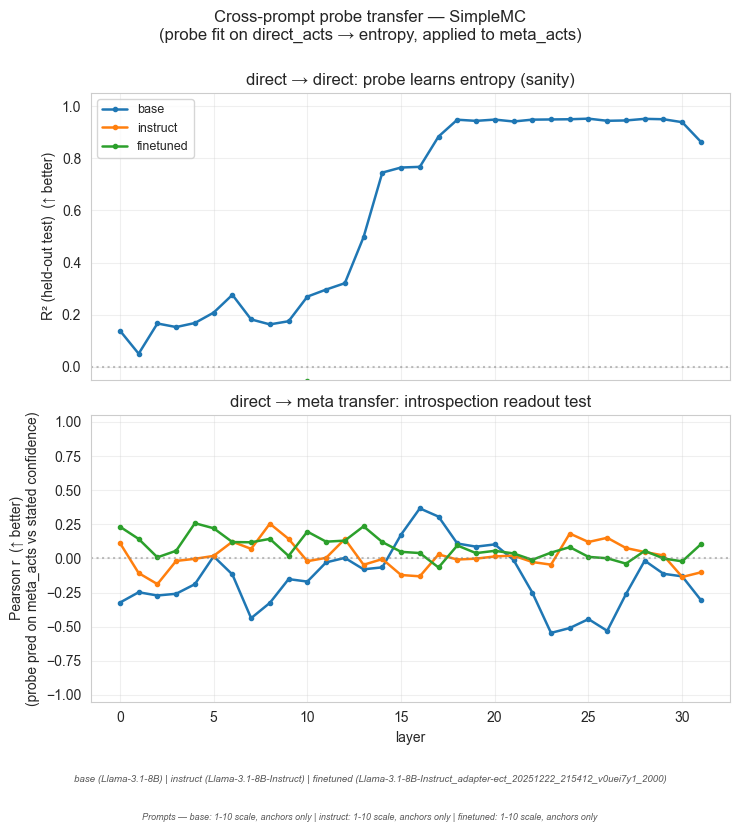

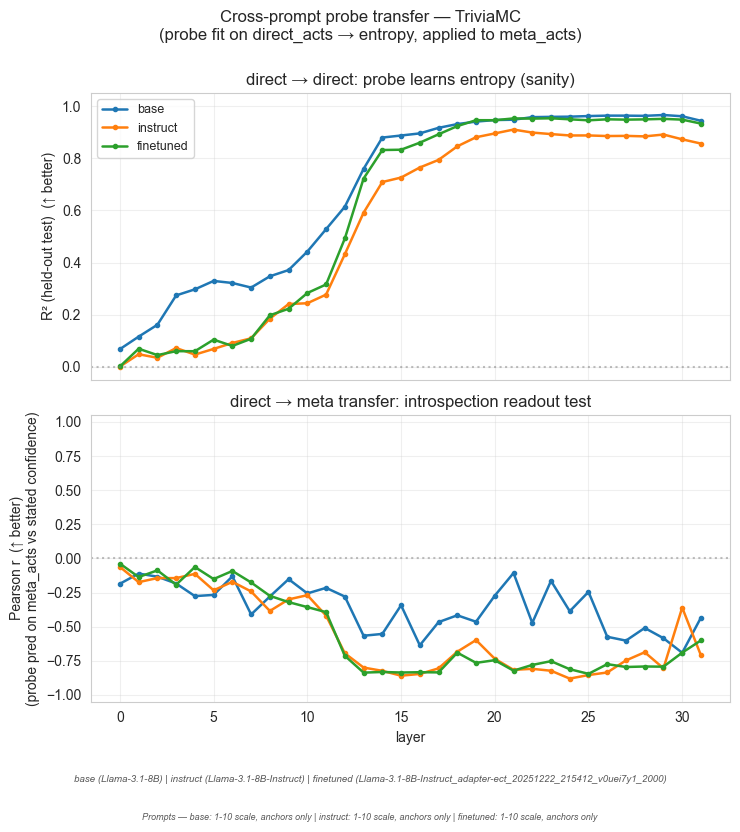


=== Section 4.4 summary — SimpleMC (at each model's margin-peak layer) ===

    model  peak_layer  d2d R² (entropy)  d2m r (pred-entropy ↔ stated-conf)
     base          28             0.951                              -0.016
 instruct          25            -0.228                               0.121
finetuned          17            -0.152                              -0.066

=== Section 4.4 summary — TriviaMC (at each model's margin-peak layer) ===

    model  peak_layer  d2d R² (entropy)  d2m r (pred-entropy ↔ stated-conf)
     base          30             0.961                              -0.691
 instruct          30             0.873                              -0.360
finetuned          30             0.948                              -0.690


In [28]:
# --- Section 4.4: Cross-prompt probe transfer (introspection readout test) ---
# Train ridge probe on run.direct_acts → entropy (MC prompt),
# apply to run.meta_acts (confidence prompt),
# correlate predictions with stated_confidence_numeric.
# Expected sign-consistent introspection: negative Pearson r.

ensure_probe_results()  # populate PROBE_RESULTS from cache if this cell is run standalone
from core.probes import LinearProbe
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr

PROBE_TRANSFER = {}
# Full identifying label per model-type key (e.g. 'finetuned (Llama-3.1-8B-Instruct_adapter-ect_...)').
MODEL_DISPLAY_LABELS = {m: f"{m} ({MODELS[m]['model_short']})" for m in MODELS}

for key, run in RUNS.items():
    n_layers = run.n_layers
    d2d_r2 = np.full(n_layers, np.nan, dtype=np.float32)
    d2m_r  = np.full(n_layers, np.nan, dtype=np.float32)

    y_ent  = run.df['entropy'].values.astype(np.float64)
    y_conf = run.df['stated_confidence_numeric'].values.astype(np.float64)

    indices = np.arange(len(y_ent))
    train_idx, test_idx = train_test_split(indices, train_size=0.8, random_state=42)
    valid_test = test_idx[~np.isnan(y_conf[test_idx])]

    for layer in range(n_layers):
        X_direct_train = run.direct_acts[train_idx, layer, :].astype(np.float32)
        X_direct_test  = run.direct_acts[test_idx,  layer, :].astype(np.float32)
        X_meta_test    = run.meta_acts[valid_test,  layer, :].astype(np.float32)

        probe = LinearProbe(alpha=1000.0, use_pca=True, pca_components=100)
        probe.fit(X_direct_train, y_ent[train_idx])

        d2d = probe.evaluate(X_direct_test, y_ent[test_idx])
        d2d_r2[layer] = d2d['r2']

        if len(valid_test) >= 10:
            pred_on_meta = probe.predict(X_meta_test)
            if np.std(pred_on_meta) > 1e-9 and np.std(y_conf[valid_test]) > 1e-9:
                r, _ = pearsonr(pred_on_meta, y_conf[valid_test])
                d2m_r[layer] = r

    PROBE_TRANSFER[key] = {'d2d_r2': d2d_r2, 'd2m_r': d2m_r}
    print(f'  {key[0]:>9}/{key[1]:<8}: max d2d R² = {np.nanmax(d2d_r2):+.3f}, '
          f'most-neg d2m r = {np.nanmin(d2m_r):+.3f}')

# --- Plot: 2-row figure per dataset ---
for dataset in DATASETS:
    present = [m for m in MODELS if (m, dataset) in PROBE_TRANSFER]
    if not present:
        continue
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.5, 7.5), sharex=True)
    for model in present:
        pt = PROBE_TRANSFER[(model, dataset)]
        layers = PROBE_RESULTS[(model, dataset)]['layers']
        ax1.plot(layers, pt['d2d_r2'], color=MODEL_COLORS[model], label=model,
                 linewidth=1.8, marker='o', markersize=3)
        ax2.plot(layers, pt['d2m_r'], color=MODEL_COLORS[model], label=model,
                 linewidth=1.8, marker='o', markersize=3)
    ax1.axhline(0, color='gray', linestyle=':', alpha=0.5)
    ax1.set_ylabel('R² (held-out test)  (↑ better)')
    ax1.set_title(f'direct → direct: probe learns entropy (sanity)')
    ax1.set_ylim(-0.05, 1.05)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=9, loc='best')
    ax2.axhline(0, color='gray', linestyle=':', alpha=0.5)
    ax2.set_xlabel('layer')
    ax2.set_ylabel('Pearson r  (↑ better)\n(probe pred on meta_acts vs stated confidence)')
    ax2.set_title(f'direct → meta transfer: introspection readout test')
    ax2.set_ylim(-1.05, 1.05)
    ax2.grid(True, alpha=0.3)
    plt.suptitle(f'Cross-prompt probe transfer — {dataset}\n'
                 f'(probe fit on direct_acts → entropy, applied to meta_acts)', y=1.00)
    footer = ' | '.join(MODEL_DISPLAY_LABELS[m] for m in present)
    fig.text(0.5, -0.03, footer, ha='center', fontsize=7, style='italic', color='0.35')
    plt.tight_layout()
    save_fig(FIGURES_DIR / f's4_probe_transfer_{dataset}.pdf')
    plt.show()

# --- Summary at each model's margin-peak layer ---
for dataset in DATASETS:
    present = [m for m in MODELS if (m, dataset) in PROBE_TRANSFER]
    if not present:
        continue
    rows = []
    for model in present:
        key = (model, dataset)
        pt = PROBE_TRANSFER[key]
        pr = PROBE_RESULTS[key]
        peak_l = int(np.nanargmax(pr['within_r2_natural']['margin_logit']))
        rows.append({
            'model': model,
            'peak_layer': peak_l,
            'd2d R² (entropy)': round(float(pt['d2d_r2'][peak_l]), 3),
            'd2m r (pred-entropy ↔ stated-conf)': round(float(pt['d2m_r'][peak_l]), 3),
        })
    print(f"\n=== Section 4.4 summary — {dataset} (at each model's margin-peak layer) ===\n")
    print(pd.DataFrame(rows).to_string(index=False))

**Section 4 summary (fill in after running):**

- Are cosine values high (margin and stated aligned geometrically)? _TBD_
- Are projection correlations high? _TBD_
- Any **low-cosine, high-projcorr** cases? Those are geometrically different but functionally equivalent directions — important to note in the write-up.

---
## Section 5: Cross-model comparison via behavioral alignment

**Purpose:** Activation bases aren't aligned across models. Compare via scalar projections.

For each model, take per-example projections onto its own fitted margin direction and its own fitted stated-confidence direction (from Section 2, at each model's peak layer).

**Plots:** Scatter of projection(A) vs projection(B) for each pair (base↔instruct, instruct↔finetuned, base↔finetuned). Spearman correlation per pair.

**Interpretation:** Strong base↔finetuned correlation → underlying item ordering preserved → precondition for claiming training operates on a shared signal.

In [29]:
# --- Section 5.1: Per-example scalar projections at each model's peak layer ---
# For each (model, dataset): project direct-prompt activations onto the model's own
# margin_logit probe-weight direction at its best margin layer, and onto its own
# stated_confidence probe-weight direction at its best stated layer.

ensure_probe_results()  # populate PROBE_RESULTS from cache if this cell is run standalone
def peak_layer(probe_res, target='margin_logit'):
    return int(np.nanargmax(probe_res['within_r2_natural'][target]))


PROJECTIONS = {}  # PROJECTIONS[(model, dataset, direction_name)] = dict(example_id -> scalar)
for key, run in RUNS.items():
    pr = PROBE_RESULTS[key]
    for direction_name in ('margin_logit', 'stated_confidence'):
        layer = peak_layer(pr, direction_name)
        w = pr['probe_weights'][direction_name][layer]
        X = run.direct_acts[:, layer, :].astype(np.float32)
        proj = X @ w
        ids = run.df['example_id'].values
        PROJECTIONS[(key[0], key[1], direction_name)] = {
            'example_ids': ids,
            'proj': proj,
            'layer': layer,
        }
print(f'Built projections for {len(PROJECTIONS)} (model, dataset, direction) combos.')

Built projections for 12 (model, dataset, direction) combos.


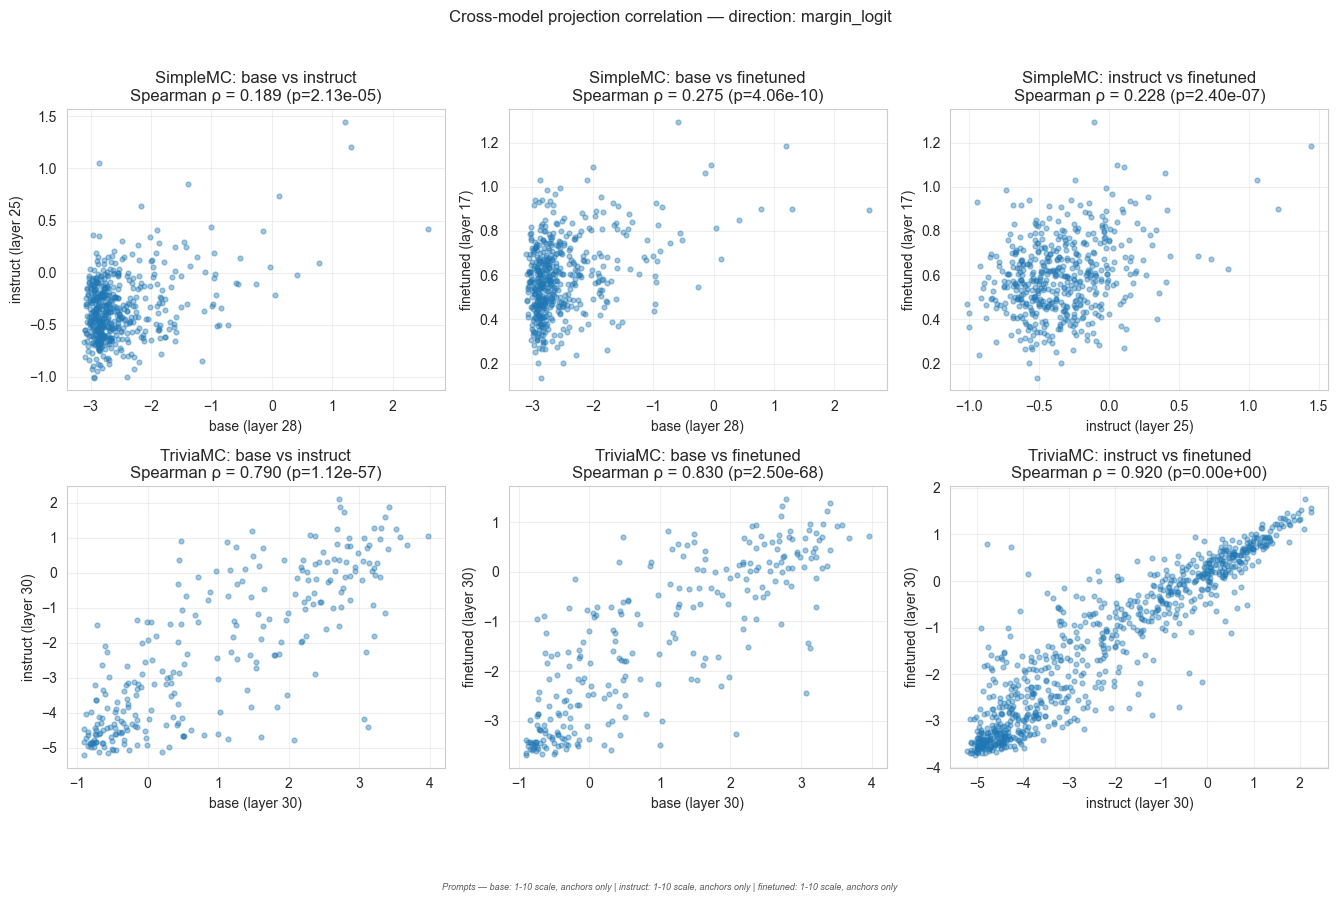

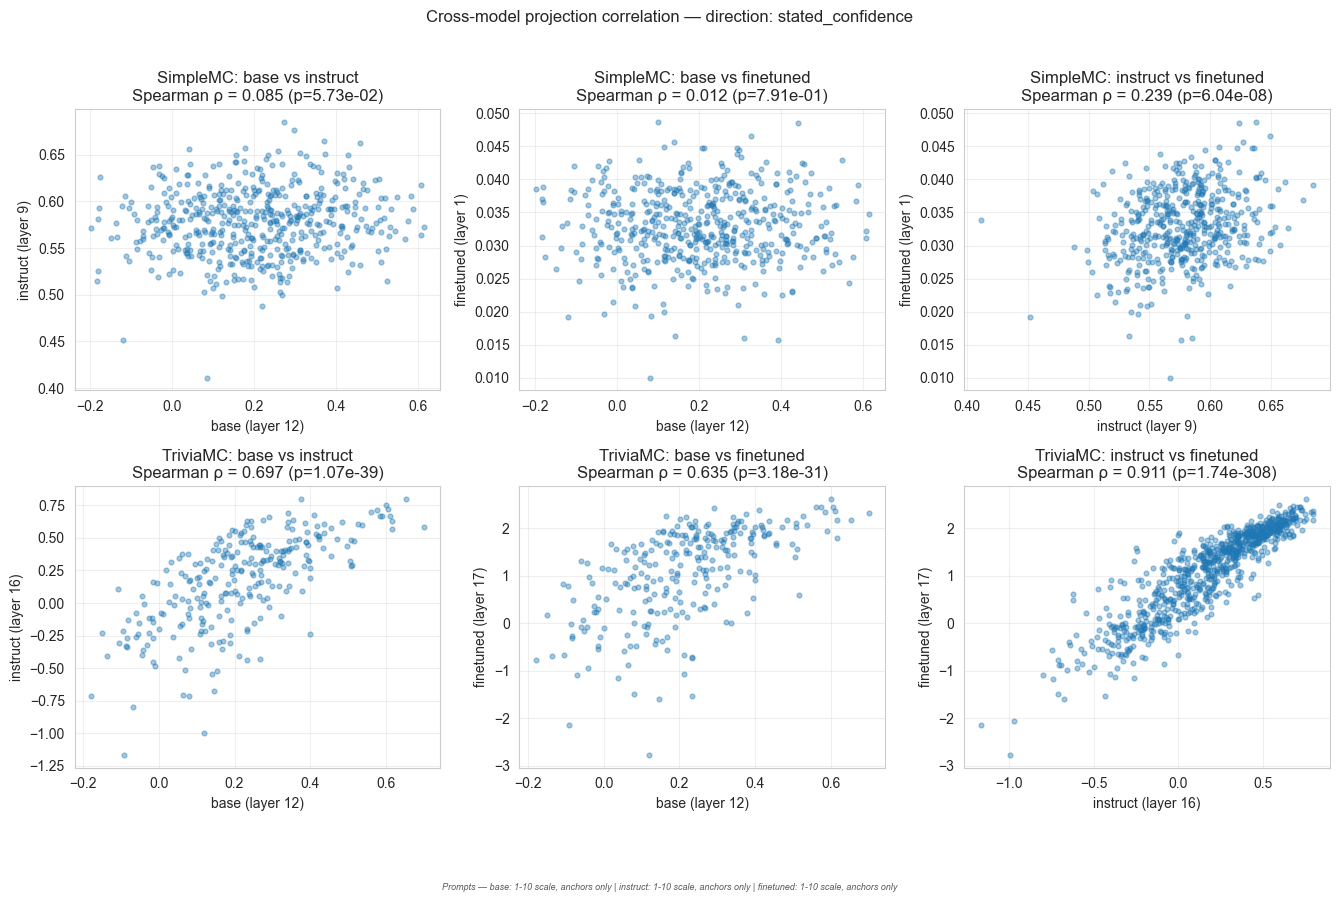


=== Section 5 summary: cross-model Spearman ρ of projections ===
        direction  dataset               pair  spearman_rho  p_value   n
     margin_logit SimpleMC      base↔instruct        0.1889   0.0000 500
     margin_logit SimpleMC     base↔finetuned        0.2749   0.0000 500
     margin_logit SimpleMC instruct↔finetuned        0.2285   0.0000 500
     margin_logit TriviaMC      base↔instruct        0.7903   0.0000 264
     margin_logit TriviaMC     base↔finetuned        0.8298   0.0000 264
     margin_logit TriviaMC instruct↔finetuned        0.9196   0.0000 800
stated_confidence SimpleMC      base↔instruct        0.0851   0.0573 500
stated_confidence SimpleMC     base↔finetuned        0.0119   0.7907 500
stated_confidence SimpleMC instruct↔finetuned        0.2394   0.0000 500
stated_confidence TriviaMC      base↔instruct        0.6969   0.0000 264
stated_confidence TriviaMC     base↔finetuned        0.6351   0.0000 264
stated_confidence TriviaMC instruct↔finetuned        0.910

In [30]:
# --- Section 5.2: Scatter plots + Spearman correlations + text summary ---
from itertools import combinations


def _align_projections(proj_a: dict, proj_b: dict):
    df_a = pd.DataFrame({'example_id': proj_a['example_ids'], 'a': proj_a['proj']})
    df_b = pd.DataFrame({'example_id': proj_b['example_ids'], 'b': proj_b['proj']})
    merged = df_a.merge(df_b, on='example_id', how='inner')
    return merged['a'].values, merged['b'].values


model_pairs = list(combinations(present_models, 2))
rhos_rows = []

for direction_name in ('margin_logit', 'stated_confidence'):
    fig, axes = plt.subplots(
        len(DATASETS), max(1, len(model_pairs)),
        figsize=(4.5 * max(1, len(model_pairs)), 4 * len(DATASETS)),
    )
    axes = np.atleast_2d(axes)
    if len(DATASETS) == 1: axes = axes.reshape(1, -1)
    if len(model_pairs) == 1: axes = axes.reshape(-1, 1)

    for di, dataset in enumerate(DATASETS):
        for mi, (m_a, m_b) in enumerate(model_pairs):
            ax = axes[di, mi]
            k_a = (m_a, dataset, direction_name)
            k_b = (m_b, dataset, direction_name)
            if k_a not in PROJECTIONS or k_b not in PROJECTIONS:
                ax.set_visible(False); continue
            a, b = _align_projections(PROJECTIONS[k_a], PROJECTIONS[k_b])
            rho, p = spearmanr(a, b)
            ax.scatter(a, b, alpha=0.4, s=12)
            ax.set_xlabel(f'{m_a} (layer {PROJECTIONS[k_a]["layer"]})')
            ax.set_ylabel(f'{m_b} (layer {PROJECTIONS[k_b]["layer"]})')
            ax.set_title(f'{dataset}: {m_a} vs {m_b}\nSpearman ρ = {rho:.3f} (p={p:.2e})')
            ax.grid(True, alpha=0.3)
            rhos_rows.append({
                'direction': direction_name, 'dataset': dataset,
                'pair': f'{m_a}↔{m_b}', 'spearman_rho': float(rho), 'p_value': float(p), 'n': len(a),
            })
    plt.suptitle(f'Cross-model projection correlation — direction: {direction_name}', y=1.02)
    plt.tight_layout()
    save_fig(FIGURES_DIR / f's5_cross_model_scatter_{direction_name}.pdf')
    plt.show()

# Text summary: all pairwise Spearman correlations
print('\n=== Section 5 summary: cross-model Spearman ρ of projections ===')
rho_df = pd.DataFrame(rhos_rows).round(4)
print(rho_df.to_string(index=False))


**Section 5 summary (fill in after running):**

- Base ↔ instruct Spearman ρ (margin): _TBD_
- Base ↔ finetuned Spearman ρ (margin): _TBD_
- Instruct ↔ finetuned Spearman ρ (margin): _TBD_

Strong correlations across all pairs mean the per-item uncertainty ordering is preserved through training — precondition for claiming training operates on a shared signal rather than reinventing one.

---
## Section 6: Representational similarity analysis (RSA)

**Purpose:** For each model × layer, compute pairwise cosine/correlation matrix over a fixed shared stimulus subset. Compare RSMs across models via Spearman correlation of off-diagonal entries.

**Visualization:** Heatmap of RSM similarity between models, layer by layer.

**Interpretation:**
- High at all layers → broadly shared representations, training is readout change (**H1/H3**).
- Drops at late layers → training operates on late representations (**H3**).

In [31]:
# --- Section 6.1: Build shared-stimulus index per dataset ---
# All models share example_ids within a dataset (same questions, same seed).
# Intersect ids across loaded models to get a common-subject subset.

def shared_ids(dataset: str) -> np.ndarray:
    id_sets = []
    for model in MODELS:
        if (model, dataset) in RUNS:
            id_sets.append(set(RUNS[(model, dataset)].df['example_id'].values))
    if not id_sets:
        return np.array([])
    shared = sorted(set.intersection(*id_sets))
    return np.array(shared)


SHARED_IDS = {d: shared_ids(d) for d in DATASETS}
for d, ids in SHARED_IDS.items():
    print(f'  {d}: {len(ids)} shared example_ids across {sum(1 for m in MODELS if (m, d) in RUNS)} models')

  SimpleMC: 500 shared example_ids across 3 models
  TriviaMC: 264 shared example_ids across 3 models


In [32]:
# --- Section 6.2: Compute per-layer RSMs on shared subset (cosine of mean-centered acts) ---

def compute_rsm_stack(run: RunData, shared_ids_arr: np.ndarray, normalize: bool = True) -> np.ndarray:
    """Return (n_layers, n_shared, n_shared) pairwise cosine similarity matrix."""
    # Index shared examples
    id_to_idx = {eid: i for i, eid in enumerate(run.df['example_id'].values)}
    subset_idx = np.array([id_to_idx[eid] for eid in shared_ids_arr])
    out = np.empty((run.n_layers, len(subset_idx), len(subset_idx)), dtype=np.float32)
    for layer in range(run.n_layers):
        X = run.direct_acts[subset_idx, layer, :].astype(np.float32)
        if normalize:
            X = X - X.mean(axis=0, keepdims=True)
        norms = np.linalg.norm(X, axis=1, keepdims=True) + 1e-9
        Xn = X / norms
        out[layer] = Xn @ Xn.T
    return out


RSMS = {}  # (model, dataset) -> (n_layers, n_shared, n_shared)
# Cached with the same fingerprint scheme as fit_probes_for_run:
# the cache self-invalidates if the underlying activations change.
for (model, dataset), run in RUNS.items():
    ids = SHARED_IDS[dataset]
    if len(ids) < 50:
        print(f'Skipping RSM for {model}/{dataset} (only {len(ids)} shared ids)')
        continue
    ids_fp = hashlib.md5('|'.join(str(x) for x in np.asarray(ids)).encode()).hexdigest()[:12]
    fp = f'{_fingerprint(run)}|ids={ids_fp}|n_ids={len(ids)}'
    fp_short = hashlib.md5(fp.encode()).hexdigest()[:16]
    # Filename includes the fingerprint so RSMs for different runs coexist.
    cache_file = CACHE_DIR / f'rsm_{model}_{dataset}_{fp_short}.npz'
    legacy_cache = CACHE_DIR / f'rsm_{model}_{dataset}.npz'
    cached = None
    if cache_file.exists():
        with np.load(cache_file, allow_pickle=False) as f:
            if str(f['fingerprint']) == fp:
                cached = f['rsm']
    if cached is None and legacy_cache.exists():
        with np.load(legacy_cache, allow_pickle=False) as f:
            if str(f['fingerprint']) == fp:
                cached = f['rsm']
                np.savez(cache_file, rsm=cached, fingerprint=np.array(fp))
                print(f'  ✓ {model}/{dataset}: migrated legacy RSM cache → {cache_file.name}')
            else:
                print(f'  ⚠ {model}/{dataset}: RSM fingerprint mismatch — recomputing')
    if cached is not None:
        RSMS[(model, dataset)] = cached
    else:
        RSMS[(model, dataset)] = compute_rsm_stack(run, ids)
        np.savez(cache_file, rsm=RSMS[(model, dataset)], fingerprint=np.array(fp))
    print(f'RSM for {model}/{dataset}: shape {RSMS[(model, dataset)].shape}')

RSM for base/SimpleMC: shape (32, 500, 500)
RSM for base/TriviaMC: shape (32, 264, 264)
RSM for instruct/SimpleMC: shape (32, 500, 500)
RSM for instruct/TriviaMC: shape (32, 264, 264)
RSM for finetuned/SimpleMC: shape (32, 500, 500)
RSM for finetuned/TriviaMC: shape (32, 264, 264)


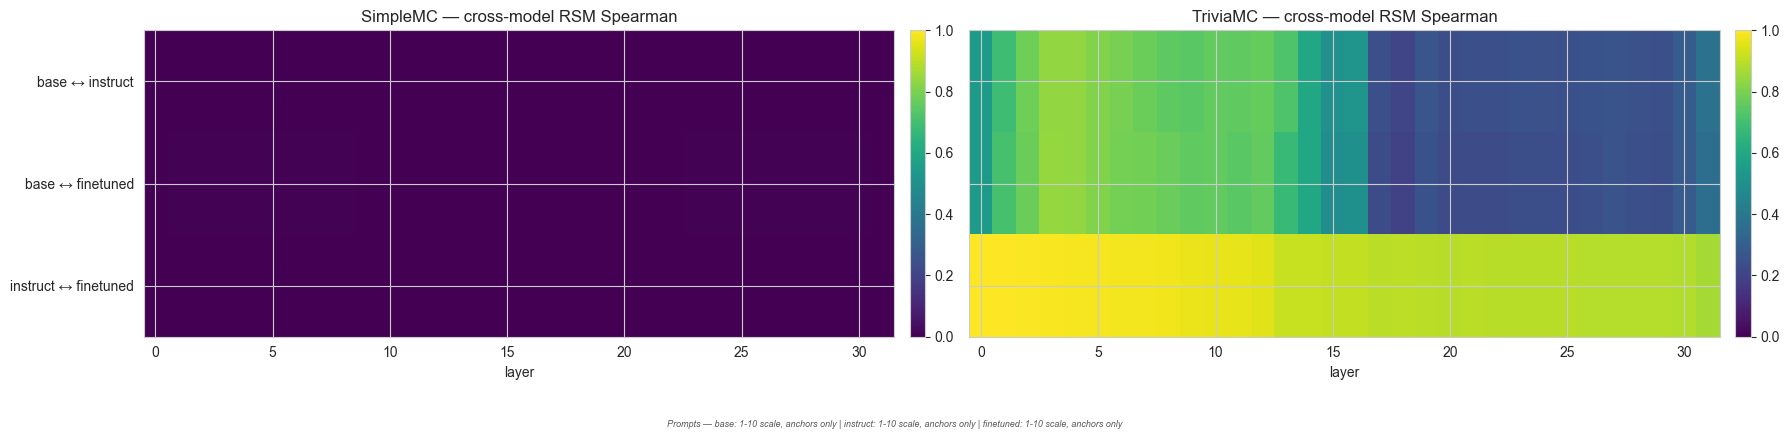


=== Section 6 summary: cross-model RSM similarity (Spearman ρ) ===
If late_vs_early_drop is large and positive → representations diverge at late layers (favors H3)
 dataset               pair  mean_similarity  early_layers (0-7)  mid_layers (8-23)  late_layers (24+)  late_vs_early_drop
SimpleMC      base↔instruct           -0.001              -0.000             -0.002             -0.001               0.001
SimpleMC     base↔finetuned            0.003               0.005              0.002              0.004               0.001
SimpleMC instruct↔finetuned           -0.002              -0.002             -0.002             -0.001              -0.001
TriviaMC      base↔instruct            0.502               0.759              0.489              0.270               0.490
TriviaMC     base↔finetuned            0.496               0.762              0.478              0.264               0.499
TriviaMC instruct↔finetuned            0.930               0.991              0.922              

In [33]:
# --- Section 6.3: Cross-model RSM similarity + text summary ---

def _offdiag(M: np.ndarray) -> np.ndarray:
    n = M.shape[0]
    iu = np.triu_indices(n, k=1)
    return M[iu]


def cross_rsm_spearman(rsm_a: np.ndarray, rsm_b: np.ndarray) -> np.ndarray:
    n_layers = rsm_a.shape[0]
    out = np.full(n_layers, np.nan)
    for L in range(n_layers):
        a = _offdiag(rsm_a[L])
        b = _offdiag(rsm_b[L])
        out[L] = spearmanr(a, b).correlation
    return out


fig, axes = plt.subplots(1, len(DATASETS), figsize=(9 * len(DATASETS), 4), sharey=True)
axes = np.atleast_1d(axes)
summary_rows = []

for di, dataset in enumerate(DATASETS):
    rows = []
    row_labels = []
    for (m_a, m_b) in combinations(present_models, 2):
        if (m_a, dataset) not in RSMS or (m_b, dataset) not in RSMS: continue
        sim = cross_rsm_spearman(RSMS[(m_a, dataset)], RSMS[(m_b, dataset)])
        rows.append(sim)
        row_labels.append(f'{m_a} ↔ {m_b}')
        summary_rows.append({
            'dataset': dataset, 'pair': f'{m_a}↔{m_b}',
            'mean_similarity': float(np.nanmean(sim)),
            'early_layers (0-7)': float(np.nanmean(sim[:8])),
            'mid_layers (8-23)': float(np.nanmean(sim[8:24])),
            'late_layers (24+)': float(np.nanmean(sim[24:])),
            'late_vs_early_drop': float(np.nanmean(sim[:8]) - np.nanmean(sim[24:])),
        })
    if not rows:
        axes[di].set_visible(False); continue
    heat = np.stack(rows, axis=0)
    im = axes[di].imshow(heat, aspect='auto', cmap='viridis', vmin=0, vmax=1)
    axes[di].set_yticks(range(len(row_labels)))
    axes[di].set_yticklabels(row_labels)
    axes[di].set_xlabel('layer')
    axes[di].set_title(f'{dataset} — cross-model RSM Spearman')
    plt.colorbar(im, ax=axes[di], fraction=0.02, pad=0.02)
plt.tight_layout()
save_fig(FIGURES_DIR / 's6_rsm_cross_model.pdf')
plt.show()

# Text summary: mean RSM similarity + early-vs-late pattern
print('\n=== Section 6 summary: cross-model RSM similarity (Spearman ρ) ===')
print('If late_vs_early_drop is large and positive → representations diverge at late layers (favors H3)')
rsm_df = pd.DataFrame(summary_rows).round(3)
print(rsm_df.to_string(index=False))


**Section 6 summary (fill in after running):**

- Shape of RSM cross-model Spearman curve across layers: _TBD_
- If high everywhere (flat, high) → representations broadly shared → training is readout change (H1/H3)
- If high at early layers, **drops at late layers** → training operates late (H3)
- If low everywhere → representations meaningfully diverge (rules out strong H1)

---
## Section 7: Cross-decoding across models

**Purpose:** Extend cross-prediction across models. Fit probe on X in model A, apply to model B's activations to predict X.

**Activations used (all three rows).** Always `dst_run.direct_acts` — the residual stream from the **MC (direct) forward pass**. The probe's weight vector, fit on the source model's direct-pass activations, is projected through the destination model's direct-pass activations.

**Target values (differ per row).**
- `margin_logit` — computed from the **direct/MC forward pass** logits (same prompt as the activations).
- `entropy` — computed from the **direct/MC forward pass** output distribution (same prompt as the activations).
- `stated_confidence` — extracted from the **meta/confidence forward pass** output (different prompt). This row is therefore a *cross-prompt AND cross-model* test: can an MC-prompt direction from model A predict what model B goes on to verbally report in the confidence prompt?

Report held-out R² of cross-model probe vs within-model. Bases aren't aligned — point is **quantifying how much it fails.**

**Interpretation:**
- Cross-model probe works passably (within ~30% of within-model) → representation largely preserved.
- Collapses → finetuning substantially changed representation (favors **H2**).
- `stated_confidence` transfer dropping faster than the other two would specifically suggest the reporting channel realigned, even if the underlying uncertainty representation survived.

In [34]:
# --- Section 7.1: Apply probe from model A to model B's activations ---
# For each (model_A, model_B, layer, target_X in {margin_logit, stated_confidence, entropy}):
#   Use probe weights fit on A (all examples), apply to B's activations at same layer
#   Score predictions against B's true target values on held-out CV folds.

ensure_probe_results()  # populate PROBE_RESULTS from cache if this cell is run standalone
XMODEL_TARGETS = ['margin_logit', 'stated_confidence', 'entropy']


def cross_model_apply(src_run: RunData, src_probes: dict,
                      dst_run: RunData, target: str) -> np.ndarray:
    """Return (n_layers,) R² of src probe applied to dst activations to predict dst target."""
    n_layers = src_run.n_layers
    col = TARGETS[target]['col']
    out = np.full(n_layers, np.nan)
    y_dst = np.asarray(dst_run.df[col].values).astype(float)
    valid = ~np.isnan(y_dst)
    if valid.sum() < 20:
        return out
    for layer in range(n_layers):
        w = src_probes['probe_weights'][target][layer]
        X = dst_run.direct_acts[:, layer, :].astype(np.float32)
        # scaler state isn't saved across models (bases differ) — use raw projection
        # and regress the scalar onto target on dst's own held-out folds.
        # This lets us ask: "is the direction informative about dst's target?"
        proj = X @ w
        cv = KFold(N_SPLITS, shuffle=True, random_state=SEED)
        preds = np.full(dst_run.n_examples, np.nan)
        X_scalar = proj[valid].reshape(-1, 1)
        y_valid = y_dst[valid]
        for tr, te in cv.split(X_scalar):
            reg = RidgeCV(alphas=RIDGE_ALPHAS).fit(X_scalar[tr], y_valid[tr])
            preds[np.where(valid)[0][te]] = reg.predict(X_scalar[te])
        m = ~np.isnan(preds)
        out[layer] = r2_score(y_dst[m], preds[m])
    return out


XMODEL_RESULTS = {}  # (src_model, dst_model, dataset, target) -> (n_layers,) array
for dataset in DATASETS:
    for src in present_models:
        for dst in present_models:
            if src == dst: continue
            if (src, dataset) not in RUNS or (dst, dataset) not in RUNS: continue
            for target in XMODEL_TARGETS:
                XMODEL_RESULTS[(src, dst, dataset, target)] = cross_model_apply(
                    RUNS[(src, dataset)], PROBE_RESULTS[(src, dataset)],
                    RUNS[(dst, dataset)], target,
                )
            print(f'Done: {src} → {dst} on {dataset}')

Done: base → instruct on SimpleMC
Done: base → finetuned on SimpleMC
Done: instruct → base on SimpleMC
Done: instruct → finetuned on SimpleMC
Done: finetuned → base on SimpleMC
Done: finetuned → instruct on SimpleMC
Done: base → instruct on TriviaMC
Done: base → finetuned on TriviaMC
Done: instruct → base on TriviaMC
Done: instruct → finetuned on TriviaMC
Done: finetuned → base on TriviaMC
Done: finetuned → instruct on TriviaMC


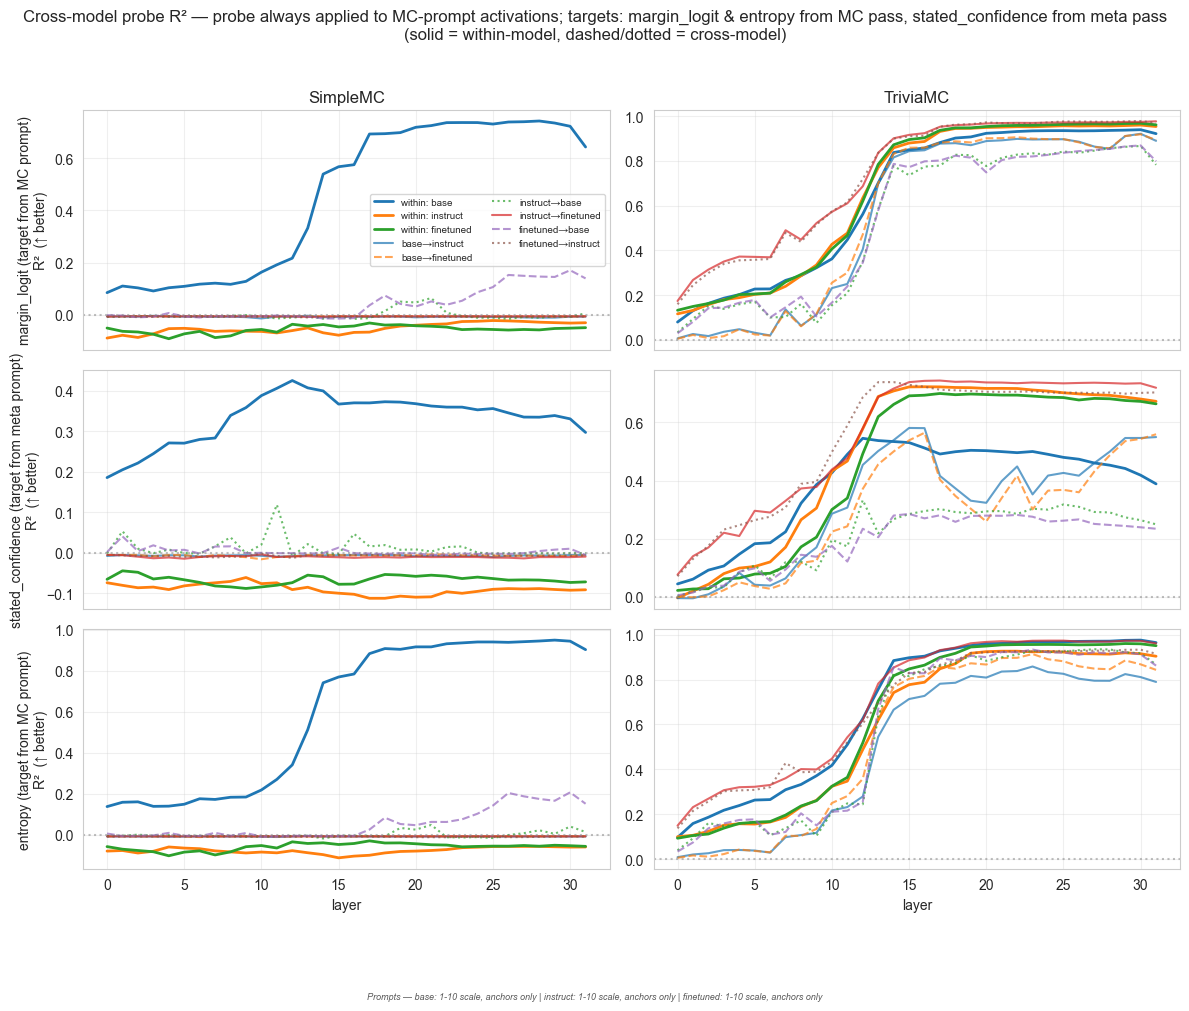


=== Section 7 summary: cross-model probe transfer peaks ===
transfer_ratio = cross_r2 / within_r2_of_destination_at_same_layer
      src       dst  dataset            target  peak_layer  cross_r2  dst_within_r2  transfer_ratio
     base  instruct SimpleMC      margin_logit          13    -0.003         -0.050             NaN
     base  instruct SimpleMC stated_confidence          18    -0.006         -0.112             NaN
     base  instruct SimpleMC           entropy          13    -0.005         -0.087             NaN
     base finetuned SimpleMC      margin_logit          19    -0.005         -0.038             NaN
     base finetuned SimpleMC stated_confidence          21    -0.004         -0.055             NaN
     base finetuned SimpleMC           entropy          31    -0.007         -0.056             NaN
 instruct      base SimpleMC      margin_logit          21     0.064          0.725           0.089
 instruct      base SimpleMC stated_confidence          11     0.118    

In [35]:
# --- Section 7.2: Plot cross-model probe R² + text summary ---
ensure_probe_results()  # populate PROBE_RESULTS from cache if this cell is run standalone
TARGET_PROMPT_SRC = {'margin_logit': 'MC prompt', 'entropy': 'MC prompt', 'stated_confidence': 'meta prompt'}
fig, axes = plt.subplots(
    len(XMODEL_TARGETS), len(DATASETS),
    figsize=(6 * len(DATASETS), 3 * len(XMODEL_TARGETS)),
    sharex=True,
)
axes = np.atleast_2d(axes)
if len(XMODEL_TARGETS) == 1: axes = axes.reshape(1, -1)
if len(DATASETS) == 1: axes = axes.reshape(-1, 1)

for ti, target in enumerate(XMODEL_TARGETS):
    for di, dataset in enumerate(DATASETS):
        ax = axes[ti, di]
        for model in present_models:
            if (model, dataset) not in PROBE_RESULTS: continue
            res = PROBE_RESULTS[(model, dataset)]
            ax.plot(res['layers'], res['within_r2_natural'][target],
                    color=MODEL_COLORS.get(model, 'gray'),
                    label=f'within: {model}', linewidth=2)
        linestyles = ['-', '--', ':']
        li = 0
        for src in present_models:
            for dst in present_models:
                if src == dst: continue
                key = (src, dst, dataset, target)
                if key not in XMODEL_RESULTS: continue
                ax.plot(PROBE_RESULTS[(dst, dataset)]['layers'], XMODEL_RESULTS[key],
                        linestyle=linestyles[li % len(linestyles)], alpha=0.7,
                        label=f'{src}→{dst}')
                li += 1
        ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
        if ti == 0: ax.set_title(dataset)
        if di == 0: ax.set_ylabel(f'{target} (target from {TARGET_PROMPT_SRC.get(target, "?")})\nR²  (↑ better)')
        if ti == len(XMODEL_TARGETS) - 1: ax.set_xlabel('layer')
        ax.grid(True, alpha=0.3)
        if ti == 0 and di == 0:
            ax.legend(fontsize=7, loc='best', ncol=2)
plt.suptitle('Cross-model probe R² — probe always applied to MC-prompt activations; '
             'targets: margin_logit & entropy from MC pass, stated_confidence from meta pass\n'
             '(solid = within-model, dashed/dotted = cross-model)', y=1.02)
plt.tight_layout()
save_fig(FIGURES_DIR / 's7_cross_model_probe.pdf')
plt.show()

# Text summary: peak cross-model transfer R² vs within-model R² at the same layer
print('\n=== Section 7 summary: cross-model probe transfer peaks ===')
print('transfer_ratio = cross_r2 / within_r2_of_destination_at_same_layer')
rows = []
for (src, dst, dataset, target), arr in XMODEL_RESULTS.items():
    if np.all(np.isnan(arr)): continue
    peak_layer = int(np.nanargmax(arr))
    cross_r2 = float(arr[peak_layer])
    dst_within = float(PROBE_RESULTS[(dst, dataset)]['within_r2_natural'][target][peak_layer])
    rows.append({
        'src': src, 'dst': dst, 'dataset': dataset, 'target': target,
        'peak_layer': peak_layer,
        'cross_r2': round(cross_r2, 3),
        'dst_within_r2': round(dst_within, 3),
        'transfer_ratio': round(cross_r2 / dst_within, 3) if dst_within > 0 else np.nan,
    })
xm_df = pd.DataFrame(rows)
print(xm_df.to_string(index=False))


Null directions computed for SimpleMC
Null directions computed for TriviaMC


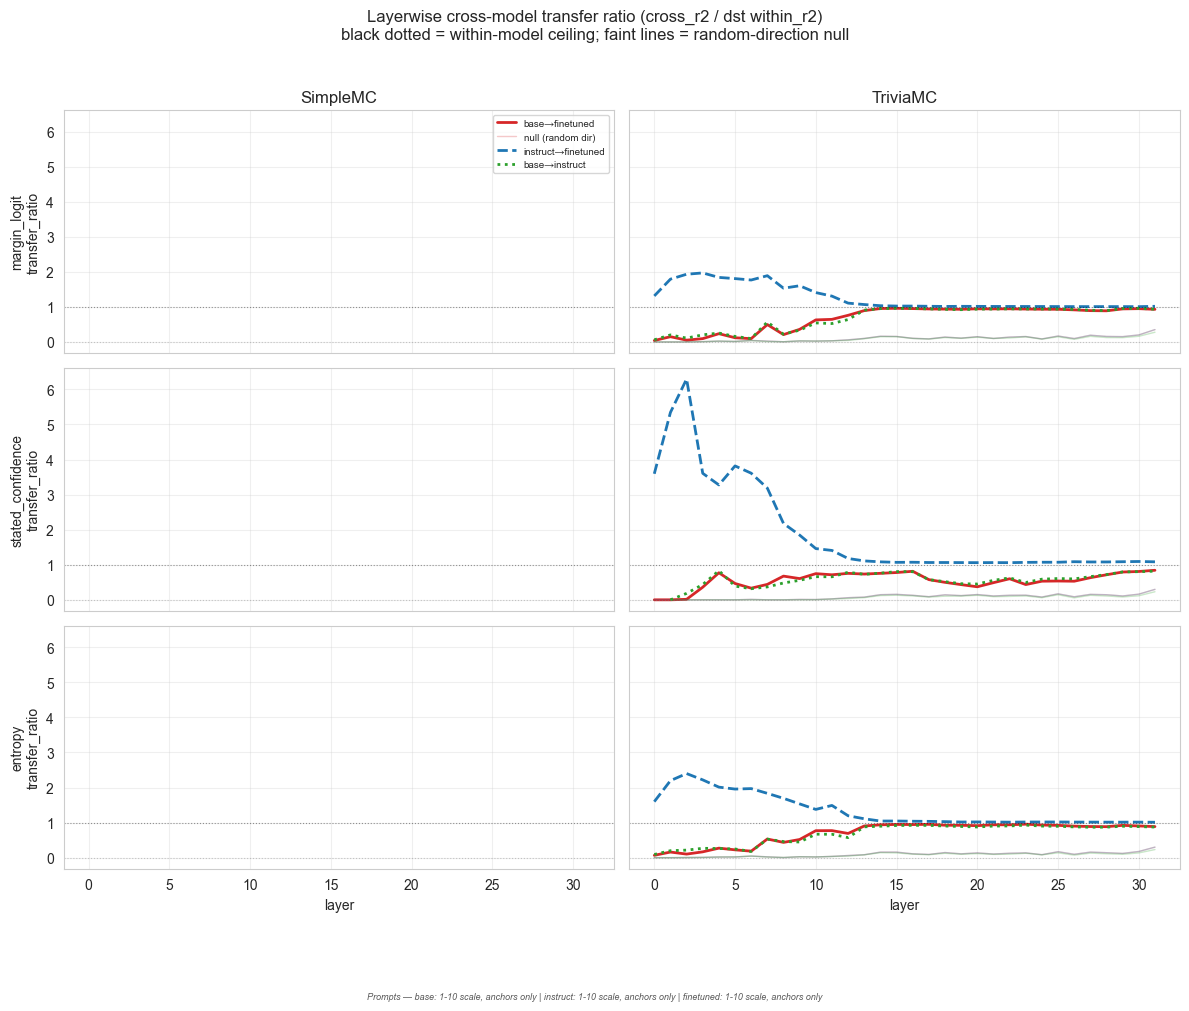

In [36]:
# --- Section 7.3: Layerwise transfer-ratio curves + random-direction null ---
# For the three pairs that matter most for the H1/H2 question:
#   base→finetuned   : does the signal survive the entire training pipeline?
#   instruct→finetuned: does confidence-finetuning exploit instruct's existing direction?
#   base→instruct    : does instruction-tuning already accomplish the readout?
# Per layer, transfer_ratio = cross_r2 / dst_within_r2. Floored at 0 for plotting
# (negative cross_r2 = worse than predicting the mean; ratio is meaningless there).
# The null is the same procedure with a random unit vector substituted for the probe.

ensure_probe_results()
KEY_PAIRS = [('base', 'finetuned'), ('instruct', 'finetuned'), ('base', 'instruct')]
N_NULL_DIRECTIONS = 20


def random_direction_r2(dst_run: RunData, target: str, n_draws: int = N_NULL_DIRECTIONS) -> np.ndarray:
    """Mean held-out R² when projecting dst activations onto a random unit vector, per layer."""
    n_layers = dst_run.n_layers
    d_model = dst_run.direct_acts.shape[-1]
    col = TARGETS[target]['col']
    y_dst = np.asarray(dst_run.df[col].values).astype(float)
    valid = ~np.isnan(y_dst)
    out = np.full(n_layers, np.nan)
    if valid.sum() < 20:
        return out
    rng = np.random.default_rng(SEED)
    for layer in range(n_layers):
        X = dst_run.direct_acts[:, layer, :].astype(np.float32)
        r2s = []
        for _ in range(n_draws):
            w = rng.standard_normal(d_model).astype(np.float32)
            w /= np.linalg.norm(w) + 1e-12
            proj = X @ w
            X_scalar = proj[valid].reshape(-1, 1)
            y_valid = y_dst[valid]
            cv = KFold(N_SPLITS, shuffle=True, random_state=SEED)
            preds = np.full(valid.sum(), np.nan)
            for tr, te in cv.split(X_scalar):
                reg = RidgeCV(alphas=RIDGE_ALPHAS).fit(X_scalar[tr], y_valid[tr])
                preds[te] = reg.predict(X_scalar[te])
            r2s.append(r2_score(y_valid, preds))
        out[layer] = float(np.mean(r2s))
    return out


NULL_RESULTS = {}  # (dst, dataset, target) -> (n_layers,) mean random-direction R²
for dataset in DATASETS:
    for _, dst in KEY_PAIRS:
        if (dst, dataset) not in RUNS: continue
        for target in XMODEL_TARGETS:
            key = (dst, dataset, target)
            if key in NULL_RESULTS: continue
            NULL_RESULTS[key] = random_direction_r2(RUNS[(dst, dataset)], target)
    print(f'Null directions computed for {dataset}')


def floor_ratio(cross_arr: np.ndarray, within_arr: np.ndarray) -> np.ndarray:
    c = np.clip(cross_arr, 0.0, None)
    w = np.where(within_arr > 1e-6, within_arr, np.nan)
    return c / w


fig, axes = plt.subplots(
    len(XMODEL_TARGETS), len(DATASETS),
    figsize=(6 * len(DATASETS), 3 * len(XMODEL_TARGETS)),
    sharex=True, sharey=True,
)
axes = np.atleast_2d(axes)
pair_styles = {('base', 'finetuned'): '-', ('instruct', 'finetuned'): '--', ('base', 'instruct'): ':'}
pair_colors = {('base', 'finetuned'): 'C3', ('instruct', 'finetuned'): 'C0', ('base', 'instruct'): 'C2'}

for ti, target in enumerate(XMODEL_TARGETS):
    for di, dataset in enumerate(DATASETS):
        ax = axes[ti, di]
        null_label_drawn = False
        for (src, dst) in KEY_PAIRS:
            key = (src, dst, dataset, target)
            if key not in XMODEL_RESULTS: continue
            within = PROBE_RESULTS[(dst, dataset)]['within_r2_natural'][target]
            ratio = floor_ratio(XMODEL_RESULTS[key], within)
            layers = PROBE_RESULTS[(dst, dataset)]['layers']
            ax.plot(layers, ratio, linestyle=pair_styles[(src, dst)],
                    color=pair_colors[(src, dst)], linewidth=2,
                    label=f'{src}→{dst}')
            null_key = (dst, dataset, target)
            if null_key in NULL_RESULTS:
                null_ratio = floor_ratio(NULL_RESULTS[null_key], within)
                ax.plot(layers, null_ratio, color=pair_colors[(src, dst)],
                        alpha=0.25, linewidth=1,
                        label='null (random dir)' if not null_label_drawn else None)
                null_label_drawn = True
        ax.axhline(1.0, color='black', linestyle=':', alpha=0.4, linewidth=0.8)
        ax.axhline(0.0, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)
        if ti == 0: ax.set_title(dataset)
        if di == 0: ax.set_ylabel(f'{target}\ntransfer_ratio')
        if ti == len(XMODEL_TARGETS) - 1: ax.set_xlabel('layer')
        ax.grid(True, alpha=0.3)
        if ti == 0 and di == 0:
            ax.legend(fontsize=7, loc='best')
plt.suptitle('Layerwise cross-model transfer ratio (cross_r2 / dst within_r2)\n'
             'black dotted = within-model ceiling; faint lines = random-direction null',
             y=1.02)
plt.tight_layout()
save_fig(FIGURES_DIR / 's7_3_transfer_ratio_layerwise.pdf')
plt.show()


**Section 7 summary (fill in after running):**

- base→finetuned probe transfer R² (margin_logit, peak): _TBD_
- Within-finetuned R² at same layer: _TBD_
- Ratio: _TBD_%

If cross-model transfer is within ~30% of within-model → representation **largely preserved** through finetuning. If it collapses → representation substantially changed (favors H2).

**Caveat:** Probes are applied via raw-scalar projection (no scaler transfer). This is a deliberate relaxation because StandardScaler stats differ across models.

---
## Section 8: Incorporate ablation results (placeholder)

**Purpose:** Load pre-computed ablation results (path TBD), summarize effect on stated confidence vs. margin/entropy across models and layers. Compare against controls: random direction, orthogonal direction, matched noise, layer sweep.

**Hypothesis relevance:** Mechanistic claims rest here. Correlational analyses above are consistent with shared information but don't prove mechanism.
- **H1:** ablating stated-confidence direction → large effect on stated, small on margin.
- **H2:** ablation hurts underlying margin somewhat.
- **H3:** late-layer ablations large; mid-layer small.

In [37]:
# --- Section 8: Ablation results loader (placeholder) ---
#
# Ablations are a SEPARATE experiment: they require re-running the model's
# forward pass with a direction subtracted from the residual stream, not just
# more analysis on the saved activations. The repo has ablation support in
# run_contrastive_direction.py (see INTERVENTION_POSITION and the projection-
# subtraction hook near line ~440).
#
# Recommended experiment flow:
#   1. Pick a direction to ablate. Options:
#        - stated_confidence probe weights at model's peak stated layer
#        - entropy mean-diff direction at the same layer
#        - margin_logit probe weights (as a control: ablating margin direction
#          should hurt stated_conf if they share a direction — H1 test)
#   2. Run a forward pass on both direct and meta prompts with the direction
#      subtracted (or rescaled). Save new metrics: post-ablation margin,
#      entropy, stated_confidence_numeric, chosen answer, etc.
#   3. Run matched controls: random direction, orthogonal direction, same
#      magnitude of noise, layer sweep (apply at each layer separately).
#   4. Save results in a structured format and load here.
#
# Expected schema:
#   {
#     (model, dataset, layer, direction_kind): {
#        'margin_pre':  np.array of n_examples,
#        'margin_post': np.array of n_examples,
#        'stated_pre':  np.array of n_examples,
#        'stated_post': np.array of n_examples,
#        'entropy_pre': ..., 'entropy_post': ...,
#        'direction_kind': one of {'stated_conf', 'margin', 'mean_diff',
#                                  'random', 'orthogonal', 'noise'},
#     }
#   }
# direction_kind 'random', 'orthogonal', 'noise' serve as controls.

ABLATION_RESULTS_PATH: Optional[Path] = None  # Set when ready

if ABLATION_RESULTS_PATH is not None and ABLATION_RESULTS_PATH.exists():
    if ABLATION_RESULTS_PATH.suffix == '.json':
        with open(ABLATION_RESULTS_PATH) as f:
            ABLATION = json.load(f)
    else:
        with open(ABLATION_RESULTS_PATH, 'rb') as f:
            ABLATION = pickle.load(f)

    # Summary: mean shift in stated_confidence and margin per (model, layer, kind)
    print('\n=== Ablation summary: mean per-example shift ===')
    rows = []
    for key, data in (ABLATION.items() if isinstance(ABLATION, dict) else []):
        if isinstance(key, tuple):
            model, dataset, layer, kind = key
        else:
            continue
        d_stated = np.asarray(data['stated_post']) - np.asarray(data['stated_pre'])
        d_margin = np.asarray(data['margin_post']) - np.asarray(data['margin_pre'])
        rows.append({
            'model': model, 'dataset': dataset, 'layer': layer, 'direction_kind': kind,
            'delta_stated_mean': float(np.nanmean(d_stated)),
            'delta_stated_std':  float(np.nanstd(d_stated)),
            'delta_margin_mean': float(np.nanmean(d_margin)),
            'delta_margin_std':  float(np.nanstd(d_margin)),
            'n': int(data.get('n_examples', len(d_stated))),
        })
    abl_df = pd.DataFrame(rows).round(4) if rows else pd.DataFrame()
    if not abl_df.empty:
        print(abl_df.to_string(index=False))

    # Control presence check
    KINDS_EXPECTED = {'stated_conf', 'margin', 'mean_diff', 'random', 'orthogonal', 'noise'}
    kinds_present = set(r['direction_kind'] for r in rows) if rows else set()
    missing = KINDS_EXPECTED - kinds_present
    if missing:
        print(f'\n⚠ Missing control kinds: {sorted(missing)}')
    else:
        print('\n✓ All expected direction_kind categories present.')
else:
    print('No ablation results loaded. Run an ablation experiment and set ABLATION_RESULTS_PATH.')
    ABLATION = None


No ablation results loaded. Run an ablation experiment and set ABLATION_RESULTS_PATH.


**Section 8 summary:** _TBD (awaiting ablation results file path)_

---
## Section 9: Persona extension (stub)

**Purpose:** If persona-conditioned runs exist, fit margin and stated-confidence probes per persona; test cross-persona transfer.

**Prediction:** If personas share an uncertainty computation but differ in reporting, margin direction should be more shared across personas than stated-confidence direction.

**Status:** No persona data currently collected. Stub only.

In [38]:
# Section 9 — stub. Skip until persona data is available.

---
## Section 12: Logit-lens / per-option depth dynamics

**Purpose:** Test the "competing answers gain/lose energy across depth" hypothesis.

At each layer, project the residual stream through the model's own final RMSNorm + unembedding matrix (`W_U`) to get intermediate logits for the four option tokens (A/B/C/D). This is the standard **logit-lens** technique. Track each option's logit across depth per example, then aggregate:

- **Per-option trajectory** — how does logit(A), logit(B), logit(C), logit(D) evolve layer by layer?
- **Option rank** over depth — which option is winning at each layer?
- **Margin over depth** — how decisive is the current winner?
- **Entropy over 4 options** — does uncertainty monotonically decrease, or does it spike/oscillate?
- **Conditioning on final choice** — when the model ultimately picks A, what do A's trajectory and competitors look like? Do correct and incorrect trials differ?

### Requirements

You need two tiny files per model: the option-token rows of `W_U` and the final RMSNorm weight. Run [`extract_logit_lens_components.py`](extract_logit_lens_components.py) on the remote machine, then pull the `outputs/logit_lens_components_*.npz` files locally. The files are ~20 KB each.

### Hypothesis relevance

If we see the **correct answer's logit rise smoothly** across layers while the model picks the correct answer, and **competitor logits drop monotonically**, that's the simple picture. If we see a **competitor dominating at mid-layers then losing** at late layers (especially on hard questions), that supports a richer dynamics story. If **all four stay near equal** until the very last few layers, it favors H3 (reporting policy is localized late).


In [39]:
# --- Section 12.1: Load logit-lens components ---
# Requires running extract_logit_lens_components.py on the remote machine
# and pulling the resulting .npz files into outputs/.

LOGIT_LENS_FILES = {
    'base':      OUTPUTS_DIR / 'logit_lens_components_Llama-3.1-8B.npz',
    'instruct':  OUTPUTS_DIR / 'logit_lens_components_Llama-3.1-8B-Instruct.npz',
    # The finetuned run shares weights with instruct (LoRA only) except for the
    # adapter layers. If you extracted finetuned separately, point to that file.
    'finetuned': OUTPUTS_DIR / 'logit_lens_components_Llama-3.1-8B-Instruct.npz',
}

LOGIT_LENS = {}
for model_name, p in LOGIT_LENS_FILES.items():
    if p.exists():
        LOGIT_LENS[model_name] = np.load(p, allow_pickle=True)
        W_U = LOGIT_LENS[model_name]['W_U']
        fn = LOGIT_LENS[model_name]['final_norm']
        print(f'  ✓ {model_name}: W_U shape={W_U.shape}, final_norm shape={fn.shape}')
    else:
        print(f'  ✗ {model_name}: missing {p.name}')


  ✗ base: missing logit_lens_components_Llama-3.1-8B.npz
  ✗ instruct: missing logit_lens_components_Llama-3.1-8B-Instruct.npz
  ✗ finetuned: missing logit_lens_components_Llama-3.1-8B-Instruct.npz


In [40]:
# --- Section 12.2: Compute per-layer per-option logits (logit lens) ---

def rms_norm(x: np.ndarray, weight: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    """Apply RMSNorm: x / sqrt(mean(x^2) + eps) * weight.
    x: (..., d), weight: (d,) -> same shape as x."""
    x32 = x.astype(np.float32)
    rms = np.sqrt((x32 ** 2).mean(axis=-1, keepdims=True) + eps)
    return (x32 / rms) * weight.astype(np.float32)


def logit_lens_trajectories(run: RunData, model_label: str) -> np.ndarray:
    """For each example × layer, compute logits for the 4 option tokens using
    the model's own final norm + unembed rows. Returns (n_examples, n_layers, 4)
    where the last axis is the option order [A, B, C, D]."""
    if model_label not in LOGIT_LENS:
        return None
    W_U = LOGIT_LENS[model_label]['W_U'].astype(np.float32)          # (4, d_model)
    final_norm_w = LOGIT_LENS[model_label]['final_norm'].astype(np.float32)  # (d_model,)
    acts = run.direct_acts.astype(np.float32)                        # (n, L, d)
    # Apply RMSNorm per (example, layer), then dot with W_U.T
    x_normed = rms_norm(acts, final_norm_w)                          # (n, L, d)
    logits = x_normed @ W_U.T                                        # (n, L, 4)
    return logits


LL_TRAJ = {}
for key, run in RUNS.items():
    model, dataset = key
    traj = logit_lens_trajectories(run, model)
    if traj is not None:
        LL_TRAJ[key] = traj
        print(f'  {model}/{dataset}: trajectories shape {traj.shape}')


In [41]:
# --- Section 12.3: Per-option logit trajectory plots ---
# For each (model, dataset), plot mean logit per option across layers,
# conditioned on the final chosen option. Expect the chosen option\'s
# trajectory to diverge upward toward the end.

OPTION_COLORS = {'A': 'tab:blue', 'B': 'tab:orange', 'C': 'tab:green', 'D': 'tab:red'}
OPTIONS = list('ABCD')

present_models = [m for m in MODELS if any((m, d) in LL_TRAJ for d in DATASETS)]

if not present_models:
    print('  ⚠ LL_TRAJ is empty — run extract_logit_lens_components.py on the remote and pull the .npz files into outputs/. Skipping logit-lens plots.')
else:
    for dataset in DATASETS:
        fig, axes = plt.subplots(1, len(present_models),
                                 figsize=(5 * len(present_models), 4.5),
                                 sharey=True, sharex=True)
        axes = np.atleast_1d(axes)
        for mi, model in enumerate(present_models):
            key = (model, dataset)
            if key not in LL_TRAJ: continue
            ax = axes[mi]
            traj = LL_TRAJ[key]               # (n, L, 4)
            layers = np.arange(traj.shape[1])
            for oi, opt in enumerate(OPTIONS):
                mean_traj = traj[:, :, oi].mean(axis=0)
                std_traj = traj[:, :, oi].std(axis=0)
                ax.plot(layers, mean_traj, label=f'logit({opt})', color=OPTION_COLORS[opt], linewidth=2)
                ax.fill_between(layers, mean_traj - std_traj, mean_traj + std_traj,
                                color=OPTION_COLORS[opt], alpha=0.12)
            ax.set_title(f'{model}')
            ax.set_xlabel('layer')
            if mi == 0: ax.set_ylabel(f'{dataset} — mean logit per option')
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8)
        plt.suptitle(f'Logit-lens per-option trajectories — {dataset}', y=1.02)
        plt.tight_layout()
        save_fig(FIGURES_DIR / f's12_trajectories_{dataset}.pdf')
        plt.show()

    # Text summary: per-model layer where the chosen option first takes lead
    print('\n=== Section 12 summary: depth at which each option first becomes top-1 ===')
    print('(averaged over examples where that option is the final chosen answer)')
    rows = []
    for key in LL_TRAJ:
        model, dataset = key
        traj = LL_TRAJ[key]                                 # (n, L, 4)
        df = RUNS[key].df
        chosen_idx = np.array([OPTIONS.index(r) if r in OPTIONS else 0
                               for r in df['direct_response'].values])
        # For each example, find first layer where chosen option becomes top-1
        top1 = traj.argmax(axis=-1)                         # (n, L)
        first_lead = np.full(len(chosen_idx), traj.shape[1])  # default: never leads
        for i, ci in enumerate(chosen_idx):
            matches = np.where(top1[i] == ci)[0]
            if len(matches): first_lead[i] = matches[0]
        for opt_i, opt in enumerate(OPTIONS):
            mask = chosen_idx == opt_i
            if mask.sum() == 0: continue
            med = int(np.median(first_lead[mask]))
            rows.append({'model': model, 'dataset': dataset, 'chosen_option': opt,
                         'median_first_lead_layer': med, 'n_examples': int(mask.sum())})
    print(pd.DataFrame(rows).to_string(index=False))


  ⚠ LL_TRAJ is empty — run extract_logit_lens_components.py on the remote and pull the .npz files into outputs/. Skipping logit-lens plots.


In [42]:
# Guard: depends on LL_TRAJ from section 12.2.
_present_models_ll = [m for m in MODELS if any((m, d) in LL_TRAJ for d in DATASETS)]
if not _present_models_ll:
    print('  ⚠ LL_TRAJ is empty — skipping section 12.4 (margin + entropy trajectories).')
else:
    # --- Section 12.4: Margin + entropy trajectories over depth ---
    # Uncertainty dissipation curves: does entropy drop smoothly or in a late burst?

    fig, axes = plt.subplots(2, len(DATASETS), figsize=(6 * len(DATASETS), 8), sharex=True)
    axes = np.atleast_2d(axes)
    if len(DATASETS) == 1: axes = axes.reshape(-1, 1)

    for di, dataset in enumerate(DATASETS):
        for model in present_models:
            key = (model, dataset)
            if key not in LL_TRAJ: continue
            traj = LL_TRAJ[key]                                              # (n, L, 4)
            # Per-layer softmax over 4 options
            sorted_logits = np.sort(traj, axis=-1)[:, :, ::-1]               # descending
            margin = sorted_logits[:, :, 0] - sorted_logits[:, :, 1]         # (n, L)
            # Entropy over the 4 options
            probs = np.exp(traj - sorted_logits[:, :, :1])
            probs = probs / probs.sum(axis=-1, keepdims=True)
            ent = -(probs * np.log(probs + 1e-12)).sum(axis=-1)              # (n, L)

            layers = np.arange(traj.shape[1])
            axes[0, di].plot(layers, margin.mean(axis=0), label=model, linewidth=2)
            axes[1, di].plot(layers, ent.mean(axis=0), label=model, linewidth=2)

        axes[0, di].set_title(f'{dataset} — margin(top − 2nd) across depth')
        axes[0, di].set_ylabel('mean margin (logit units)')
        axes[0, di].grid(True, alpha=0.3); axes[0, di].legend(fontsize=8)
        axes[1, di].set_title(f'{dataset} — entropy over 4 options across depth')
        axes[1, di].set_xlabel('layer'); axes[1, di].set_ylabel('mean entropy (nats)')
        axes[1, di].grid(True, alpha=0.3); axes[1, di].legend(fontsize=8)

    plt.suptitle('Depth dynamics: how quickly does uncertainty resolve?', y=1.01)
    plt.tight_layout()
    save_fig(FIGURES_DIR / 's12_depth_dynamics.pdf')
    plt.show()


  ⚠ LL_TRAJ is empty — skipping section 12.4 (margin + entropy trajectories).


**Section 12 summary (fill in after running):**

- Do the 4 options start with near-equal logits and gradually separate, or is there a sudden late divergence? _TBD_
- Conditional on the final chosen answer, at which layer does the chosen option become top-1? _TBD_
- Does the margin curve rise smoothly or is it nearly flat until the last few layers? _TBD_
- Does the entropy curve drop smoothly (gradual resolution) or have a late step-change (late-stage decision)?  _TBD_
- **Flag any option that dominates early then loses** — that\'s the most interesting "competing answers" signature.

Hypothesis cross-reference:
- Gradual trajectories across all layers → information accumulates distributed across depth
- Flat mid-layers + sharp late rise → decision localized to last layers (**H3 signature**)
- Correct-vs-incorrect trajectories diverge mainly at late layers → reporting policy (H3); diverge earlier → deeper disagreement about the answer itself

---
## Section 10: Fill in the hypothesis scorecard

**Purpose:** Return to the scorecard from Section 0. For each cell (hypothesis × signature), fill in whether the empirical result matches, partially matches, or contradicts the prediction. Write a paragraph summary.

In [43]:
# --- Section 10: Fill in the observed signatures and score matches ---
# This is a manual-interpretation cell. Replace 'TBD' with observations
# from the earlier sections, and scores with {'match', 'partial', 'contradict'}.

OBSERVED = pd.Series({
    'within_R2_margin':          'TBD',  # From Section 2 — how does it change base→finetuned?
    'cross_R2_margin_to_stated': 'TBD',  # From Section 3
    'ablation_effect_stated':    'TBD',  # From Section 8 (awaiting data)
    'ablation_effect_margin':    'TBD',  # From Section 8
    'layer_localization':        'TBD',  # From Section 2/3 — where do gains concentrate?
}, name='observed')

# Match column per hypothesis — fill 'match', 'partial', 'contradict', or 'unknown' for each cell
MATCH = pd.DataFrame(
    {
        'within_R2_margin':           ['unknown'] * 3,
        'cross_R2_margin_to_stated':  ['unknown'] * 3,
        'ablation_effect_stated':     ['unknown'] * 3,
        'ablation_effect_margin':     ['unknown'] * 3,
        'layer_localization':         ['unknown'] * 3,
    },
    index=['H1', 'H2', 'H3'],
)

print('=== Predicted signatures ===')
print(SCORECARD)
print('\n=== Observed ===')
print(OBSERVED)
print('\n=== Match scores (fill in manually) ===')
print(MATCH)

# Summary paragraph: fill in after interpretation
SUMMARY = """
TBD — write a paragraph summarizing which hypothesis (or mixture) the evidence best supports,
and what would be needed to strengthen the case. Key factors to weigh:
- Does cross R²(margin → stated) increase dramatically from base to finetuned while within-R²(margin) stays flat? (favors H1)
- Does within-R²(margin) also increase? (favors H2)
- Is the cross-R² gain concentrated in the final few layers? (favors H3)
- Do ablations of the stated-confidence direction leave margin intact? (favors H1 or H3)
"""
print('\n' + SUMMARY)

=== Predicted signatures ===
            within_R2_margin cross_R2_margin_to_stated ablation_effect_stated  \
H1  unchanged (high in base)         increases sharply                  large   
H2                 increases                 increases                  large   
H3                 unchanged          increases (late)      large (late only)   

   ablation_effect_margin layer_localization  
H1                  small        mid-to-late  
H2                 medium         all layers  
H3                  small    last 2–4 layers  

=== Observed ===
within_R2_margin             TBD
cross_R2_margin_to_stated    TBD
ablation_effect_stated       TBD
ablation_effect_margin       TBD
layer_localization           TBD
Name: observed, dtype: object

=== Match scores (fill in manually) ===
   within_R2_margin cross_R2_margin_to_stated ablation_effect_stated  \
H1          unknown                   unknown                unknown   
H2          unknown                   unknown               

**Section 10 summary:** _TBD_

---
## Section 11: Export key figures and summary tables

- Save main figures to `FIGURES_DIR` as PDFs.
- Save summary CSV of key metrics (within-R², cross-R², projection correlations, ablation effects) indexed by (model, dataset, layer, target) to `CACHE_DIR`.

In [44]:
# --- Section 11: Export summary tables ---
# Figures are already saved to FIGURES_DIR by each section. Here we build a single
# summary CSV of the key metrics for easy downstream consumption.

ensure_probe_results()  # populate PROBE_RESULTS from cache if this cell is run standalone
rows = []
for (model, dataset), pr in PROBE_RESULTS.items():
    for target in TARGETS:
        for layer in pr['layers']:
            rows.append({
                'model': model, 'dataset': dataset, 'layer': layer, 'target': target,
                'within_r2_natural': pr['within_r2_natural'][target][layer],
                'within_r2_balanced': pr['within_r2_balanced'][target][layer],
            })

# Add cross-prediction rows (reshaped to long form)
for key, cr in CROSS_RESULTS.items():
    model, dataset = key
    for tx in CROSS_TARGETS:
        for ty in CROSS_TARGETS:
            if tx == ty: continue
            for layer, val in enumerate(cr[tx][ty]):
                rows.append({
                    'model': model, 'dataset': dataset, 'layer': layer,
                    'target': f'cross_{tx}_to_{ty}',
                    'within_r2_natural': val,
                    'within_r2_balanced': np.nan,
                })

# Add cross-model rows
for (src, dst, dataset, target), arr in XMODEL_RESULTS.items():
    for layer, val in enumerate(arr):
        rows.append({
            'model': f'{src}->{dst}', 'dataset': dataset, 'layer': layer,
            'target': f'xmodel_{target}',
            'within_r2_natural': val,
            'within_r2_balanced': np.nan,
        })

summary_df = pd.DataFrame(rows)
summary_path = CACHE_DIR / 'summary_metrics.csv'
summary_df.to_csv(summary_path, index=False)
print(f'Saved summary metrics to {summary_path}  ({len(summary_df)} rows)')
summary_df.head()

KeyError: 'margin_logit'